In [ ]:
#!/usr/bin/env python3
"""
COGDX PIPELINE 
"""

import os, sys, shutil, traceback, warnings, zipfile, datetime, signal
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import joblib

warnings.filterwarnings("ignore")

from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance as sk_perm_importance
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, balanced_accuracy_score,
                             accuracy_score, f1_score)
from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.over_sampling import SMOTE, RandomOverSampler

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from autogluon.tabular import TabularPredictor


# ═══════════════════════════════════════════════════════════════════
# CONFIGURATION  — identical to v18 except OUTPUT_DIR
# ═══════════════════════════════════════════════════════════════════
class Config:
    TRAIN_PATH = "/Train_train_all.csv"
    TEST_PATHS = {
        "ROS_MAP2":    "/ROS_MAP2.csv",
        "ADNI_othern": "/ADNI_othern_cogdx.csv",
        "Test_testn":  "/Test_testn.csv",
    }
    # Separate output dir — no conflict with original run
    OUTPUT_DIR = "/cogdx_results_v18_cont"

    LABEL_COL = "cogdx"
    ID_COL    = "ID"

    DIAGNOSTIC_FEATURES   = ['Diagnosis_AD', 'Diagnosis_Control']
    SPECIFIC_DER_FEATURES = ['KCNH8', 'ZEB2', 'ST18', 'ZNF536']
    IMPUTE_FEATURES       = ['KCNH8', 'ZEB2', 'ST18', 'ZNF536']
    EXCLUDE_FROM_ADAPT    = ['Test_testn']

    USE_DOMAIN_ALIGNMENT                = True
    USE_DOMAIN_ADAPTIVE_TRAINING        = True
    USE_CROSS_DOMAIN_STABLE_FEATURES    = True
    USE_MODEL_CALIBRATION               = True
    USE_DOMAIN_INVARIANT_REPRESENTATION = True

    MIN_STABLE_FEATURES        = 60
    MAX_STABLE_FEATURES        = 81
    CROSS_DOMAIN_VAR_THRESHOLD = 0.4
    BLEND_FRACTION             = 0.5

    AUTOGLUON_PRESET       = 'best_quality'
    AUTOGLUON_TIME_LIMIT   = 14400
    AUTOGLUON_BAG_FOLDS    = 10
    AUTOGLUON_STACK_LEVELS = 2
    USE_SMOTE              = True
    LEADERBOARD_TOP_N      = 10

    FI_SHUFFLE_SETS    = 5
    FI_SUBSAMPLE_ROWS  = 500
    FI_TOP_N           = 30
    FI_MIN_LABEL_ROWS  = 10
    FI_TIMEOUT_SECONDS = 300

    MICE_MAX_ITER        = 20
    MICE_RANDOM_STATE    = 42
    DER_MASKING_FRACTION = 1.0

    USE_10FOLD_CV         = True
    CV_N_FOLDS            = 10
    CV_REDUCED_TIME_LIMIT = 3600
    CV_PRESET             = 'good_quality'
    CV_BAG_FOLDS          = 5
    CV_MIN_CLASS_SAMPLES  = 3


config = Config()
os.makedirs(config.OUTPUT_DIR, exist_ok=True)
FIG_DIR = os.path.join(config.OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)


# ═══════════════════════════════════════════════════════════════════
# AUTOGLUON COMPATIBILITY HELPERS
# ═══════════════════════════════════════════════════════════════════
def _ag_best_model_name(predictor):
    for attr in ('get_model_best', 'model_best'):
        try:
            val = getattr(predictor, attr)
            return val() if callable(val) else val
        except Exception:
            pass
    try:
        return predictor.leaderboard(silent=True).iloc[0]['model']
    except Exception:
        return 'unknown'

def _ag_model_count(predictor):
    for attr in ('get_model_names', 'model_names'):
        try:
            val = getattr(predictor, attr)
            names = val() if callable(val) else val
            return len(names)
        except Exception:
            pass
    try:
        return len(predictor.leaderboard(silent=True))
    except Exception:
        return -1


# ═══════════════════════════════════════════════════════════════════
# UTILITIES
# ═══════════════════════════════════════════════════════════════════
def vprint(*a, **k): print(*a, **k)

def safe_read_csv(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"File not found: {path}")
    return pd.read_csv(path)

def _clean_labels(df, label_col):
    df = df.copy()
    df[label_col] = pd.to_numeric(df[label_col], errors='coerce')
    df = df.dropna(subset=[label_col])
    df[label_col] = df[label_col].astype(int)
    return df

def zip_output_directory(output_dir, zip_name=None):
    if zip_name is None:
        ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
        zip_name = f"{output_dir}_{ts}.zip"
    vprint(f"Zipping → {zip_name} ...")
    try:
        with zipfile.ZipFile(zip_name, 'w', zipfile.ZIP_DEFLATED) as zf:
            for root, dirs, files in os.walk(output_dir):
                for file in files:
                    fp = os.path.join(root, file)
                    zf.write(fp, os.path.relpath(fp, os.path.dirname(output_dir)))
        vprint(f"✓ Zip: {zip_name}"); return zip_name
    except Exception as e:
        vprint(f"Zip error: {e}"); return None

def zip_model_directory(output_dir, model_name):
    model_dir = os.path.join(output_dir, model_name)
    if not os.path.exists(model_dir): return None
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    zp = os.path.join(output_dir, f"{model_name}_{ts}.zip")
    try:
        with zipfile.ZipFile(zp, 'w', zipfile.ZIP_DEFLATED) as zf:
            for root, dirs, files in os.walk(model_dir):
                for file in files:
                    fp = os.path.join(root, file)
                    zf.write(fp, os.path.relpath(fp, output_dir))
        vprint(f"  ✓ Zipped model: {zp}"); return zp
    except Exception as e:
        vprint(f"  Zip error: {e}"); return None


# ═══════════════════════════════════════════════════════════════════
# PRE-SPLIT
# ═══════════════════════════════════════════════════════════════════
def split_cohort_adapt_test(test_dfs, label_col, blend_fraction=0.5, random_state=42):
    adapt_dfs, eval_dfs = {}, {}
    for name, df in test_dfs.items():
        if label_col not in df.columns:
            adapt_dfs[name] = pd.DataFrame(columns=df.columns)
            eval_dfs[name]  = df.copy()
            vprint(f"  {name}: unlabeled — kept whole for prediction"); continue
        if len(df) < 30:
            adapt_dfs[name] = df.copy().reset_index(drop=True)
            eval_dfs[name]  = pd.DataFrame(columns=df.columns)
            vprint(f"  {name}: small ({len(df)}) — used for adaptation only"); continue
        eval_frac = 1.0 - blend_fraction
        try:
            eval_part = (df.groupby(label_col, group_keys=False)
                           .apply(lambda x: x.sample(frac=eval_frac, random_state=random_state)))
        except Exception:
            eval_part = df.sample(frac=eval_frac, random_state=random_state)
        adapt_part      = df.drop(index=eval_part.index)
        adapt_dfs[name] = adapt_part.reset_index(drop=True)
        eval_dfs[name]  = eval_part.reset_index(drop=True)
        vprint(f"  {name}: {len(adapt_part)} adapt | {len(eval_part)} held-out")
    return adapt_dfs, eval_dfs

def _remove_all_nan_features(train_df, feature_list):
    bad = [f for f in feature_list if f in train_df.columns and train_df[f].isna().all()]
    if bad:
        vprint(f"  Dropping {len(bad)} all-NaN features: {bad}")
        feature_list = [f for f in feature_list if f not in bad]
    return feature_list


# ═══════════════════════════════════════════════════════════════════
# FEATURE SELECTION
# ═══════════════════════════════════════════════════════════════════
def select_features_with_mi_and_stability(train_df, test_dfs, features, label_col,
                                          min_features=50, max_features=60):
    features  = _remove_all_nan_features(train_df, features)
    mi_scores = mutual_info_classif(
        train_df[features].fillna(train_df[features].median()),
        train_df[label_col], random_state=42)
    mi_df_sel = (pd.DataFrame({'feature': features, 'mi_score': mi_scores})
                   .sort_values('mi_score', ascending=False))
    n_sel    = min(max_features, max(min_features, len(mi_df_sel)))
    selected = mi_df_sel.head(n_sel)['feature'].tolist()
    vprint(f"Selected {len(selected)} features by MI | Top 15: {selected[:15]}")

    final = selected
    if config.USE_CROSS_DOMAIN_STABLE_FEATURES:
        counts    = {}
        non_empty = {k: v for k, v in test_dfs.items() if len(v) >= 10}
        if non_empty:
            for tname, tdf in non_empty.items():
                for f in cross_domain_stable_features(train_df, tdf, selected,
                                                      config.CROSS_DOMAIN_VAR_THRESHOLD):
                    counts[f] = counts.get(f, 0) + 1
            maj_thresh = max(1, len(non_empty) // 2 + 1)
            maj_stable = [f for f, c in counts.items() if c >= maj_thresh]
            vprint(f"Stable in ≥{maj_thresh} datasets: {len(maj_stable)}")
            if len(maj_stable) >= min_features:
                final = (mi_df_sel[mi_df_sel['feature'].isin(maj_stable)]
                         ['feature'].tolist()[:max_features])
                vprint(f"Using {len(final)} majority-stable features")
            else:
                vprint(f"Warning: only {len(maj_stable)} stable — fallback to MI list")

    if 'Age' in features and 'Age' not in final:
        final.append('Age')
        if len(final) > max_features:
            sc    = dict(zip(mi_df_sel['feature'], mi_df_sel['mi_score']))
            worst = min(final, key=lambda f: sc.get(f, 0))
            final.remove(worst)

    vprint(f"\nFINAL FEATURE SET ({len(final)}):")
    for i, f in enumerate(final, 1):
        vprint(f"  {i:2d}. {f}{' [AGE]' if f=='Age' else ''}")
    out = os.path.join(config.OUTPUT_DIR, f"final_features_{len(final)}.txt")
    with open(out, 'w') as fh:
        fh.write(f"Final Features ({len(final)})\n{'='*60}\n")
        for i, f in enumerate(final, 1): fh.write(f"{i:2d}. {f}\n")
    return final

def cross_domain_stable_features(train_df, test_df, features, threshold=1.0):
    stable = []
    for f in features:
        if f in test_df.columns:
            v1, v2 = train_df[f].var(), test_df[f].var()
            if v1 > 0 and v2 > 0 and abs(np.log(v1 / v2)) < threshold:
                stable.append(f)
    vprint(f"  Stable: {len(stable)}/{len(features)}")
    return stable


# ═══════════════════════════════════════════════════════════════════
# SCALING
# ═══════════════════════════════════════════════════════════════════
def _transform_df(transformer, numeric_feats, df):
    if len(df) == 0: return df
    avail = [f for f in numeric_feats
             if f in df.columns and pd.api.types.is_numeric_dtype(df[f])]
    if avail:
        df = df.copy()
        df[avail] = transformer.transform(df[avail])
    return df

def _transform_dfs(transformer, numeric_feats, *df_dicts):
    for dd in df_dicts:
        for name in list(dd):
            dd[name] = _transform_df(transformer, numeric_feats, dd[name])

def _apply_scaling_pipeline(train_copy, numeric_feats, adapt_dfs, eval_dfs):
    qt = QuantileTransformer(output_distribution='normal', random_state=42)
    train_copy[numeric_feats] = qt.fit_transform(train_copy[numeric_feats])
    _transform_dfs(qt, numeric_feats, adapt_dfs, eval_dfs)
    vprint("QuantileTransformer done.")
    ss = StandardScaler()
    train_copy[numeric_feats] = ss.fit_transform(train_copy[numeric_feats])
    _transform_dfs(ss, numeric_feats, adapt_dfs, eval_dfs)
    return train_copy, ss


# ═══════════════════════════════════════════════════════════════════
# DOMAIN ADAPTIVE TRAINING
# ═══════════════════════════════════════════════════════════════════
def apply_domain_adaptive_training_combined(train_df, adapt_dfs, feature_cols,
                                            label_col, use_der_features=True):
    if not config.USE_DOMAIN_ADAPTIVE_TRAINING: return train_df
    vprint("Domain-adaptive training ...")
    ext = []
    for name, df in adapt_dfs.items():
        if name in config.EXCLUDE_FROM_ADAPT:
            vprint(f"  Skipping {name} (EXCLUDE_FROM_ADAPT)"); continue
        if len(df) == 0 or label_col not in df.columns: continue
        blend = df.copy()
        if not use_der_features:
            blend = blend[[c for c in blend.columns
                           if c not in config.SPECIFIC_DER_FEATURES or c == label_col]]
        ext.append(blend); vprint(f"  +{len(blend)} from {name}")
    if ext:
        aug = pd.concat([train_df] + ext, axis=0)
        aug = _clean_labels(aug, label_col)
        vprint(f"Augmented: {aug.shape}"); return aug
    return train_df


# ═══════════════════════════════════════════════════════════════════
# PCA
# ═══════════════════════════════════════════════════════════════════
def apply_domain_invariant_representation_combined(train_df, adapt_dfs, feature_cols,
                                                   use_der_features=True):
    if not config.USE_DOMAIN_INVARIANT_REPRESENTATION:
        return train_df, adapt_dfs, feature_cols, None
    if not use_der_features:
        feature_cols = [f for f in feature_cols if f not in config.SPECIFIC_DER_FEATURES]

    vprint(f"PCA ({'with' if use_der_features else 'without'} DERs) ...")
    train_meds   = train_df[feature_cols].median().fillna(0.0)
    train_filled = train_df[feature_cols].copy()
    for col in feature_cols:
        if train_filled[col].isna().any():
            train_filled[col] = train_filled[col].fillna(train_meds[col])

    all_blocks = [train_filled]
    for name, df in adapt_dfs.items():
        if len(df) == 0: continue
        avail = [f for f in feature_cols if f in df.columns]
        if not avail: continue
        block = df[avail].copy()
        for col in avail:
            if block[col].isna().any():
                block[col] = block[col].fillna(train_meds.get(col, 0.0))
        all_blocks.append(block)

    combined = pd.concat(all_blocks, axis=0).fillna(0.0)
    n_comp   = max(1, min(50, len(feature_cols)-1, combined.shape[0]-1, combined.shape[1]))
    pca        = PCA(n_components=n_comp, random_state=42)
    pca_values = pca.fit_transform(combined)
    pca_names  = [f'PC_{i+1}' for i in range(n_comp)]

    train_pca_df = pd.DataFrame(pca_values[:len(train_df)], columns=pca_names,
                                 index=train_df.index)
    idx = len(train_df)
    enhanced_adapt_dfs = {}
    for name, df in adapt_dfs.items():
        if len(df) == 0:
            enhanced_adapt_dfs[name] = df; continue
        avail = [f for f in feature_cols if f in df.columns]
        if avail:
            chunk  = pca_values[idx:idx+len(df)]
            pca_df = pd.DataFrame(chunk, columns=pca_names, index=df.index)
            enhanced_adapt_dfs[name] = pd.concat(
                [df.reset_index(drop=True), pca_df.reset_index(drop=True)], axis=1)
            idx += len(df)
        else:
            enhanced_adapt_dfs[name] = df

    train_enhanced = pd.concat(
        [train_df.reset_index(drop=True), train_pca_df.reset_index(drop=True)], axis=1)
    vprint(f"Added {len(pca_names)} PCA components "
           f"(explained var: {pca.explained_variance_ratio_.sum():.4f})")
    return train_enhanced, enhanced_adapt_dfs, feature_cols + pca_names, pca

def _pca_transform_eval_dfs(pca_obj, feature_cols, train_meds, eval_dfs):
    pca_names = [f'PC_{i+1}' for i in range(pca_obj.n_components_)]
    result    = {}
    for name, df in eval_dfs.items():
        if len(df) == 0:
            result[name] = df; continue
        avail = [f for f in feature_cols if f in df.columns]
        if not avail:
            result[name] = df; continue
        block = df[avail].copy()
        for col in avail:
            if block[col].isna().any():
                mv = train_meds.get(col, 0.0) if hasattr(train_meds, 'get') else 0.0
                block[col] = block[col].fillna(mv)
        block    = block.fillna(0.0)
        pca_vals = pca_obj.transform(block)
        pca_df   = pd.DataFrame(pca_vals, columns=pca_names, index=df.index)
        result[name] = pd.concat(
            [df.reset_index(drop=True), pca_df.reset_index(drop=True)], axis=1)
    return result


# ═══════════════════════════════════════════════════════════════════
# HYPERPARAMETERS
# ═══════════════════════════════════════════════════════════════════
def get_enhanced_hyperparameters():
    return {
        "GBM": [
            {"class_weight": "balanced", "extra_trees": True, "learning_rate": 0.05,
             "num_leaves": 128, "min_child_samples": 20, "subsample": 0.8,
             "colsample_bytree": 0.8, "reg_alpha": 0.1, "reg_lambda": 0.1,
             "ag_args": {"name_suffix": "LightGBM_Enhanced"}},
            {"class_weight": "balanced", "extra_trees": True, "learning_rate": 0.1,
             "num_leaves": 64, "ag_args": {"name_suffix": "LightGBM_Weighted"}},
        ],
        "CAT": [
            {"auto_class_weights": "Balanced", "learning_rate": 0.05, "depth": 8,
             "l2_leaf_reg": 5, "random_strength": 0.5, "bagging_temperature": 0.8,
             "ag_args": {"name_suffix": "CatBoost_Enhanced"}},
            {"auto_class_weights": "Balanced", "learning_rate": 0.1, "depth": 6,
             "ag_args": {"name_suffix": "CatBoost_Weighted"}},
        ],
        "XGB": [
            {"class_weight": "balanced", "learning_rate": 0.05, "max_depth": 8,
             "min_child_weight": 5, "subsample": 0.8, "colsample_bytree": 0.8,
             "reg_alpha": 0.1, "reg_lambda": 1.0,
             "ag_args": {"name_suffix": "XGBoost_Enhanced"}},
            {"learning_rate": 0.1, "max_depth": 6,
             "ag_args": {"name_suffix": "XGBoost_Weighted"}},
        ],
        "RF": [
            {"class_weight": "balanced_subsample", "n_estimators": 300, "max_depth": 15,
             "min_samples_split": 5, "min_samples_leaf": 2, "max_features": 0.8,
             "bootstrap": True, "ag_args": {"name_suffix": "RF_Enhanced"}},
            {"class_weight": "balanced_subsample", "n_estimators": 200, "max_depth": 12,
             "ag_args": {"name_suffix": "RF_Weighted"}},
        ],
        "XT": [
            {"class_weight": "balanced_subsample", "n_estimators": 300, "max_depth": 15,
             "min_samples_split": 5, "min_samples_leaf": 2, "max_features": 0.8,
             "bootstrap": True, "ag_args": {"name_suffix": "XT_Enhanced"}},
        ],
        "KNN": [
            {"weights": "distance", "n_neighbors": 10, "ag_args": {"name_suffix": "KNN_Distance"}},
            {"weights": "uniform",  "n_neighbors": 5,  "ag_args": {"name_suffix": "KNN_Uniform"}},
        ],
        "NN_TORCH": [
            {"num_epochs": 150, "weight_decay": 1e-4, "activation": "leaky_relu",
             "dropout_prob": 0.3, "learning_rate": 0.001, "use_batchnorm": True,
             "ag_args": {"name_suffix": "DeepNet_Enhanced"}},
            {"num_epochs": 100, "learning_rate": 0.01,
             "ag_args": {"name_suffix": "DeepNet_Weighted"}},
        ],
        "LR": [
            {"class_weight": "balanced", "penalty": "l1", "solver": "liblinear",
             "C": 0.1, "max_iter": 1000, "ag_args": {"name_suffix": "Lasso_Enhanced"}},
            {"class_weight": "balanced", "penalty": "l2", "solver": "lbfgs",
             "C": 1.0, "max_iter": 1000, "ag_args": {"name_suffix": "Ridge_Weighted"}},
        ],
        "FASTAI": {
            "bs": 32, "emb_drop": 0.2, "layers": [200, 100, 50], "lr": 0.01,
            "epochs": 50, "ag_args": {"name_suffix": "FastAI_Enhanced"},
        },
        "ENS_WEIGHTED": {"ag_args": {"name_suffix": "WeightedEnsemble"}},
    }

def get_cv_hyperparameters():
    return {
        "GBM": [{"class_weight": "balanced", "learning_rate": 0.1, "num_leaves": 64,
                  "ag_args": {"name_suffix": "LightGBM_CV"}}],
        "CAT": [{"auto_class_weights": "Balanced", "learning_rate": 0.1, "depth": 6,
                  "ag_args": {"name_suffix": "CatBoost_CV"}}],
        "XGB": [{"class_weight": "balanced", "learning_rate": 0.1, "max_depth": 6,
                  "ag_args": {"name_suffix": "XGBoost_CV"}}],
        "RF":  [{"class_weight": "balanced_subsample", "n_estimators": 200, "max_depth": 12,
                  "ag_args": {"name_suffix": "RF_CV"}}],
        "LR":  [{"class_weight": "balanced", "penalty": "l2", "solver": "lbfgs",
                  "C": 1.0, "max_iter": 1000, "ag_args": {"name_suffix": "LR_CV"}}],
        "ENS_WEIGHTED": {"ag_args": {"name_suffix": "WeightedEnsemble"}},
    }


# ═══════════════════════════════════════════════════════════════════
# SAVE TRANSFORMERS
# ═══════════════════════════════════════════════════════════════════
def save_transformers(model_dir, scaler, pca, numeric_feats, feature_cols,
                      use_der_features, imputer=None, imp_feats=None):
    tdir = os.path.join(model_dir, "transformers")
    os.makedirs(tdir, exist_ok=True)
    joblib.dump(scaler,           os.path.join(tdir, "standard_scaler.pkl"))
    if pca:      joblib.dump(pca, os.path.join(tdir, "pca_model.pkl"))
    if imputer:
        joblib.dump(imputer,         os.path.join(tdir, "mice_imputer.pkl"))
        joblib.dump(imp_feats or [], os.path.join(tdir, "imputer_features.pkl"))
    joblib.dump(numeric_feats,    os.path.join(tdir, "numeric_features.pkl"))
    joblib.dump(feature_cols,     os.path.join(tdir, "selected_features.pkl"))
    joblib.dump(use_der_features, os.path.join(tdir, "use_der_features.pkl"))
    print(f"  ✓ Transformers saved: {len(feature_cols)} features, "
          f"PCA {pca.n_components_ if pca else 0}, MICE {'Yes' if imputer else 'No'}")


# ═══════════════════════════════════════════════════════════════════
# MICE IMPUTATION
# ═══════════════════════════════════════════════════════════════════
def train_mice_imputer(train_df, feature_cols, numeric_feats):
    vprint("\n--- Training MICE Imputer ---")
    imp_feats = [f for f in feature_cols if f in numeric_feats and f in train_df.columns]
    if not imp_feats: vprint("  No numeric features!"); return None, []
    data    = train_df[imp_feats].copy().replace([np.inf, -np.inf], np.nan)
    non_nan = [c for c in imp_feats if not data[c].isna().all()]
    dropped = [c for c in imp_feats if c not in non_nan]
    if dropped: vprint(f"  Dropping {len(dropped)} all-NaN cols: {dropped}")
    imp_feats = non_nan; data = data[imp_feats]
    if not imp_feats: vprint("  No features remain"); return None, []
    imputer = IterativeImputer(
        max_iter=config.MICE_MAX_ITER, random_state=config.MICE_RANDOM_STATE,
        imputation_order='ascending',
        estimator=RandomForestRegressor(n_estimators=200, max_depth=10,
                                        random_state=42, n_jobs=-1),
        add_indicator=False, verbose=0)
    vprint(f"  Fitting on {data.shape} ...")
    imputer.fit(data)
    if hasattr(imputer, 'n_iter_'):
        vprint(f"✓ MICE: {imputer.n_iter_}/{imputer.max_iter} iterations")
    return imputer, imp_feats

def apply_mice_imputation(train_df, test_df, imputer, imp_feats):
    print("  Applying MICE ...")
    if imputer is None or not imp_feats:
        med = train_df.median().fillna(0)
        return train_df.fillna(med), test_df.fillna(med)
    tr = train_df.copy(); te = test_df.copy()
    for f in imp_feats:
        if f not in tr.columns: tr[f] = np.nan
        if f not in te.columns: te[f] = np.nan
    tr_fi = tr[imp_feats].replace([np.inf, -np.inf], np.nan)
    te_fi = te[imp_feats].replace([np.inf, -np.inf], np.nan)
    combined = pd.concat([tr_fi, te_fi], ignore_index=True)
    try:
        vals  = imputer.transform(combined)
        idf   = pd.DataFrame(vals, columns=imp_feats)
        tr[imp_feats] = idf.iloc[:len(train_df)].values
        te[imp_feats] = idf.iloc[len(train_df):].values
    except Exception as e:
        print(f"  MICE failed ({e}), median fallback")
        med = tr_fi.median().fillna(0)
        tr[imp_feats] = tr_fi.fillna(med)
        te[imp_feats] = te_fi.fillna(med)
    final_med = tr[imp_feats].median().fillna(0)
    tr[imp_feats] = tr[imp_feats].fillna(final_med)
    te[imp_feats] = te[imp_feats].fillna(final_med)
    print("  ✓ Zero NaNs remain")
    return tr, te

def simulate_realistic_missingness(df, der_features, masking_fraction):
    out = df.copy()
    if masking_fraction == 1.0:
        for f in der_features:
            if f in out.columns: out[f] = np.nan
        print(f"  Masked 100% DERs: {der_features}")
    else:
        for f in der_features:
            if f in out.columns:
                idx = np.random.choice(out.index, int(masking_fraction*len(out)), replace=False)
                out.loc[idx, f] = np.nan
    return out


# ═══════════════════════════════════════════════════════════════════
# MEDIAN FILL
# ═══════════════════════════════════════════════════════════════════
def _median_fill_all(train_copy, feature_cols, adapt_dfs, eval_dfs):
    all_cols = [c for c in feature_cols if c in train_copy.columns]
    meds     = {}
    for c in all_cols:
        m = train_copy[c].median()
        meds[c] = 0.0 if (m is None or np.isnan(m)) else float(m)

    def _fill(df):
        if len(df) == 0: return df
        df = df.copy()
        for col, mv in meds.items():
            if col in df.columns and df[col].isna().any():
                df[col] = df[col].fillna(mv)
        return df

    train_copy = _fill(train_copy)
    for n in adapt_dfs: adapt_dfs[n] = _fill(adapt_dfs[n])
    for n in eval_dfs:  eval_dfs[n]  = _fill(eval_dfs[n])
    return train_copy, meds


# ═══════════════════════════════════════════════════════════════════
# SMOTE HELPER
# ═══════════════════════════════════════════════════════════════════
def _apply_smote_to_fold(X_train, y_train, random_state=42):
    counts = Counter(y_train)
    valid_classes = {c for c, n in counts.items() if n >= config.CV_MIN_CLASS_SAMPLES}
    dropped = set(counts.keys()) - valid_classes
    if dropped:
        print(f"      [SMOTE] Dropping rare classes: {dropped}")
        mask = np.isin(y_train, list(valid_classes))
        X_train = X_train[mask]; y_train = y_train[mask]
        counts  = Counter(y_train)
    if len(valid_classes) < 2:
        return X_train, y_train, valid_classes

    min_count = min(counts.values())
    k = max(1, min(5, min_count - 1))
    if min_count <= k:
        try:
            X_res, y_res = RandomOverSampler(random_state=random_state).fit_resample(
                X_train, y_train)
            return X_res, y_res, valid_classes
        except Exception:
            return X_train, y_train, valid_classes
    try:
        X_res, y_res = SMOTE(random_state=random_state, k_neighbors=k).fit_resample(
            X_train, y_train)
        print(f"      [SMOTE] k={k} before={dict(counts)} after={dict(Counter(y_res))}")
        return X_res, y_res, valid_classes
    except Exception as e:
        print(f"      [SMOTE] Failed ({e}) — original"); return X_train, y_train, valid_classes

def _balanced_accuracy_known_classes(y_true, y_pred, known_classes):
    mask = np.isin(y_true, list(known_classes))
    if mask.sum() == 0: return np.nan
    return balanced_accuracy_score(y_true[mask], y_pred[mask])


# ═══════════════════════════════════════════════════════════════════
# 10-FOLD CV
# ═══════════════════════════════════════════════════════════════════
def run_10fold_cv(train_c, feature_cols, label_col, model_name, output_dir,
                  scaler, pca, numeric_feats, use_der_features, imputer, imp_feats):
    print(f"\n{'='*80}\n10-FOLD CV for {model_name}\n{'='*80}")
    print(f"  Input: {len(train_c)} samples, {len(feature_cols)} features")
    print(f"  Class distribution: {dict(Counter(train_c[label_col]))}")

    X = train_c[feature_cols].copy().reset_index(drop=True)
    y = train_c[label_col].copy().reset_index(drop=True)
    if X.isna().any().any(): X = X.fillna(X.median())

    all_classes   = np.unique(y)
    counts_all    = Counter(y.tolist())
    strat_classes = {c for c, n in counts_all.items() if n >= config.CV_N_FOLDS}
    rare_classes  = set(all_classes.tolist()) - strat_classes
    if rare_classes:
        print(f"  Warning: classes {rare_classes} have < {config.CV_N_FOLDS} samples.")
    strat_key = y.copy()
    if rare_classes and strat_classes:
        nearest   = min(strat_classes)
        strat_key = strat_key.apply(lambda c: c if c in strat_classes else nearest)

    cv_numeric   = [c for c in feature_cols if pd.api.types.is_numeric_dtype(X[c])]
    skf          = StratifiedKFold(n_splits=config.CV_N_FOLDS, shuffle=True, random_state=42)
    fold_metrics = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, strat_key), 1):
        print(f"\n  --- Fold {fold}/{config.CV_N_FOLDS} ---")
        X_tr_df = X.iloc[train_idx].copy()
        X_vl_df = X.iloc[val_idx].copy()
        y_tr    = y.iloc[train_idx].values
        y_vl    = y.iloc[val_idx].values

        if cv_numeric:
            qt_f = QuantileTransformer(output_distribution='normal', random_state=42)
            X_tr_df[cv_numeric] = qt_f.fit_transform(X_tr_df[cv_numeric])
            X_vl_df[cv_numeric] = qt_f.transform(X_vl_df[cv_numeric])
            ss_f = StandardScaler()
            X_tr_df[cv_numeric] = ss_f.fit_transform(X_tr_df[cv_numeric])
            X_vl_df[cv_numeric] = ss_f.transform(X_vl_df[cv_numeric])

        X_tr = X_tr_df.values; X_vl = X_vl_df.values
        print(f"    Train: {len(y_tr)} | Val: {len(y_vl)}")
        print(f"    Train dist: {dict(Counter(y_tr.tolist()))}")
        print(f"    Val   dist: {dict(Counter(y_vl.tolist()))}")

        if config.USE_SMOTE:
            X_tr, y_tr, fold_classes = _apply_smote_to_fold(X_tr, y_tr, random_state=fold)
        else:
            fold_classes = set(np.unique(y_tr).tolist())

        train_fold_df = pd.DataFrame(X_tr, columns=feature_cols)
        train_fold_df[label_col] = y_tr.astype(int)
        val_fold_df   = pd.DataFrame(X_vl, columns=feature_cols)
        val_fold_df[label_col]   = y_vl.astype(int)

        fold_model_dir = os.path.join(output_dir, f"_cv_fold_{model_name}_{fold}")
        if os.path.exists(fold_model_dir): shutil.rmtree(fold_model_dir, ignore_errors=True)
        os.makedirs(fold_model_dir, exist_ok=True)

        try:
            predictor_cv = TabularPredictor(
                label=label_col, path=fold_model_dir,
                problem_type="multiclass", eval_metric="balanced_accuracy", verbosity=0)
            predictor_cv.fit(
                train_data=train_fold_df, tuning_data=val_fold_df,
                presets=config.CV_PRESET, time_limit=config.CV_REDUCED_TIME_LIMIT,
                hyperparameters=get_cv_hyperparameters(),
                num_bag_folds=config.CV_BAG_FOLDS, num_stack_levels=1,
                use_bag_holdout=True, calibrate=config.USE_MODEL_CALIBRATION, verbosity=0)

            avail_feats = [f for f in feature_cols if f in val_fold_df.columns]
            preds = predictor_cv.predict(val_fold_df[avail_feats])

            bal_acc_full  = balanced_accuracy_score(y_vl, preds.values)
            bal_acc_known = _balanced_accuracy_known_classes(y_vl, preds.values, fold_classes)
            acc           = accuracy_score(y_vl, preds.values)

            unique_y = np.unique(np.concatenate([np.array(list(fold_classes)), y_vl]))
            f1_per   = f1_score(y_vl, preds.values, average=None,
                                labels=unique_y, zero_division=0)

            fold_row = {'fold': fold, 'balanced_accuracy_full': bal_acc_full,
                        'balanced_accuracy_known': bal_acc_known, 'accuracy': acc,
                        'n_train': len(y_tr), 'n_val': len(y_vl),
                        'n_fold_classes': len(fold_classes)}
            for c, f1v in zip(unique_y, f1_per):
                fold_row[f'f1_class_{c}'] = f1v
            fold_metrics.append(fold_row)
            print(f"    BalAcc (full):  {bal_acc_full:.4f}")
            print(f"    BalAcc (known): {bal_acc_known:.4f}")
            print(f"    Accuracy:       {acc:.4f}")

        except Exception as e:
            print(f"    Fold {fold} failed: {e}"); traceback.print_exc()
            fold_metrics.append({'fold': fold, 'balanced_accuracy_full': np.nan,
                                  'balanced_accuracy_known': np.nan, 'accuracy': np.nan,
                                  'n_train': len(y_tr), 'n_val': len(y_vl)})
        finally:
            shutil.rmtree(fold_model_dir, ignore_errors=True)

    df_cv = pd.DataFrame(fold_metrics)
    cv_summary = {
        'balanced_accuracy_full_mean':  df_cv['balanced_accuracy_full'].mean(),
        'balanced_accuracy_full_std':   df_cv['balanced_accuracy_full'].std(),
        'balanced_accuracy_known_mean': df_cv['balanced_accuracy_known'].mean(),
        'balanced_accuracy_known_std':  df_cv['balanced_accuracy_known'].std(),
        'accuracy_mean': df_cv['accuracy'].mean(),
        'accuracy_std':  df_cv['accuracy'].std(),
    }
    f1_cols = [c for c in df_cv.columns if c.startswith('f1_class_')]
    for col in f1_cols:
        cv_summary[f'{col}_mean'] = df_cv[col].mean()
        cv_summary[f'{col}_std']  = df_cv[col].std()

    cv_csv = os.path.join(output_dir, f"10fold_cv_results_{model_name}.csv")
    df_cv.to_csv(cv_csv, index=False)
    print(f"\n  ✓ CV results: {cv_csv}")
    _plot_cv_results(df_cv, model_name)

    print(f"\n  {'='*60}\n  CV SUMMARY — {model_name}\n  {'='*60}")
    print(f"  BalAcc (all):   {cv_summary['balanced_accuracy_full_mean']:.4f}"
          f" ± {cv_summary['balanced_accuracy_full_std']:.4f}")
    print(f"  BalAcc (known): {cv_summary['balanced_accuracy_known_mean']:.4f}"
          f" ± {cv_summary['balanced_accuracy_known_std']:.4f}")
    print(f"  Accuracy:       {cv_summary['accuracy_mean']:.4f}"
          f" ± {cv_summary['accuracy_std']:.4f}")
    if f1_cols:
        print("  Per-class F1:")
        for col in sorted(f1_cols):
            cls = col.replace('f1_class_', '')
            print(f"    Class {cls}: {cv_summary[f'{col}_mean']:.3f}"
                  f" ± {cv_summary[f'{col}_std']:.3f}")
    print(f"  {'='*60}")
    return cv_summary

def _plot_cv_results(df_cv, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f'10-Fold CV – {model_name}', fontsize=13, fontweight='bold')
    data_plot = [df_cv['balanced_accuracy_full'].dropna(),
                 df_cv['balanced_accuracy_known'].dropna(),
                 df_cv['accuracy'].dropna()]
    bp = axes[0].boxplot(data_plot,
                         labels=['BalAcc\n(all)', 'BalAcc\n(known)', 'Accuracy'],
                         patch_artist=True, showmeans=True, meanline=True)
    for patch, color in zip(bp['boxes'], ['#2166ac', '#4dac26', '#d6604d']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[0].set_ylabel('Score'); axes[0].set_title('Score Distribution across Folds')
    axes[0].grid(axis='y', linestyle='--', alpha=0.3); axes[0].set_ylim(0, 1.05)
    for i, col in enumerate(['balanced_accuracy_full','balanced_accuracy_known','accuracy'], 1):
        m, s = df_cv[col].mean(), df_cv[col].std()
        axes[0].text(i, 0.02, f'{m:.3f}±{s:.3f}', ha='center', fontsize=8, fontweight='bold')
    axes[1].plot(df_cv['fold'], df_cv['balanced_accuracy_full'],
                 'o-', color='#2166ac', label='BalAcc (all)', linewidth=2)
    axes[1].plot(df_cv['fold'], df_cv['balanced_accuracy_known'],
                 's--', color='#4dac26', label='BalAcc (known)', linewidth=2)
    axes[1].plot(df_cv['fold'], df_cv['accuracy'],
                 '^:', color='#d6604d', label='Accuracy', linewidth=2)
    axes[1].axhline(df_cv['balanced_accuracy_full'].mean(),
                    color='#2166ac', linestyle='--', alpha=0.5, linewidth=1)
    axes[1].set_xlabel('Fold'); axes[1].set_ylabel('Score')
    axes[1].set_title('Per-Fold Scores'); axes[1].legend(fontsize=9)
    axes[1].grid(linestyle='--', alpha=0.3); axes[1].set_ylim(0, 1.05)
    axes[1].set_xticks(df_cv['fold'])
    plt.tight_layout()
    fig_path = os.path.join(FIG_DIR, f"10fold_cv_boxplot_{model_name}.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight'); plt.close()
    print(f"  ✓ CV boxplot: {fig_path}")


# ═══════════════════════════════════════════════════════════════════
# TRAINING
# ═══════════════════════════════════════════════════════════════════
def train_single_model(train_df, val_df, feature_cols, label_col, model_name,
                       output_dir, scaler, pca, numeric_feats, use_der_features,
                       imputer=None, imp_feats=None):
    print(f"\n{'='*80}\nTRAINING {model_name}\n{'='*80}")
    model_dir = os.path.join(output_dir, model_name)
    if os.path.exists(model_dir): shutil.rmtree(model_dir, ignore_errors=True)
    os.makedirs(model_dir, exist_ok=True)
    save_transformers(model_dir, scaler, pca, numeric_feats, feature_cols,
                      use_der_features, imputer, imp_feats)

    def _make():
        return TabularPredictor(label=label_col, path=model_dir,
                                problem_type="multiclass",
                                eval_metric="balanced_accuracy")

    train_df = _clean_labels(train_df, label_col)
    val_df   = _clean_labels(val_df,   label_col)
    predictor = _make()
    try:
        predictor.fit(
            train_data=train_df, tuning_data=val_df,
            presets=config.AUTOGLUON_PRESET,
            time_limit=config.AUTOGLUON_TIME_LIMIT,
            hyperparameters=get_enhanced_hyperparameters(),
            num_bag_folds=config.AUTOGLUON_BAG_FOLDS,
            num_stack_levels=config.AUTOGLUON_STACK_LEVELS,
            use_bag_holdout=True,
            calibrate=config.USE_MODEL_CALIBRATION, verbosity=2)
    except Exception as e:
        print(f"Primary training failed: {e}\nFallback ...")
        try:
            shutil.rmtree(model_dir, ignore_errors=True)
            os.makedirs(model_dir, exist_ok=True)
            save_transformers(model_dir, scaler, pca, numeric_feats, feature_cols,
                              use_der_features, imputer, imp_feats)
            predictor = _make()
            predictor.fit(train_data=train_df, tuning_data=val_df,
                          presets='medium_quality', time_limit=3600,
                          num_bag_folds=5, num_stack_levels=1, verbosity=2)
        except Exception as e2:
            print(f"Fallback failed: {e2}"); return None, np.nan, {}

    metrics = {}
    try:
        preds   = predictor.predict(val_df[feature_cols])
        proba   = predictor.predict_proba(val_df[feature_cols])
        bal_acc = balanced_accuracy_score(val_df[label_col], preds)
        acc     = accuracy_score(val_df[label_col], preds)
        metrics.update({'val_balanced_accuracy': bal_acc, 'val_accuracy': acc})
        print(f"\n{model_name} VALIDATION: BalAcc={bal_acc:.4f}  Acc={acc:.4f}")
        cr = classification_report(val_df[label_col], preds, output_dict=True)
        pd.DataFrame(cr).T.to_csv(
            os.path.join(model_dir, "validation_classification_report.csv"))
        print("\nPer-class (Validation):")
        for cls in sorted(val_df[label_col].unique()):
            if str(cls) in cr:
                r = cr[str(cls)]
                print(f"  Class {cls}: P={r['precision']:.3f} R={r['recall']:.3f} "
                      f"F1={r['f1-score']:.3f} N={r['support']:.0f}")
    except Exception as e:
        print(f"Validation eval failed: {e}"); bal_acc = np.nan
    return predictor, bal_acc, metrics


# ═══════════════════════════════════════════════════════════════════
# PREDICTIONS  (eval_dfs only)
# ═══════════════════════════════════════════════════════════════════
def test_model_on_eval_dfs(predictor, eval_dfs, feature_cols, label_col,
                            model_name, output_dir):
    print(f"\n{'='*80}\nEVAL PREDICTIONS — held-out 50% — {model_name}\n{'='*80}")
    results = {}
    for test_name, test_df in eval_dfs.items():
        if len(test_df) == 0:
            results[test_name] = {'has_labels': False, 'balanced_accuracy': np.nan,
                                   'accuracy': np.nan, 'prediction_file': None,
                                   'num_samples': 0, 'classes_predicted': []}
            continue

        has_labels = label_col in test_df.columns
        print(f"\n--- {test_name} ({'LABELED' if has_labels else 'UNLABELED'}) ---")
        bal_acc = acc = np.nan; preds = proba = None

        try:
            avail = [f for f in feature_cols if f in test_df.columns]
            missing_feats = [f for f in feature_cols if f not in test_df.columns]
            if missing_feats:
                print(f"  Warning: {len(missing_feats)} features missing, filling with 0")
                test_df = test_df.copy()
                for mf in missing_feats: test_df[mf] = 0.0
                avail = feature_cols

            preds = predictor.predict(test_df[avail])
            proba = predictor.predict_proba(test_df[avail])

            if has_labels:
                clean     = _clean_labels(test_df[[label_col]], label_col)
                valid_idx = clean.index
                preds_v   = preds.loc[valid_idx] if hasattr(preds, 'loc') else preds
                y_valid   = clean[label_col]
                if len(y_valid) > 0:
                    bal_acc = balanced_accuracy_score(y_valid, preds_v)
                    acc     = accuracy_score(y_valid, preds_v)
                    print(f"  Balanced Acc: {bal_acc:.4f}  Acc: {acc:.4f}")
                    print(classification_report(y_valid, preds_v))
                    cm   = confusion_matrix(y_valid, preds_v)
                    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
                    fig, ax = plt.subplots(figsize=(8, 6))
                    disp.plot(cmap='Blues', ax=ax)
                    ax.set_title(f'CM — {model_name} — {test_name}')
                    plt.savefig(os.path.join(FIG_DIR,
                                f"cm_{model_name}_{test_name}.png"),
                                dpi=200, bbox_inches='tight')
                    plt.close()
                    cr = classification_report(y_valid, preds_v, output_dict=True)
                    pd.DataFrame(cr).T.to_csv(
                        os.path.join(output_dir,
                                     f"report_{model_name}_{test_name}.csv"))
            else:
                print(f"  {len(preds)} predictions: {dict(preds.value_counts().head(6))}")

        except Exception as e:
            print(f"  Prediction error for {test_name}: {e}"); traceback.print_exc()

        # Save predictions
        if preds is not None and proba is not None:
            try:
                res = test_df.copy().reset_index(drop=True)
                res['predicted_cogdx'] = preds.values if hasattr(preds, 'values') else preds
                prob_df = pd.DataFrame(proba.values,
                                       columns=[f'prob_class_{c}' for c in proba.columns])
                res = pd.concat([res, prob_df], axis=1)
                fname = f"predictions_{model_name}_{test_name}_eval_holdout.csv"
                fpath = os.path.join(output_dir, fname)
                res.to_csv(fpath, index=False)
                print(f"  ✓ Saved: {fname} ({len(res)} rows)")
                pred_file = fpath
            except Exception as e:
                print(f"  Save error: {e}"); pred_file = None
        else:
            pred_file = None

        results[test_name] = {
            'has_labels':        has_labels,
            'balanced_accuracy': bal_acc,
            'accuracy':          acc,
            'prediction_file':   pred_file,
            'num_samples':       len(test_df),
            'classes_predicted': preds.unique().tolist() if preds is not None else [],
        }
    return results


# ═══════════════════════════════════════════════════════════════════
# LEADERBOARD
# ═══════════════════════════════════════════════════════════════════
def create_comprehensive_leaderboard(predictor, val_df, eval_dfs, feature_cols,
                                     label_col, output_dir, model_name):
    try:
        val_clean  = _clean_labels(val_df, label_col)
        lb         = predictor.leaderboard(val_clean,
                                           extra_metrics=['accuracy', 'balanced_accuracy'])
        top_models = lb['model'].head(config.LEADERBOARD_TOP_N).tolist()

        test_rows_all = None
        for tname, tdf in eval_dfs.items():
            if len(tdf) == 0 or label_col not in tdf.columns: continue
            tdf_clean = _clean_labels(tdf, label_col)
            y_true    = tdf_clean[label_col].astype(int)
            avail_lb  = [f for f in feature_cols if f in tdf_clean.columns]
            rows = []
            for m in top_models:
                try:
                    p = predictor.predict(tdf_clean[avail_lb], model=m)
                    rows.append({'model': m,
                                 f'{tname}_bal_acc': balanced_accuracy_score(y_true, p),
                                 f'{tname}_acc':     accuracy_score(y_true, p)})
                except Exception:
                    rows.append({'model': m, f'{tname}_bal_acc': np.nan,
                                 f'{tname}_acc': np.nan})
            tm = pd.DataFrame(rows)
            test_rows_all = (tm if test_rows_all is None else
                             pd.merge(test_rows_all, tm, on='model', how='outer'))

        comp_lb = (pd.merge(lb, test_rows_all, on='model', how='left')
                   if test_rows_all is not None else lb)
        comp_lb.to_csv(os.path.join(output_dir, f"leaderboard_{model_name}.csv"), index=False)

        display_cols = ['model', 'score_val']
        for tname in eval_dfs:
            if len(eval_dfs[tname]) > 0 and label_col in eval_dfs[tname].columns:
                display_cols += [f'{tname}_bal_acc', f'{tname}_acc']
        display_cols += ['fit_time', 'pred_time_val']
        display_cols  = [c for c in display_cols if c in comp_lb.columns]
        print(f"\n{'='*80}\nLEADERBOARD — {model_name}\n{'='*80}")
        print(comp_lb[display_cols].head(config.LEADERBOARD_TOP_N).to_string(index=False))
        return comp_lb
    except Exception as e:
        vprint(f"Leaderboard failed: {e}"); return None


# ═══════════════════════════════════════════════════════════════════
# FEATURE IMPORTANCE
# ═══════════════════════════════════════════════════════════════════
class _AGWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, predictor, feature_cols):
        self.predictor = predictor; self.feature_cols = feature_cols
    def fit(self, X, y): return self
    def predict(self, X):
        df = pd.DataFrame(X, columns=self.feature_cols)
        return self.predictor.predict(df).values
    def score(self, X, y):
        return balanced_accuracy_score(y, self.predict(X))

def compute_mi_and_stability(train_df_raw, test_dfs_raw, all_raw_feats, label_col):
    X_mi      = train_df_raw[all_raw_feats].fillna(train_df_raw[all_raw_feats].median())
    mi_scores = mutual_info_classif(X_mi, train_df_raw[label_col], random_state=42)
    mi_df     = pd.DataFrame({'feature': all_raw_feats, 'MI_score': mi_scores})
    mi_df['MI_rank'] = mi_df['MI_score'].rank(ascending=False).astype(int)
    mi_df['is_DER']  = mi_df['feature'].isin(config.SPECIFIC_DER_FEATURES)
    mi_df.sort_values('MI_score', ascending=False, inplace=True)

    stab_records = []
    for feat in all_raw_feats:
        vars_ = [train_df_raw[feat].var()]
        for tdf in test_dfs_raw.values():
            if feat in tdf.columns: vars_.append(tdf[feat].var())
        vars_ = [v for v in vars_ if v is not None and not np.isnan(v) and v > 0]
        stability = (float(np.exp(-np.mean([abs(np.log(vars_[i]/vars_[j]))
                                             for i in range(len(vars_))
                                             for j in range(i+1, len(vars_))])))
                     if len(vars_) >= 2 else 1.0)
        stab_records.append({'feature': feat, 'domain_stability': stability})
    return mi_df, pd.DataFrame(stab_records)

def _timeout_handler(signum, frame):
    raise TimeoutError("Feature importance timed out")

def enhanced_feature_analysis(predictor, feature_cols, der_features, output_dir,
                               model_name, val_df, eval_dfs, mi_df, stab_df):
    print(f"\n  Feature importance ({model_name}) — timeout={config.FI_TIMEOUT_SECONDS}s ...")
    use_timeout = hasattr(signal, 'SIGALRM')
    if use_timeout:
        signal.signal(signal.SIGALRM, _timeout_handler)
        signal.alarm(config.FI_TIMEOUT_SECONDS)

    native_imp   = pd.DataFrame(columns=['feature', 'native_importance', 'native_stddev'])
    perm_results = {}
    try:
        try:
            val_clean = _clean_labels(
                val_df[[c for c in val_df.columns
                        if c in feature_cols or c == config.LABEL_COL]],
                config.LABEL_COL)
            if len(val_clean) > config.FI_SUBSAMPLE_ROWS:
                val_clean = val_clean.sample(config.FI_SUBSAMPLE_ROWS, random_state=42)
            native_imp = predictor.feature_importance(
                data=val_clean,
                num_shuffle_sets=config.FI_SHUFFLE_SETS,
                subsample_size=config.FI_SUBSAMPLE_ROWS, silent=True)
            native_imp = (native_imp
                          .rename(columns={'importance': 'native_importance',
                                           'stddev':     'native_stddev'})
                          .reset_index().rename(columns={'index': 'feature'}))
            print(f"    ✓ Native importance: {len(native_imp)} features")
        except Exception as e:
            print(f"    Native importance failed: {e}")

        for tname, tdf_raw in eval_dfs.items():
            if config.LABEL_COL not in tdf_raw.columns: continue
            tdf = tdf_raw.copy()
            tdf[config.LABEL_COL] = pd.to_numeric(tdf[config.LABEL_COL], errors='coerce')
            tdf = tdf.dropna(subset=[config.LABEL_COL])
            tdf[config.LABEL_COL] = tdf[config.LABEL_COL].astype(int)
            if len(tdf) < config.FI_MIN_LABEL_ROWS: continue
            for col in feature_cols:
                if col not in tdf.columns: tdf[col] = np.nan
            avail_fc = [f for f in feature_cols if f in tdf.columns]
            for col in avail_fc:
                if tdf[col].isna().any():
                    tdf[col] = tdf[col].fillna(
                        tdf[col].median() if not tdf[col].isna().all() else 0.0)
            y_true = tdf[config.LABEL_COL]
            X_eval = tdf[avail_fc].fillna(0.0)
            if len(X_eval) > config.FI_SUBSAMPLE_ROWS:
                idx    = np.random.default_rng(42).choice(
                    len(X_eval), config.FI_SUBSAMPLE_ROWS, replace=False)
                X_eval = X_eval.iloc[idx].reset_index(drop=True)
                y_true = y_true.iloc[idx].reset_index(drop=True)
            print(f"    Permutation on {tname}: {len(X_eval)} rows ...")
            try:
                wrapper = _AGWrapper(predictor, avail_fc)
                result  = sk_perm_importance(
                    wrapper, X_eval.values, y_true.values,
                    n_repeats=config.FI_SHUFFLE_SETS,
                    scoring='balanced_accuracy', random_state=42, n_jobs=1)
                perm_results[tname] = pd.DataFrame({
                    'feature':            avail_fc,
                    f'perm_mean_{tname}': result.importances_mean,
                    f'perm_std_{tname}':  result.importances_std,
                })
                top5 = perm_results[tname].nlargest(5, f'perm_mean_{tname}')['feature'].tolist()
                print(f"      ✓ Top 5: {top5}")
            except Exception as e:
                print(f"      ✗ Permutation failed: {e}")
            break

    except TimeoutError:
        print(f"    ⚠ Feature importance timed out after {config.FI_TIMEOUT_SECONDS}s")
    finally:
        if use_timeout: signal.alarm(0)

    result_df = (mi_df[['feature', 'MI_score', 'MI_rank', 'is_DER']]
                 .merge(stab_df, on='feature', how='left'))
    result_df = result_df.merge(
        native_imp[['feature', 'native_importance', 'native_stddev']], on='feature', how='left')
    for tname, perm_df in perm_results.items():
        result_df = result_df.merge(perm_df, on='feature', how='left')
    perm_cols = [f'perm_mean_{t}' for t in perm_results]
    result_df['perm_mean_avg'] = result_df[perm_cols].mean(axis=1) if perm_cols else np.nan

    result_model = result_df[result_df['feature'].isin(feature_cols)].copy()

    def _norm01(s):
        lo, hi = s.min(), s.max()
        return (s - lo) / (hi - lo) if hi > lo else s * 0.0

    result_model['MI_norm']     = _norm01(result_model['MI_score'].fillna(0))
    result_model['perm_norm']   = _norm01(result_model['perm_mean_avg'].fillna(0))
    result_model['native_norm'] = _norm01(result_model['native_importance'].fillna(0))
    result_model['stability']   = result_model['domain_stability'].fillna(0.5)

    has_perm = result_model['perm_norm'].notna().any() and result_model['perm_norm'].sum() > 0
    if has_perm:
        result_model['raw_composite'] = (0.35 * result_model['MI_norm'] +
                                         0.40 * result_model['perm_norm'] +
                                         0.25 * result_model['native_norm'])
    else:
        result_model['raw_composite'] = (0.50 * result_model['MI_norm'] +
                                         0.50 * result_model['native_norm'])
    result_model['composite_score'] = result_model['raw_composite'] * result_model['stability']
    result_model['composite_rank']  = (result_model['composite_score']
                                       .rank(ascending=False).astype(int))
    result_model.sort_values('composite_score', ascending=False, inplace=True)
    fname = f"importance_{model_name}.csv"
    result_model.to_csv(os.path.join(output_dir, fname), index=False)
    print(f"    ✓ Saved: {fname}")
    return result_model


# ═══════════════════════════════════════════════════════════════════
# CROSS-MODEL FI FIGURE
# ═══════════════════════════════════════════════════════════════════
def plot_cross_model_fi(all_fi_results, mi_df, stab_df, output_dir):
    if not all_fi_results: return
    MODEL_COLORS_FI = {"Imputed_Model_MICE_DERs": "#2166ac",
                       "Reduced_Model_No_DERs":   "#d6604d",
                       "Full_Model_With_DERs":    "#4dac26"}
    N_TOP = config.FI_TOP_N
    cross_df  = mi_df[['feature','MI_score','is_DER']].merge(stab_df, on='feature', how='left')
    comp_cols = []
    for mlabel, rdf in all_fi_results.items():
        sub = rdf[['feature','composite_score','native_importance','perm_mean_avg']].copy()
        sub.columns = ['feature',f'composite_{mlabel}',f'native_{mlabel}',f'perm_{mlabel}']
        cross_df = cross_df.merge(sub, on='feature', how='left')
        comp_cols.append(f'composite_{mlabel}')
    if comp_cols:
        cross_df['mean_composite'] = cross_df[comp_cols].mean(axis=1)
        cross_df['consensus_rank'] = cross_df['mean_composite'].rank(ascending=False).astype(int)
    cross_df.sort_values('mean_composite', ascending=False, inplace=True)
    cross_df.to_csv(os.path.join(output_dir, "cross_model_importance.csv"), index=False)

    fig = plt.figure(figsize=(22, 28)); fig.patch.set_facecolor('#f8f8f8')
    gs  = gridspec.GridSpec(3, 2, figure=fig, top=0.96, bottom=0.04,
                            left=0.07, right=0.97, hspace=0.38, wspace=0.35)

    ax_a = fig.add_subplot(gs[0, 0]); ax_a.set_facecolor('white')
    top_mi    = mi_df.head(N_TOP).copy()
    colors_mi = ['#d62728' if d else '#1f77b4' for d in top_mi['is_DER']]
    ax_a.barh(range(len(top_mi)), top_mi['MI_score'], color=colors_mi, alpha=0.85)
    ax_a.set_yticks(range(len(top_mi))); ax_a.set_yticklabels(top_mi['feature'], fontsize=7.5)
    ax_a.invert_yaxis(); ax_a.set_xlabel('MI Score', fontsize=9)
    ax_a.set_title(f'A  MI — top {N_TOP}', fontweight='bold', fontsize=10, loc='left')
    ax_a.spines[['top','right']].set_visible(False)
    ax_a.xaxis.grid(True, alpha=0.25, linestyle='--'); ax_a.set_axisbelow(True)
    ax_a.legend(handles=[mpatches.Patch(color='#d62728', alpha=0.85, label='DER feature')],
                fontsize=8, loc='lower right')

    ax_b = fig.add_subplot(gs[0, 1]); ax_b.set_facecolor('white')
    m_ab = mi_df.merge(stab_df, on='feature', how='inner'); is_d = m_ab['is_DER']
    ax_b.scatter(m_ab.loc[~is_d,'domain_stability'], m_ab.loc[~is_d,'MI_score'],
                 c='#1f77b4', alpha=0.5, s=20, label='Non-DER')
    ax_b.scatter(m_ab.loc[is_d,'domain_stability'], m_ab.loc[is_d,'MI_score'],
                 c='#d62728', alpha=0.9, s=80, marker='*', label='DER', zorder=5)
    for _, row in m_ab[is_d].iterrows():
        ax_b.annotate(row['feature'], (row['domain_stability'], row['MI_score']),
                      fontsize=7.5, xytext=(4,2), textcoords='offset points', color='#d62728')
    ax_b.set_xlabel('Domain Stability', fontsize=9); ax_b.set_ylabel('MI Score', fontsize=9)
    ax_b.set_title('B  Domain Stability vs MI', fontweight='bold', fontsize=10, loc='left')
    ax_b.spines[['top','right']].set_visible(False); ax_b.legend(fontsize=8)
    ax_b.axvline(0.5, color='#aaaaaa', linestyle='--', linewidth=0.8)

    for idx, (mlabel, rdf) in enumerate(all_fi_results.items()):
        ax = fig.add_subplot(gs[1, idx % 2] if idx < 2 else gs[2, 0])
        ax.set_facecolor('white')
        top  = rdf.nlargest(N_TOP, 'composite_score').copy()
        is_d2 = top['is_DER'].fillna(False)
        edge  = ['#d62728' if d else 'white' for d in is_d2]
        denom = max(top['composite_score'].max() - top['composite_score'].min(), 1e-9)
        bc    = plt.cm.Blues((top['composite_score'] - top['composite_score'].min()) / denom)
        ax.barh(range(len(top)), top['composite_score'], color=bc, edgecolor=edge, linewidth=1.5)
        ax.set_yticks(range(len(top))); ax.set_yticklabels(top['feature'], fontsize=7.5)
        ax.invert_yaxis(); ax.set_xlabel('Composite Score', fontsize=8)
        ax.set_title(f'{chr(67+idx)}  {mlabel.replace("_"," ")}',
                     fontweight='bold', fontsize=10, loc='left')
        ax.spines[['top','right']].set_visible(False)
        ax.xaxis.grid(True, alpha=0.25, linestyle='--'); ax.set_axisbelow(True)

    ax_f = fig.add_subplot(gs[2, 1]); ax_f.set_facecolor('white')
    if comp_cols and len(all_fi_results) >= 2:
        top_c  = cross_df.head(20).copy()
        y_pos  = np.arange(len(top_c)); width = 0.25
        colors_list = list(MODEL_COLORS_FI.values())
        for mi_off, (mlabel, col) in enumerate(zip(MODEL_COLORS_FI.keys(), comp_cols)):
            ax_f.barh(y_pos + (mi_off-1)*width, top_c[col].fillna(0), height=width*0.9,
                      color=colors_list[mi_off], alpha=0.8, label=mlabel.replace('_',' '))
        ax_f.set_yticks(y_pos); ax_f.set_yticklabels(top_c['feature'], fontsize=7.5)
        ax_f.invert_yaxis(); ax_f.set_xlabel('Composite Importance Score', fontsize=9)
        ax_f.set_title('F  Cross-Model Comparison', fontweight='bold', fontsize=10, loc='left')
        ax_f.legend(fontsize=7, loc='lower right')
        ax_f.spines[['top','right']].set_visible(False)
        ax_f.xaxis.grid(True, alpha=0.25, linestyle='--'); ax_f.set_axisbelow(True)

    fig.suptitle('COGDX Feature Importance — Multi-Signal Composite',
                 fontsize=13, fontweight='bold', y=0.985)
    out = os.path.join(FIG_DIR, "feature_importance_composite.png")
    plt.savefig(out, dpi=180, bbox_inches='tight', facecolor='#f8f8f8'); plt.close()
    print(f"  ✓ FI figure: {out}")


# ═══════════════════════════════════════════════════════════════════
# REPORT
# ═══════════════════════════════════════════════════════════════════
def print_cv_vs_val_comparison(results):
    print(f"\n{'='*80}\nCV vs VALIDATION ACCURACY COMPARISON\n{'='*80}")
    print(f"{'Model':<35} {'Val BalAcc':>12} {'CV BalAcc(all)':>16} "
          f"{'CV BalAcc(known)':>18} {'Gap':>8}")
    print("-"*80)
    for key, name in [('imputed','Imputed_Model_MICE_DERs'),
                      ('reduced','Reduced_Model_No_DERs'),
                      ('full',   'Full_Model_With_DERs')]:
        val_acc  = results.get(f'{key}_val_acc', np.nan)
        cv_sum   = results.get(f'{key}_10fold_cv', {})
        cv_full  = cv_sum.get('balanced_accuracy_full_mean', np.nan)
        cv_known = cv_sum.get('balanced_accuracy_known_mean', np.nan)
        gap = (val_acc - cv_known
               if not (np.isnan(val_acc) or np.isnan(cv_known)) else np.nan)
        print(f"{name:<35} {val_acc:>12.4f} {cv_full:>16.4f}"
              f" {cv_known:>18.4f} {gap:>8.4f}")
    print(f"{'='*80}")

def print_final_comparison(results):
    print(f"\n{'='*100}\nFINAL COMPARISON: IMPUTED vs REDUCED vs FULL\n{'='*100}")
    needed = ['imputed_eval_results', 'reduced_eval_results', 'full_eval_results']
    if not all(k in results for k in needed):
        print("Incomplete results."); return
    all_test_names = set()
    for k in needed:
        for tn, v in results[k].items():
            if v.get('has_labels'): all_test_names.add(tn)
    for tn in sorted(all_test_names):
        imp  = results['imputed_eval_results'].get(tn, {}).get('balanced_accuracy', np.nan)
        red  = results['reduced_eval_results'].get(tn, {}).get('balanced_accuracy', np.nan)
        full = results['full_eval_results'].get(tn, {}).get('balanced_accuracy', np.nan)
        print(f"\n{tn}:  Imputed={imp:.4f}  Reduced={red:.4f}  Full={full:.4f}")
        if not any(np.isnan(x) for x in [imp, red, full]) and full != red:
            rec = (imp-red)/(full-red)*100
            print(f"  DER impact: {full-red:+.4f}  Benefit: {imp-red:+.4f}  Recovery: {rec:.1f}%")

def generate_final_report(results, output_dir):
    try:
        with open(os.path.join(output_dir, "final_report.txt"), "w") as f:
            f.write("FINAL REPORT v18 — CONTINUATION (main models only)\n")
            f.write("="*60 + "\n\n")
            f.write("NOTE: SMOTE comparison and sensitivity analysis were run\n")
            f.write("      on the original compute node. Merge those CSVs with\n")
            f.write("      these results for the complete report.\n\n")
            f.write(f"Stack={config.AUTOGLUON_STACK_LEVELS}  "
                    f"Folds={config.AUTOGLUON_BAG_FOLDS}  "
                    f"FI={config.FI_SHUFFLE_SETS}×{config.FI_SUBSAMPLE_ROWS}\n")
            f.write(f"CV: {config.CV_N_FOLDS}-fold {config.CV_PRESET} "
                    f"{config.CV_BAG_FOLDS}-bag\n\n")

            for key, name in [('imputed','Imputed_Model_MICE_DERs'),
                               ('reduced','Reduced_Model_No_DERs'),
                               ('full',   'Full_Model_With_DERs')]:
                f.write(f"\n{'='*40}\n{name}\n{'='*40}\n")
                val = results.get(f'{key}_val_acc', np.nan)
                f.write(f"Val BalAcc: {val:.4f}\n")
                cv = results.get(f'{key}_10fold_cv', {})
                f.write(f"CV BalAcc (all):   {cv.get('balanced_accuracy_full_mean',np.nan):.4f}\n")
                f.write(f"CV BalAcc (known): {cv.get('balanced_accuracy_known_mean',np.nan):.4f}\n")
                f.write(f"\n  Eval (held-out 50%):\n")
                for tn, v in results.get(f'{key}_eval_results', {}).items():
                    if v.get('has_labels'):
                        f.write(f"    {tn}: BalAcc={v['balanced_accuracy']:.4f}"
                                f"  Acc={v['accuracy']:.4f}  N={v['num_samples']}\n")
                    else:
                        f.write(f"    {tn}: {v.get('num_samples',0)} predictions\n")
        print("✓ Final report saved.")
    except Exception as e:
        print(f"Report error: {e}")

def run_misclassification_analysis(output_dir):
    print(f"\n--- Misclassification Analysis ---")
    pred_files = [f for f in os.listdir(output_dir)
                  if f.startswith("predictions_") and f.endswith(".csv")]
    if not pred_files: print("  No prediction files found."); return
    rows = []
    for fname in pred_files:
        try:
            df = pd.read_csv(os.path.join(output_dir, fname))
            if 'cogdx' not in df.columns or 'predicted_cogdx' not in df.columns: continue
            for true_cls in df['cogdx'].dropna().unique():
                subset  = df[df['cogdx'] == true_cls]
                n       = len(subset)
                n_wrong = (subset['predicted_cogdx'] != subset['cogdx']).sum()
                rows.append({'file': fname, 'true_class': int(true_cls),
                             'n_samples': n, 'n_errors': int(n_wrong),
                             'error_rate': n_wrong/n if n > 0 else np.nan})
        except Exception as e:
            print(f"  Error reading {fname}: {e}")
    if rows:
        mc_df = pd.DataFrame(rows)
        mc_path = os.path.join(output_dir, "misclassification_analysis.csv")
        mc_df.to_csv(mc_path, index=False)
        print(f"  ✓ Saved: {mc_path}")
        print(mc_df.groupby('true_class')[['n_samples','n_errors','error_rate']]
                   .mean().round(3).to_string())
    else:
        print("  No labeled prediction files to analyse.")


# ═══════════════════════════════════════════════════════════════════
# MAIN PIPELINE  — 3 models only, no sensitivity, no SMOTE comparison
# ═══════════════════════════════════════════════════════════════════
def train_and_test_models(train_df, test_dfs, output_dir, mi_df, stab_df):
    print(f"\n{'='*80}")
    print("TRAINING THREE MODELS  (Imputed → Reduced → Full)")
    print("Sensitivity analysis and SMOTE comparison: SKIPPED (done on original node)")
    print(f"{'='*80}")

    non_fc       = ([config.ID_COL, config.LABEL_COL]
                    if config.ID_COL in train_df.columns else [config.LABEL_COL])
    all_features = [c for c in train_df.columns if c not in non_fc]

    prepared_test_dfs = {}
    for tname, tdf in test_dfs.items():
        tc = tdf.copy(); missing = 0
        for col in all_features:
            if col not in tc.columns: tc[col] = np.nan; missing += 1
        keep = [c for c in ([config.ID_COL] + all_features + [config.LABEL_COL])
                if c in tc.columns]
        prepared_test_dfs[tname] = tc[keep].copy()
        print(f"  {tname}: {missing} missing cols added")

    print("\n--- Pre-splitting external test sets ---")
    adapt_dfs_g, eval_dfs_g = split_cohort_adapt_test(
        prepared_test_dfs, config.LABEL_COL, config.BLEND_FRACTION)

    results    = {}
    all_fi_res = {}

    model_configs = [
        (True,  False, "Full_Model_With_DERs",    'full'),
        (True,  True,  "Imputed_Model_MICE_DERs", 'imputed'),
        (False, False, "Reduced_Model_No_DERs",   'reduced'),
    ]

    for use_der, use_imp, model_type, key in model_configs:
        print(f"\n{'#'*80}\n# MODEL: {model_type}\n{'#'*80}")

        train_c   = train_df.copy()
        adapt_dfs = {k: v.copy() for k, v in adapt_dfs_g.items()}
        eval_dfs  = {k: v.copy() for k, v in eval_dfs_g.items()}

        # 1. Scaling
        numeric_feats = [c for c in all_features
                         if pd.api.types.is_numeric_dtype(train_c[c])]
        print(f"\nScaling {len(numeric_feats)} numeric features ...")
        train_c, scaler = _apply_scaling_pipeline(
            train_c, numeric_feats, adapt_dfs, eval_dfs)

        # 2. Feature selection
        feats_for_sel = (all_features if use_der else
                         [f for f in all_features if f not in config.SPECIFIC_DER_FEATURES])
        selected = select_features_with_mi_and_stability(
            train_c, eval_dfs, feats_for_sel, config.LABEL_COL,
            config.MIN_STABLE_FEATURES, config.MAX_STABLE_FEATURES)
        feature_cols = selected
        print(f"Feature set: {len(feature_cols)}")

        train_c = train_c[feature_cols + [config.LABEL_COL]]
        for n in list(adapt_dfs):
            if len(adapt_dfs[n]) > 0:
                keep = [c for c in feature_cols + [config.LABEL_COL, config.ID_COL]
                        if c in adapt_dfs[n].columns]
                adapt_dfs[n] = adapt_dfs[n][keep]
        for n in list(eval_dfs):
            if len(eval_dfs[n]) > 0:
                keep = [c for c in feature_cols + [config.LABEL_COL, config.ID_COL]
                        if c in eval_dfs[n].columns]
                eval_dfs[n] = eval_dfs[n][keep]
        numeric_feats = [c for c in feature_cols
                         if pd.api.types.is_numeric_dtype(train_c[c])]

        # 3. MICE
        imputer = imp_feats = None
        if use_imp:
            print(f"\n--- MICE (masking {config.DER_MASKING_FRACTION*100:.0f}% DERs) ---")
            train_masked = simulate_realistic_missingness(
                train_c, config.IMPUTE_FEATURES, config.DER_MASKING_FRACTION)
            imputer, imp_feats = train_mice_imputer(
                train_masked, feature_cols, numeric_feats)
            train_c, _ = apply_mice_imputation(
                train_masked, train_masked, imputer, imp_feats)

            print("\n--- MICE on Adapt ---")
            for n in list(adapt_dfs):
                if len(adapt_dfs[n]) == 0: continue
                adapt_masked = simulate_realistic_missingness(
                    adapt_dfs[n], config.IMPUTE_FEATURES, config.DER_MASKING_FRACTION)
                train_c, adapt_dfs[n] = apply_mice_imputation(
                    train_c, adapt_masked, imputer, imp_feats)

            print("\n--- MICE on Eval ---")
            for n in list(eval_dfs):
                if len(eval_dfs[n]) == 0: continue
                eval_masked = simulate_realistic_missingness(
                    eval_dfs[n], config.IMPUTE_FEATURES, config.DER_MASKING_FRACTION)
                train_c, eval_dfs[n] = apply_mice_imputation(
                    train_c, eval_masked, imputer, imp_feats)

        # 4. PCA
        pca_obj = None; orig_fc = feature_cols[:]
        if config.USE_DOMAIN_INVARIANT_REPRESENTATION:
            train_c, adapt_dfs, feature_cols, pca_obj = \
                apply_domain_invariant_representation_combined(
                    train_c, adapt_dfs, feature_cols, use_der)
            if pca_obj is not None:
                pre_pca_meds = {c: float(train_c[c].median() or 0.)
                                for c in orig_fc if c in train_c.columns}
                eval_dfs = _pca_transform_eval_dfs(
                    pca_obj, orig_fc, pre_pca_meds, eval_dfs)
            print(f"Feature set after PCA: {len(feature_cols)}")

        # 5. Median fill
        train_c, train_meds = _median_fill_all(
            train_c, feature_cols, adapt_dfs, eval_dfs)

        # 6. 10-fold CV
        if config.USE_10FOLD_CV:
            cv_summary = run_10fold_cv(
                train_c=train_c, feature_cols=feature_cols,
                label_col=config.LABEL_COL, model_name=model_type,
                output_dir=output_dir, scaler=scaler, pca=pca_obj,
                numeric_feats=numeric_feats, use_der_features=use_der,
                imputer=imputer, imp_feats=imp_feats)
            results[f'{key}_10fold_cv'] = cv_summary
        else:
            results[f'{key}_10fold_cv'] = {}

        # 7. SMOTE full dataset
        print(f"\nClass dist (pre-SMOTE): {Counter(train_c[config.LABEL_COL])}")
        X_full = train_c[feature_cols]; y_full = train_c[config.LABEL_COL]
        if config.USE_SMOTE:
            min_c = min(Counter(y_full).values())
            k     = max(1, min(5, min_c - 1)) if min_c > 1 else 1
            if min_c <= k:
                print("SMOTE k invalid → RandomOverSampler")
                try:
                    X_res, y_res = RandomOverSampler(random_state=42).fit_resample(
                        X_full, y_full)
                    df_balanced = pd.DataFrame(X_res, columns=feature_cols)
                    df_balanced[config.LABEL_COL] = y_res
                except Exception as e:
                    print(f"ROS failed ({e}), original"); df_balanced = train_c.copy()
            else:
                print(f"SMOTE k={k}")
                try:
                    X_res, y_res = SMOTE(random_state=42, k_neighbors=k).fit_resample(
                        X_full.fillna(0), y_full)
                    df_balanced = pd.DataFrame(X_res, columns=feature_cols)
                    df_balanced[config.LABEL_COL] = y_res
                except Exception as e:
                    print(f"SMOTE failed ({e}), original"); df_balanced = train_c.copy()
        else:
            df_balanced = train_c.copy()

        df_balanced = _clean_labels(df_balanced, config.LABEL_COL)
        print(f"Post-SMOTE: {Counter(df_balanced[config.LABEL_COL])}")

        tr_sp, val_df = train_test_split(
            df_balanced, test_size=0.25,
            stratify=df_balanced[config.LABEL_COL], random_state=42)
        print(f"Train: {len(tr_sp)}  Val: {len(val_df)}")

        tr_sp = apply_domain_adaptive_training_combined(
            tr_sp, adapt_dfs, feature_cols, config.LABEL_COL, use_der)

        # 8. Train final model
        predictor, val_acc, val_metrics = train_single_model(
            tr_sp[feature_cols + [config.LABEL_COL]],
            val_df[feature_cols + [config.LABEL_COL]],
            feature_cols, config.LABEL_COL, model_type, output_dir,
            scaler, pca_obj, numeric_feats, use_der, imputer, imp_feats)

        results[f'{key}_val_acc']        = val_acc
        results[f'{key}_features_count'] = len(feature_cols)

        if predictor is not None:
            # 9. Eval predictions (held-out 50% only)
            eval_results = test_model_on_eval_dfs(
                predictor, eval_dfs, feature_cols,
                config.LABEL_COL, model_type, output_dir)
            results[f'{key}_eval_results'] = eval_results

            # 10. Leaderboard
            create_comprehensive_leaderboard(
                predictor, val_df[feature_cols + [config.LABEL_COL]],
                eval_dfs, feature_cols, config.LABEL_COL, output_dir, model_type)

            # 11. Feature importance
            fi_result = enhanced_feature_analysis(
                predictor, feature_cols, config.SPECIFIC_DER_FEATURES,
                output_dir, model_type,
                val_df=val_df[feature_cols + [config.LABEL_COL]],
                eval_dfs=eval_dfs, mi_df=mi_df, stab_df=stab_df)
            if fi_result is not None:
                all_fi_res[model_type] = fi_result
        else:
            results[f'{key}_eval_results'] = {}

        # 12. Zip model directory
        print(f"\n--- Zipping {model_type} ---")
        zip_model_directory(output_dir, model_type)
        print(f"✓ {model_type} COMPLETE\n")

    if all_fi_res:
        plot_cross_model_fi(all_fi_res, mi_df, stab_df, output_dir)

    print_final_comparison(results)
    print_cv_vs_val_comparison(results)
    return results


# ═══════════════════════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════════════════════
def main():
    print("="*80)
    print(f"COGDX PIPELINE v18 — CONTINUATION  |  Output: {config.OUTPUT_DIR}")
    print(f"  Running on SEPARATE COMPUTE NODE in parallel with original")
    print(f"  Skipping: SMOTE comparison, Sensitivity analysis")
    print(f"  Running:  Imputed_Model + Reduced_Model + Full_Model (3 main models)")
    print(f"  Stack={config.AUTOGLUON_STACK_LEVELS}  "
          f"Folds={config.AUTOGLUON_BAG_FOLDS}  "
          f"FI={config.FI_SHUFFLE_SETS}×{config.FI_SUBSAMPLE_ROWS}")
    print("="*80)

    try:
        df_train = safe_read_csv(config.TRAIN_PATH)
        print(f"✓ Train: {df_train.shape}")
    except FileNotFoundError as e:
        print(e); sys.exit(1)

    test_dfs = {}
    for tname, tpath in config.TEST_PATHS.items():
        try:
            test_dfs[tname] = safe_read_csv(tpath)
            hl = config.LABEL_COL in test_dfs[tname].columns
            print(f"✓ {tname}: {test_dfs[tname].shape} "
                  f"({'LABELED' if hl else 'UNLABELED'})")
        except FileNotFoundError as e:
            print(f"✗ {tname}: {e}")
    if not test_dfs:
        print("No test sets found"); sys.exit(1)

    df_train = df_train.dropna(subset=[config.LABEL_COL])
    df_train[config.LABEL_COL] = df_train[config.LABEL_COL].astype(int)
    for obj in [df_train] + list(test_dfs.values()):
        obj.drop(columns=[c for c in config.DIAGNOSTIC_FEATURES if c in obj.columns],
                 inplace=True, errors='ignore')

    non_fc       = ([config.ID_COL, config.LABEL_COL]
                    if config.ID_COL in df_train.columns else [config.LABEL_COL])
    all_features = [c for c in df_train.columns if c not in non_fc]
    train_df     = df_train[all_features + [config.LABEL_COL]].copy()
    print(f"\n{len(all_features)} features  Age: {'✓' if 'Age' in all_features else '✗'}")

    print("\n--- Computing MI & Domain Stability ---")
    mi_df, stab_df = compute_mi_and_stability(
        df_train, test_dfs, all_features, config.LABEL_COL)
    mi_df.to_csv(os.path.join(config.OUTPUT_DIR, "mi_scores_all_features.csv"), index=False)
    stab_df.to_csv(os.path.join(config.OUTPUT_DIR, "domain_stability_scores.csv"), index=False)
    print(f"  MI done. Top 10: {mi_df['feature'].head(10).tolist()}")

    # ── Run 3 main models only ────────────────────────────────────
    results = train_and_test_models(
        train_df, test_dfs, config.OUTPUT_DIR, mi_df, stab_df)

    run_misclassification_analysis(config.OUTPUT_DIR)
    generate_final_report(results, config.OUTPUT_DIR)

    print("\n--- Final zip ---")
    zip_output_directory(config.OUTPUT_DIR)
    print(f"\n✅ CONTINUATION COMPLETE — {config.OUTPUT_DIR}")
    print(f"   Merge with original run's smote_comparison.csv and")
    print(f"   model_sensitivity_analysis.csv for complete results.")


if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        print(f"\n❌ CRITICAL ERROR: {e}")
        traceback.print_exc()
        sys.exit(1)

File found at: /Users/martinnwadiugwu/Downloads/cogdx18/predictions_Full_Model_With_DERs_ADNI_othern_eval_holdout.csv

Data Preview:
        Age    PMI.h.     KCNH8  last_MMSE_30      ST18   Braak_2  \
0 -0.572546  0.936328  0.236576     -0.425643  0.507608  1.769303   
1 -0.032851  1.560639  0.536784      2.349385  2.395115  1.769303   
2 -0.613648  0.433936  0.331857      2.349385 -0.457666 -0.565194   
3 -2.482156  1.245560  0.397417      2.349385  0.329956 -0.565194   
4 -0.483698  0.716888  0.331857     -0.425643  0.042429  1.769303   

   last_MMSE_26  Years_Education_20  last_MMSE_29  last_MMSE_21  ...  \
0     -0.353852           -0.351156      2.175490     -0.166795  ...   
1     -0.353852           -0.351156     -0.459666     -0.166795  ...   
2     -0.353852           -0.351156     -0.459666     -0.166795  ...   
3     -0.353852           -0.351156     -0.459666     -0.166795  ...   
4     -0.353852           -0.351156     -0.459666     -0.166795  ...   

      PC_48     PC_

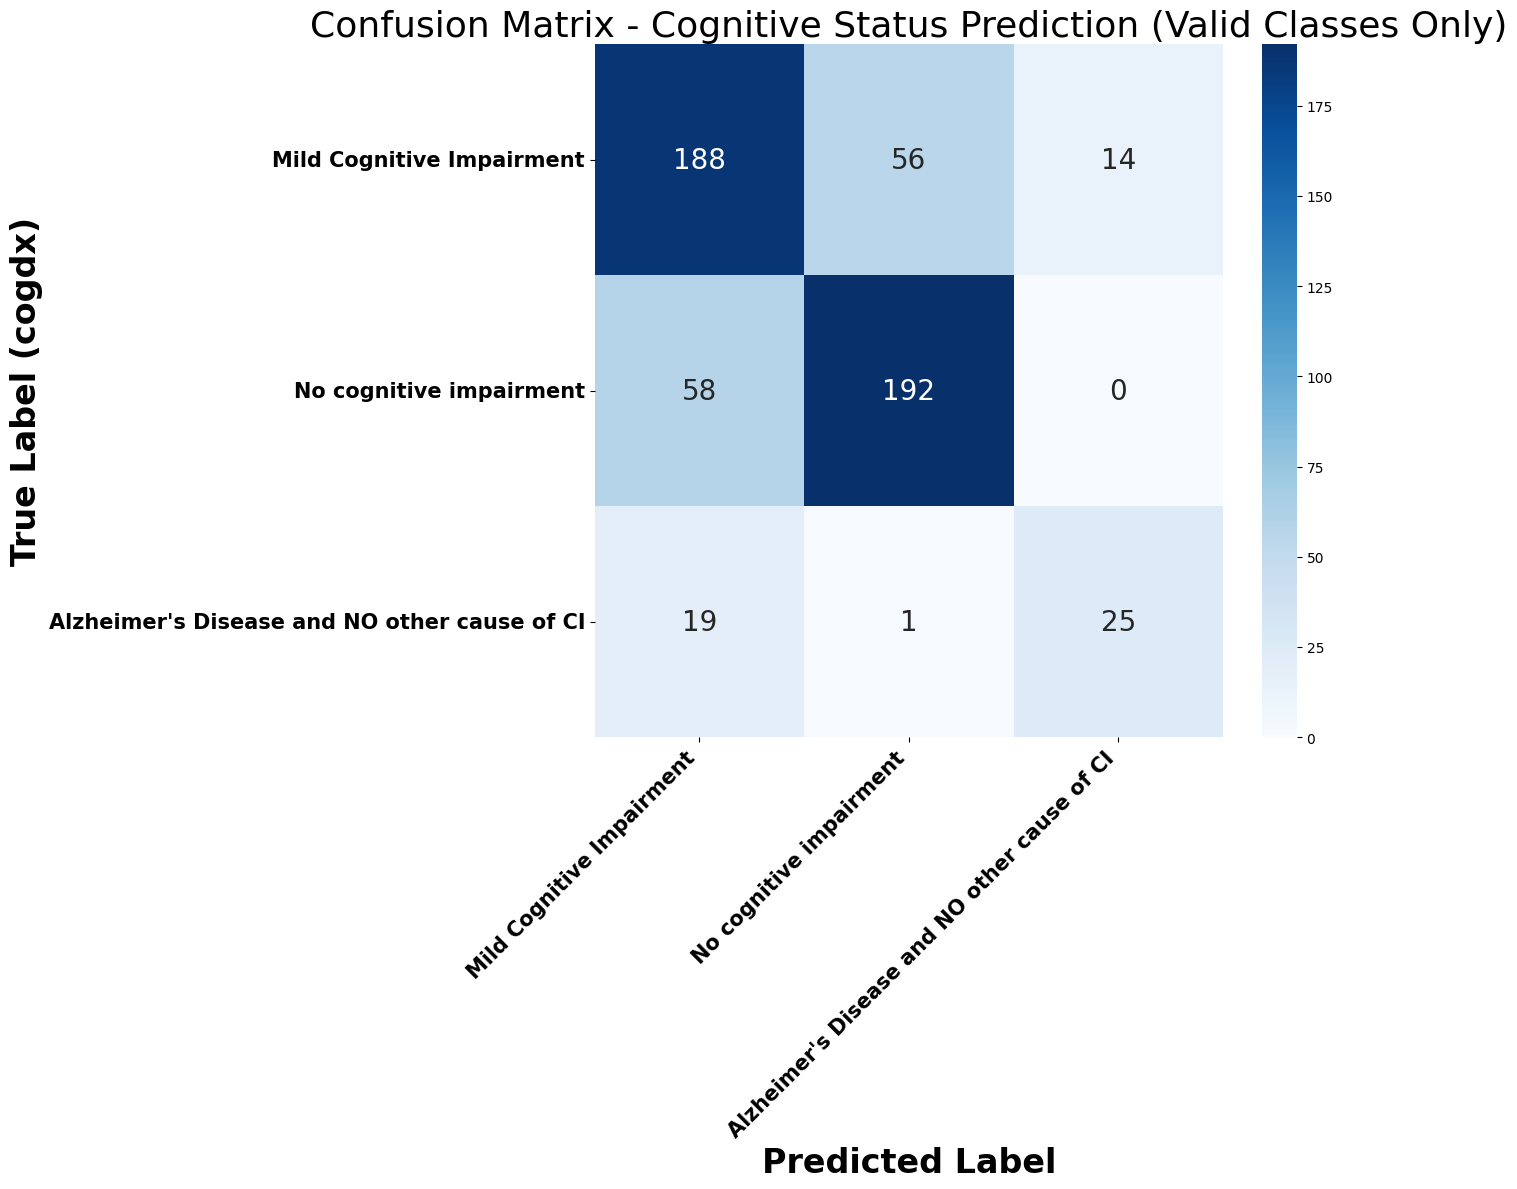


Detailed Classification Report (Valid Classes Only):
                                              precision    recall  f1-score   support

                   Mild Cognitive Impairment       0.71      0.73      0.72       258
                     No cognitive impairment       0.77      0.77      0.77       250
Alzheimer's Disease and NO other cause of CI       0.64      0.56      0.60        45

                                    accuracy                           0.73       553
                                   macro avg       0.71      0.68      0.69       553
                                weighted avg       0.73      0.73      0.73       553


Metrics DataFrame:
                                              precision    recall  f1-score  \
Mild Cognitive Impairment                      0.709434  0.728682  0.718929   
No cognitive impairment                        0.771084  0.768000  0.769539   
Alzheimer's Disease and NO other cause of CI   0.641026  0.555556  0.595238   
accur

In [3]:
##ADNI (Full Model)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

file_path = os.path.expanduser("~/Downloads/cogdx18/predictions_Full_Model_With_DERs_ADNI_othern_eval_holdout.csv")


# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx'] = df['cogdx'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 20})  # Increase annotation text size to 16
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=26)
        plt.xlabel('Predicted Label', fontsize=24, fontweight='bold')
        plt.ylabel('True Label (cogdx)', fontsize=24, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=15, fontweight='bold')
        plt.yticks(rotation=0, fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx'], f'Unknown ({row["cogdx"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")



File found at: /Users/martinnwadiugwu/Downloads/cogdx18/predictions_Full_Model_With_DERs_ROS_MAP2_eval_holdout.csv

Data Preview:
        Age    PMI.h.     KCNH8  last_MMSE_30      ST18   Braak_2  \
0  1.073573  0.219879  0.331857      2.349385  2.395115 -0.565194   
1  0.930205  0.230303  0.536784     -0.425643 -0.563334 -0.565194   
2  0.010416  0.819330  0.397417     -0.425643 -0.181491 -0.565194   
3  0.692980  0.219879  0.536784     -0.425643  0.507608 -0.565194   
4  1.407193 -0.606467  0.536784     -0.425643  0.507608 -0.565194   

   last_MMSE_26  Years_Education_20  last_MMSE_29  last_MMSE_21  ...  \
0     -0.353852           -0.351156     -0.459666     -0.166795  ...   
1     -0.353852           -0.351156     -0.459666     -0.166795  ...   
2     -0.353852           -0.351156      2.175490     -0.166795  ...   
3     -0.353852           -0.351156     -0.459666     -0.166795  ...   
4     -0.353852           -0.351156      2.175490     -0.166795  ...   

      PC_48     PC_49 

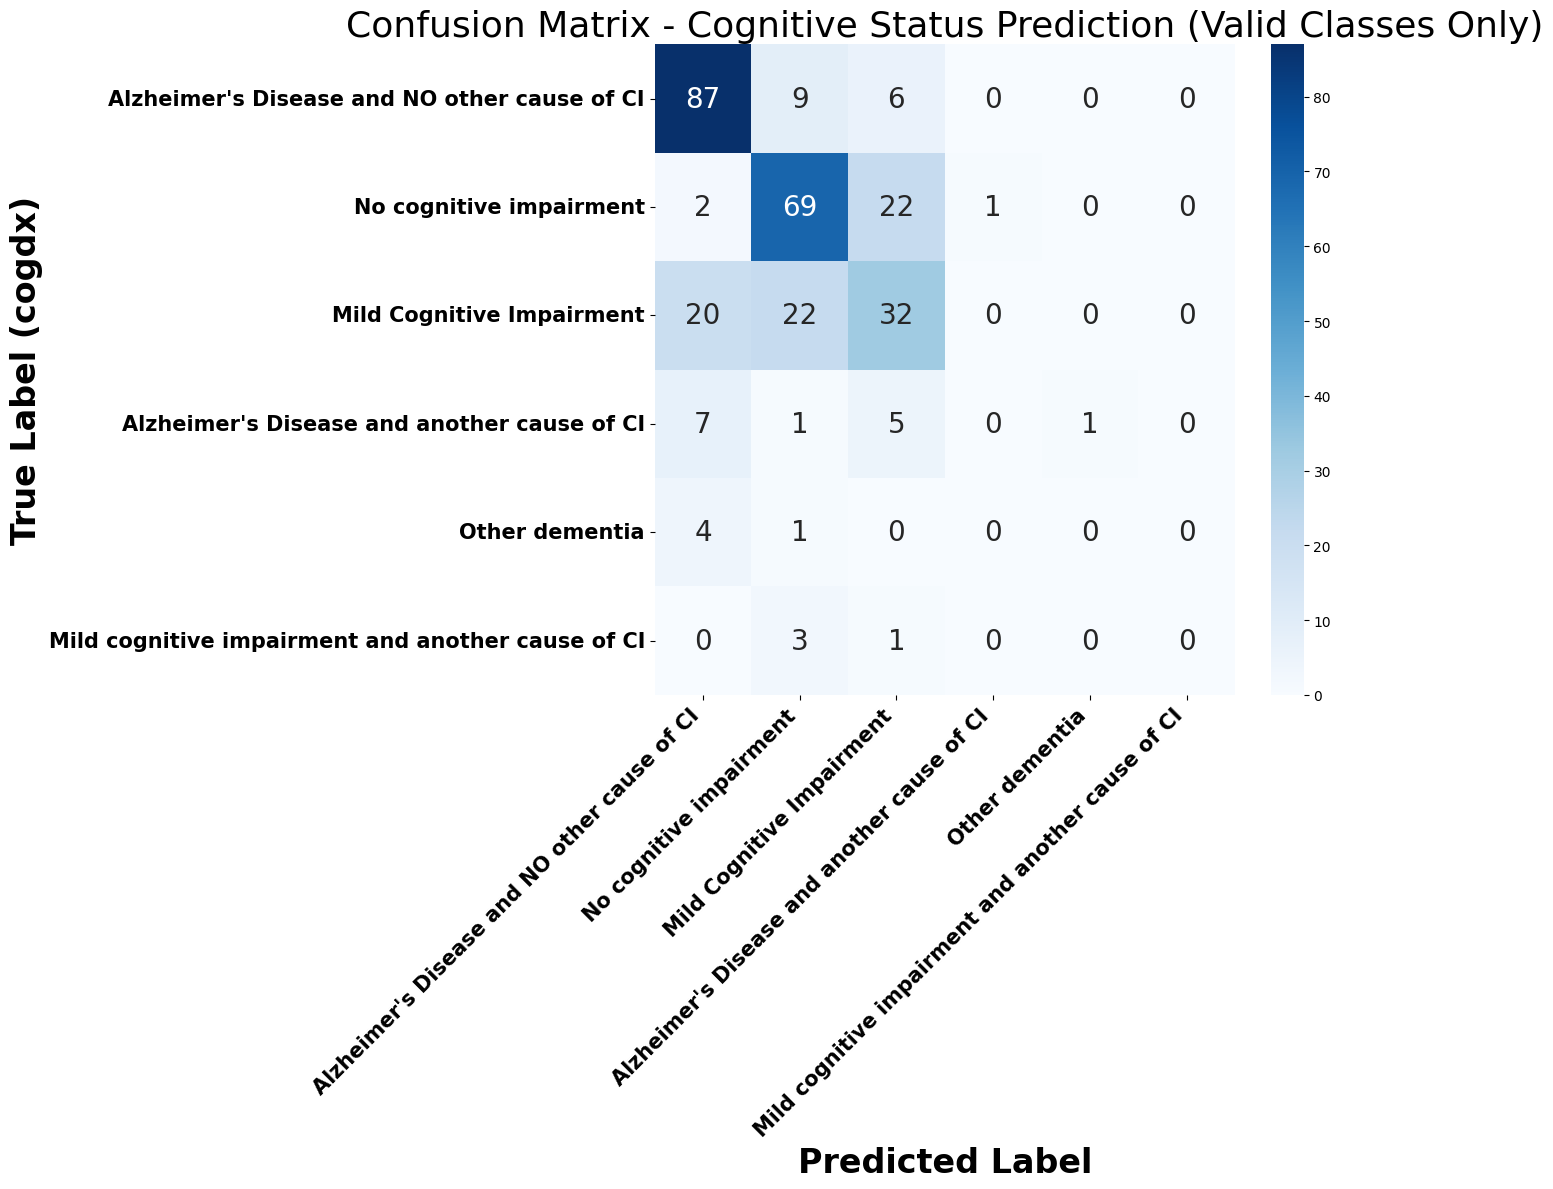


Detailed Classification Report (Valid Classes Only):
                                                   precision    recall  f1-score   support

     Alzheimer's Disease and NO other cause of CI       0.72      0.85      0.78       102
                          No cognitive impairment       0.66      0.73      0.69        94
                        Mild Cognitive Impairment       0.48      0.43      0.46        74
      Alzheimer's Disease and another cause of CI       0.00      0.00      0.00        14
                                   Other dementia       0.00      0.00      0.00         5
Mild cognitive impairment and another cause of CI       0.00      0.00      0.00         4

                                         accuracy                           0.64       293
                                        macro avg       0.31      0.34      0.32       293
                                     weighted avg       0.59      0.64      0.61       293


Metrics DataFrame:
             

In [4]:
##ROSMAP (Full Model)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

file_path = os.path.expanduser("~/Downloads/cogdx18/predictions_Full_Model_With_DERs_ROS_MAP2_eval_holdout.csv")


# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx'] = df['cogdx'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 20})  # Increase annotation text size to 16
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=26)
        plt.xlabel('Predicted Label', fontsize=24, fontweight='bold')
        plt.ylabel('True Label (cogdx)', fontsize=24, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=15, fontweight='bold')
        plt.yticks(rotation=0, fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx'], f'Unknown ({row["cogdx"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")



File found at: /Users/martinnwadiugwu/Downloads/cogdx18/predictions_Imputed_Model_MICE_DERs_ROS_MAP2_eval_holdout.csv

Data Preview:
        Age    PMI.h.  KCNH8  last_MMSE_30  ST18   Braak_2  last_MMSE_26  \
0  1.073573  0.219879    0.0      2.349385   0.0 -0.565194     -0.353852   
1  0.930205  0.230303    0.0     -0.425643   0.0 -0.565194     -0.353852   
2  0.010416  0.819330    0.0     -0.425643   0.0 -0.565194     -0.353852   
3  0.692980  0.219879    0.0     -0.425643   0.0 -0.565194     -0.353852   
4  1.407193 -0.606467    0.0     -0.425643   0.0 -0.565194     -0.353852   

   Years_Education_20  last_MMSE_29  last_MMSE_21  ...     PC_48     PC_49  \
0           -0.351156     -0.459666     -0.166795  ...  0.087066 -0.833767   
1           -0.351156     -0.459666     -0.166795  ... -0.262602  0.401109   
2           -0.351156      2.175490     -0.166795  ... -1.696845  1.055424   
3           -0.351156     -0.459666     -0.166795  ...  0.259666 -0.315473   
4           -0.35115

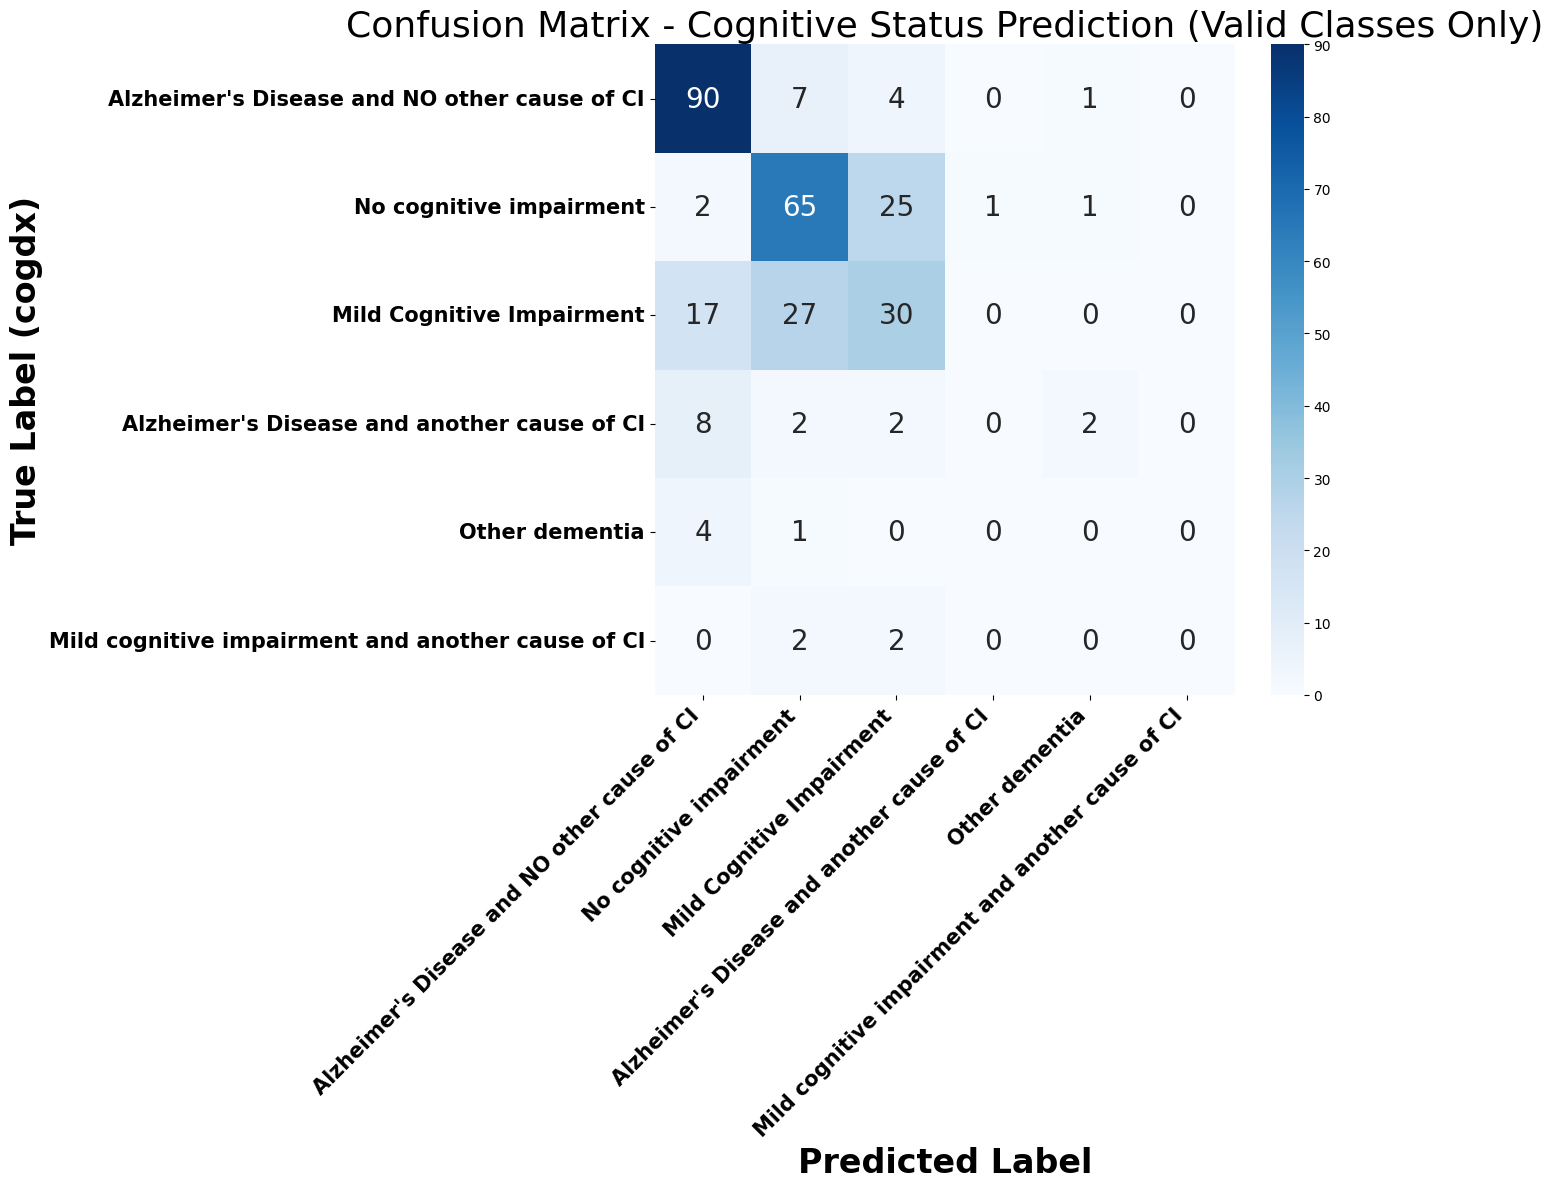


Detailed Classification Report (Valid Classes Only):
                                                   precision    recall  f1-score   support

     Alzheimer's Disease and NO other cause of CI       0.74      0.88      0.81       102
                          No cognitive impairment       0.62      0.69      0.66        94
                        Mild Cognitive Impairment       0.48      0.41      0.44        74
      Alzheimer's Disease and another cause of CI       0.00      0.00      0.00        14
                                   Other dementia       0.00      0.00      0.00         5
Mild cognitive impairment and another cause of CI       0.00      0.00      0.00         4

                                         accuracy                           0.63       293
                                        macro avg       0.31      0.33      0.32       293
                                     weighted avg       0.58      0.63      0.60       293


Metrics DataFrame:
             

In [5]:
##ROSMAP (Imputed Model)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

file_path = os.path.expanduser("~/Downloads/cogdx18/predictions_Imputed_Model_MICE_DERs_ROS_MAP2_eval_holdout.csv")


# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx'] = df['cogdx'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 20})  # Increase annotation text size to 16
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=26)
        plt.xlabel('Predicted Label', fontsize=24, fontweight='bold')
        plt.ylabel('True Label (cogdx)', fontsize=24, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=15, fontweight='bold')
        plt.yticks(rotation=0, fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx'], f'Unknown ({row["cogdx"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")


File found at: /Users/martinnwadiugwu/Downloads/cogdx18/predictions_Imputed_Model_MICE_DERs_ADNI_othern_eval_holdout.csv

Data Preview:
        Age    PMI.h.  KCNH8  last_MMSE_30  ST18   Braak_2  last_MMSE_26  \
0 -0.572546  0.936328    0.0     -0.425643   0.0  1.769303     -0.353852   
1 -0.032851  1.560639    0.0      2.349385   0.0  1.769303     -0.353852   
2 -0.613648  0.433936    0.0      2.349385   0.0 -0.565194     -0.353852   
3 -2.482156  1.245560    0.0      2.349385   0.0 -0.565194     -0.353852   
4 -0.483698  0.716888    0.0     -0.425643   0.0  1.769303     -0.353852   

   Years_Education_20  last_MMSE_29  last_MMSE_21  ...     PC_48     PC_49  \
0           -0.351156      2.175490     -0.166795  ... -0.232580 -1.033173   
1           -0.351156     -0.459666     -0.166795  ... -2.011403  1.522493   
2           -0.351156     -0.459666     -0.166795  ...  0.295458 -0.054022   
3           -0.351156     -0.459666     -0.166795  ... -0.047346  0.063425   
4           -0.35

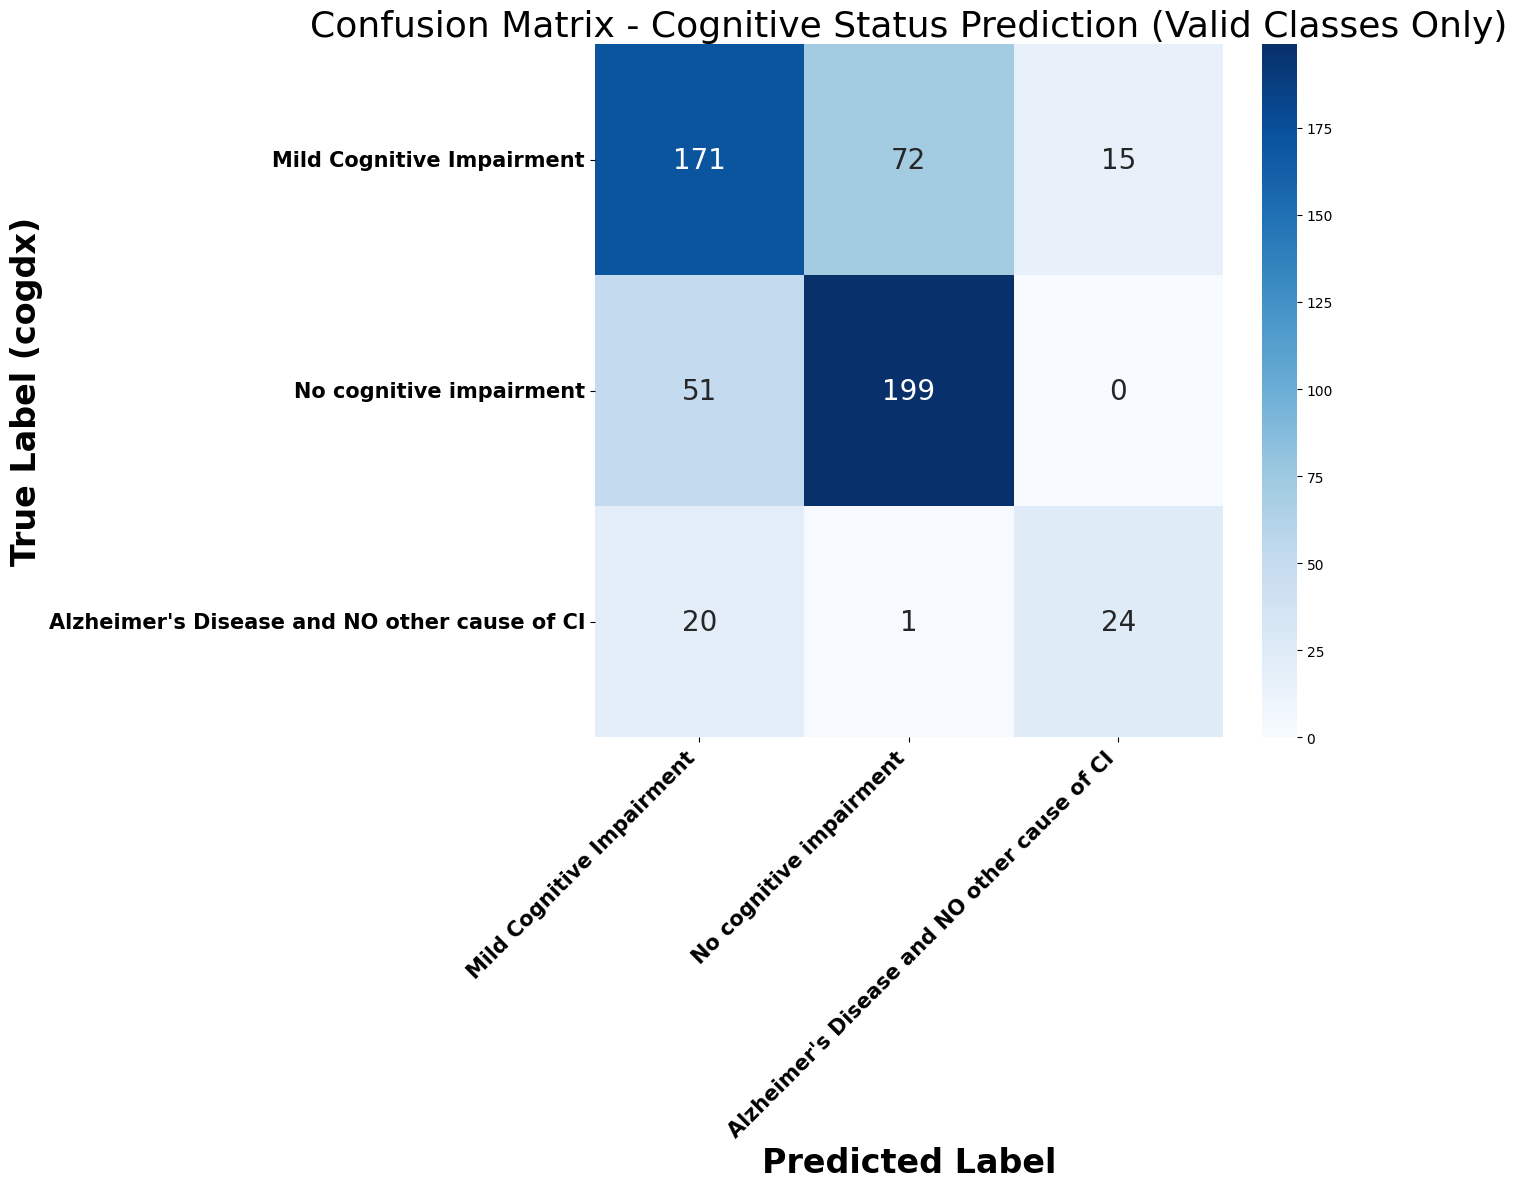


Detailed Classification Report (Valid Classes Only):
                                              precision    recall  f1-score   support

                   Mild Cognitive Impairment       0.71      0.66      0.68       258
                     No cognitive impairment       0.73      0.80      0.76       250
Alzheimer's Disease and NO other cause of CI       0.62      0.53      0.57        45

                                    accuracy                           0.71       553
                                   macro avg       0.68      0.66      0.67       553
                                weighted avg       0.71      0.71      0.71       553


Metrics DataFrame:
                                              precision    recall  f1-score  \
Mild Cognitive Impairment                      0.706612  0.662791  0.684000   
No cognitive impairment                        0.731618  0.796000  0.762452   
Alzheimer's Disease and NO other cause of CI   0.615385  0.533333  0.571429   
accur

In [9]:
##ADNI (Imputed Model)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

file_path = os.path.expanduser("~/Downloads/cogdx18/predictions_Imputed_Model_MICE_DERs_ADNI_othern_eval_holdout.csv")

# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx'] = df['cogdx'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 20})  # Increase annotation text size to 16
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=26)
        plt.xlabel('Predicted Label', fontsize=24, fontweight='bold')
        plt.ylabel('True Label (cogdx)', fontsize=24, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=15, fontweight='bold')
        plt.yticks(rotation=0, fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx'], f'Unknown ({row["cogdx"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")


File found at: /Users/martinnwadiugwu/Downloads/cogdx18/predictions_Reduced_Model_No_DERs_ADNI_othern_eval_holdout.csv

Data Preview:
        Age    PMI.h.  last_MMSE_29  last_MMSE_26  last_MMSE_21  \
0 -0.572546  0.936328      2.175490     -0.353852     -0.166795   
1 -0.032851  1.560639     -0.459666     -0.353852     -0.166795   
2 -0.613648  0.433936     -0.459666     -0.353852     -0.166795   
3 -2.482156  1.245560     -0.459666     -0.353852     -0.166795   
4 -0.483698  0.716888     -0.459666     -0.353852     -0.166795   

   Gender_female  Highest_Education_Level_Professional  race_Asian  \
0       1.130220                             -0.334724    -0.11713   
1       1.130220                             -0.334724    -0.11713   
2      -0.884783                             -0.334724    -0.11713   
3       1.130220                             -0.334724    -0.11713   
4       1.130220                             -0.334724    -0.11713   

   last_MMSE_30  last_MMSE_2  ...     PC_4

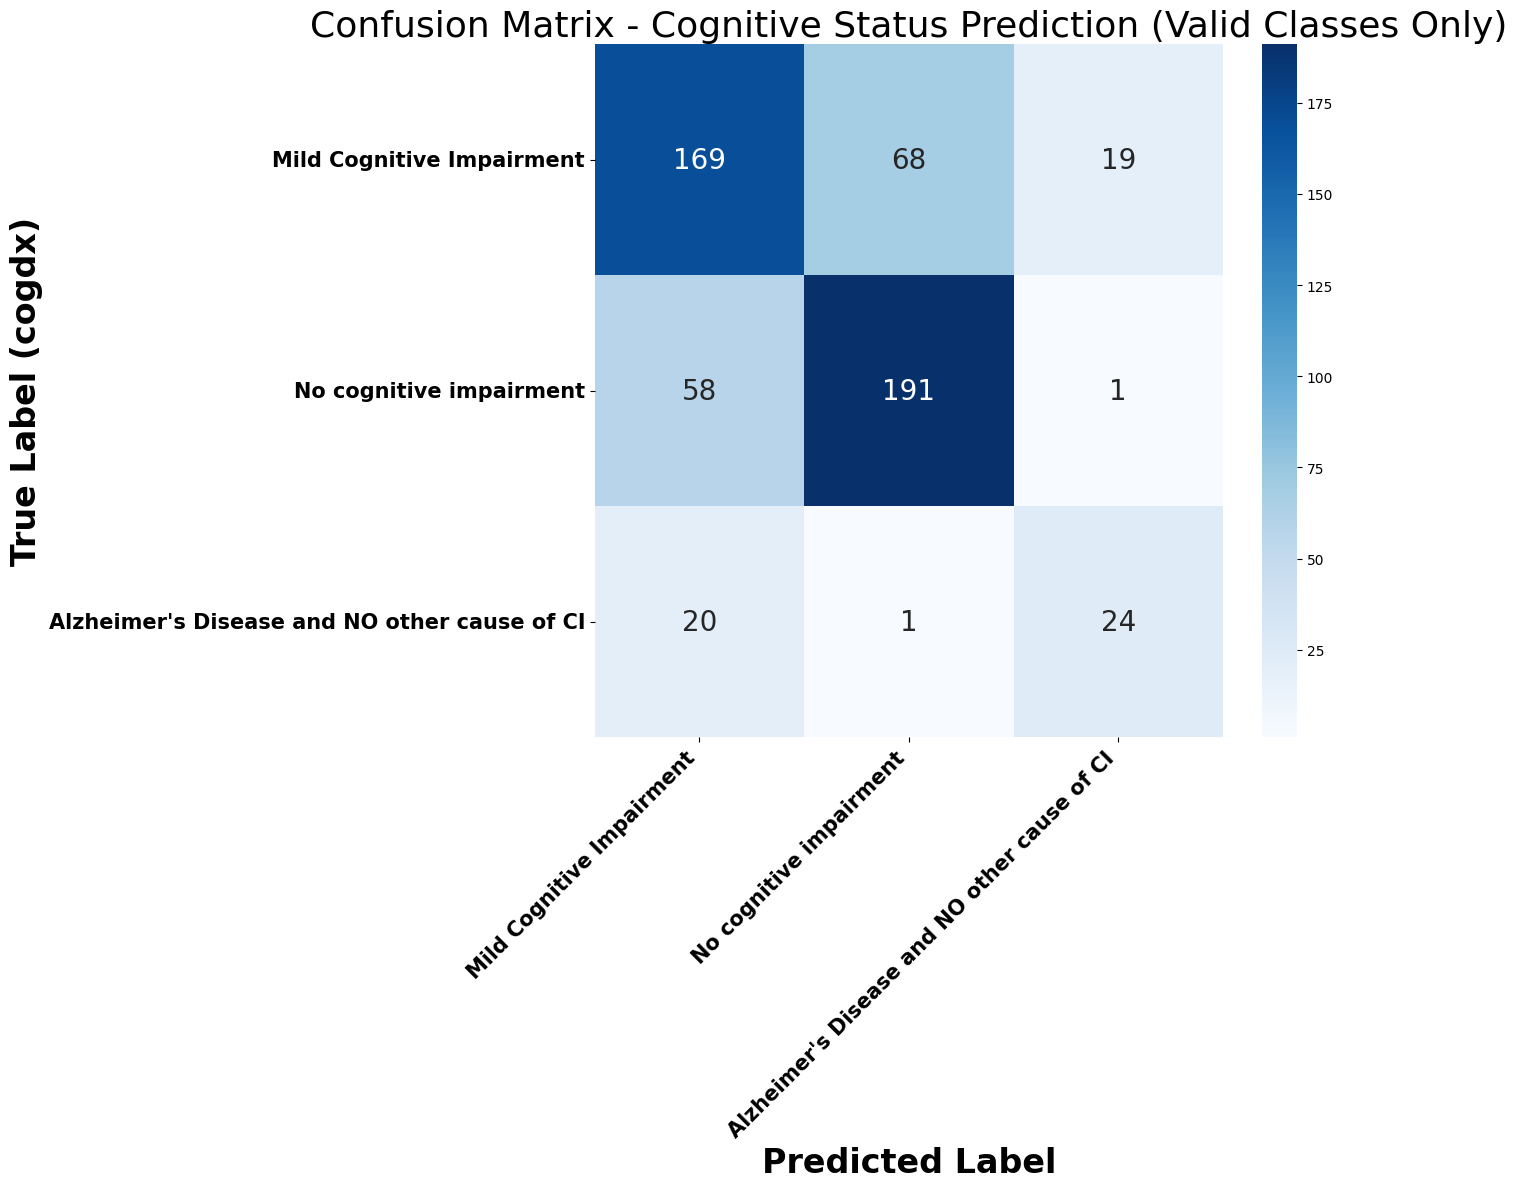


Detailed Classification Report (Valid Classes Only):
                                              precision    recall  f1-score   support

                   Mild Cognitive Impairment       0.68      0.66      0.67       258
                     No cognitive impairment       0.73      0.76      0.75       250
Alzheimer's Disease and NO other cause of CI       0.55      0.53      0.54        45

                                   micro avg       0.70      0.69      0.70       553
                                   macro avg       0.65      0.65      0.65       553
                                weighted avg       0.70      0.69      0.69       553


Metrics DataFrame:
                                              precision    recall  f1-score  \
Mild Cognitive Impairment                      0.684211  0.655039  0.669307   
No cognitive impairment                        0.734615  0.764000  0.749020   
Alzheimer's Disease and NO other cause of CI   0.545455  0.533333  0.539326   
micro

In [10]:
##ADNI (Reduced Model)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

file_path = os.path.expanduser("~/Downloads/cogdx18/predictions_Reduced_Model_No_DERs_ADNI_othern_eval_holdout.csv")

# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx'] = df['cogdx'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 20})  # Increase annotation text size to 16
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=26)
        plt.xlabel('Predicted Label', fontsize=24, fontweight='bold')
        plt.ylabel('True Label (cogdx)', fontsize=24, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=15, fontweight='bold')
        plt.yticks(rotation=0, fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx'], f'Unknown ({row["cogdx"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")


File found at: /Users/martinnwadiugwu/Downloads/cogdx18/predictions_Reduced_Model_No_DERs_ROS_MAP2_eval_holdout.csv

Data Preview:
        Age    PMI.h.  last_MMSE_29  last_MMSE_26  last_MMSE_21  \
0  1.073573  0.219879     -0.459666     -0.353852     -0.166795   
1  0.930205  0.230303     -0.459666     -0.353852     -0.166795   
2  0.010416  0.819330      2.175490     -0.353852     -0.166795   
3  0.692980  0.219879     -0.459666     -0.353852     -0.166795   
4  1.407193 -0.606467      2.175490     -0.353852     -0.166795   

   Gender_female  Highest_Education_Level_Professional  race_Asian  \
0       1.130220                             -0.334724    -0.11713   
1      -0.884783                             -0.334724    -0.11713   
2      -0.884783                             -0.334724    -0.11713   
3      -0.884783                             -0.334724    -0.11713   
4       1.130220                             -0.334724    -0.11713   

   last_MMSE_30  last_MMSE_2  ...     PC_48  

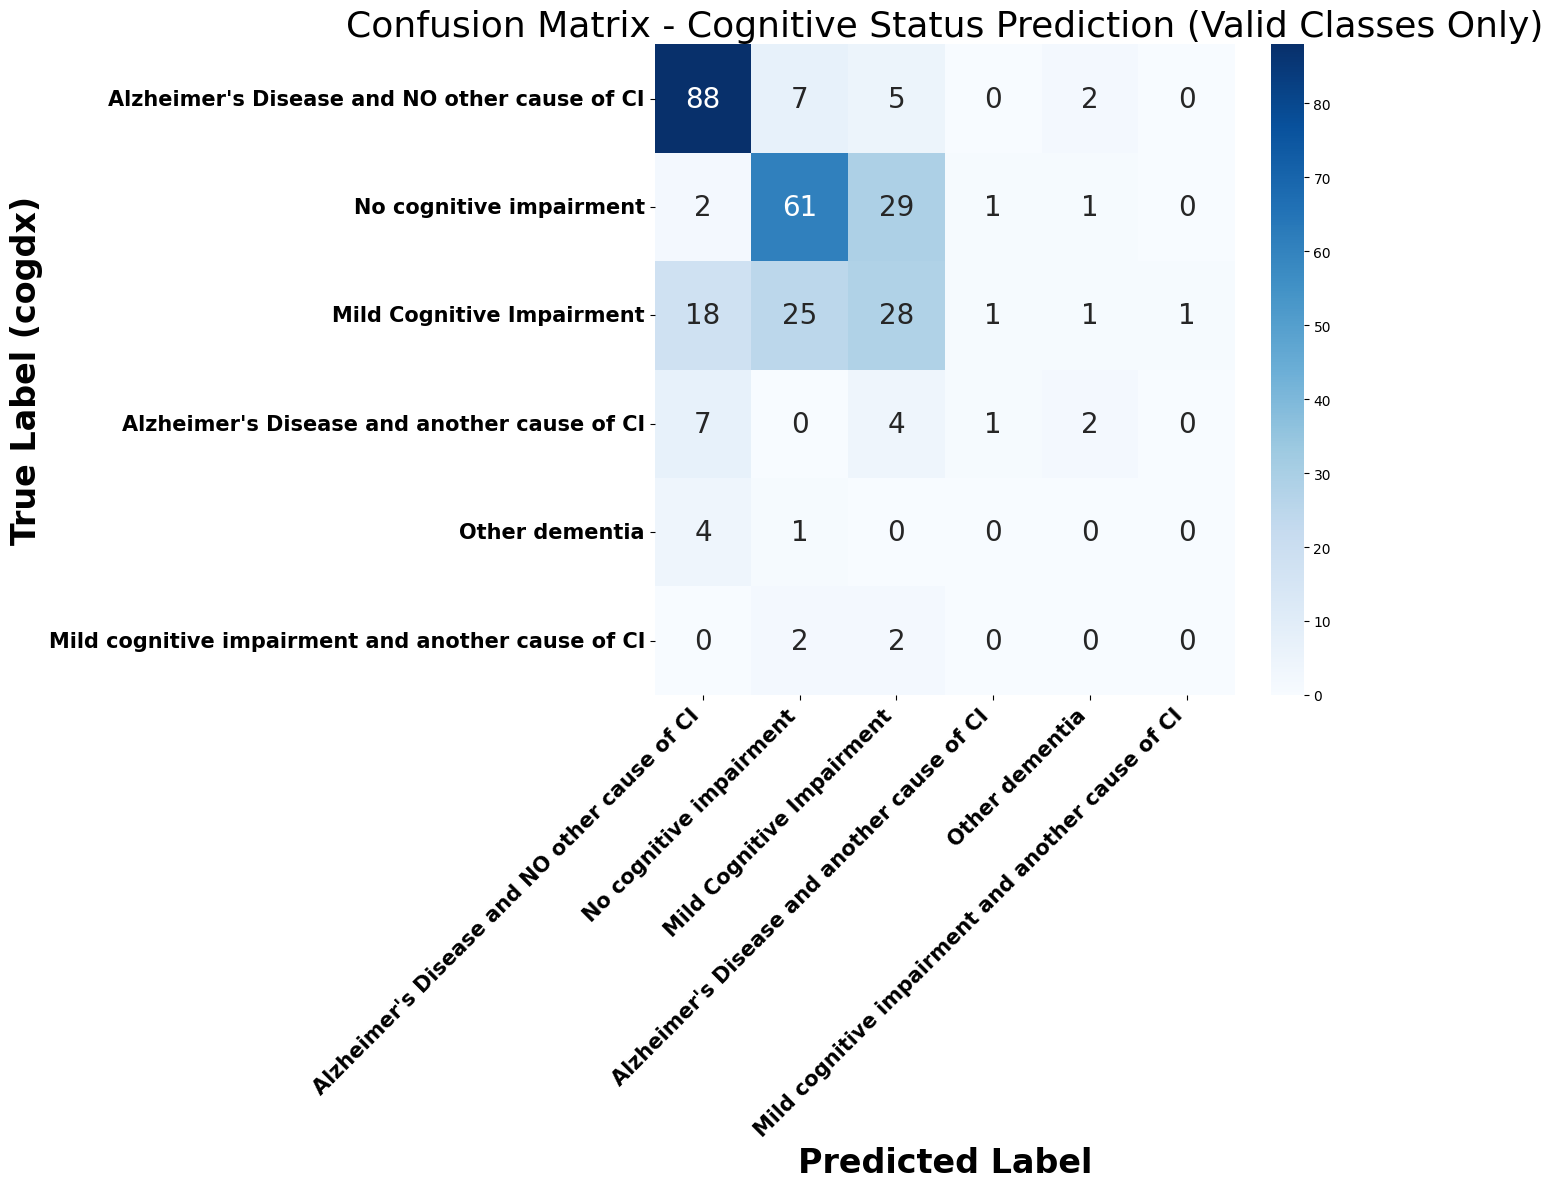


Detailed Classification Report (Valid Classes Only):
                                                   precision    recall  f1-score   support

     Alzheimer's Disease and NO other cause of CI       0.74      0.86      0.80       102
                          No cognitive impairment       0.64      0.65      0.64        94
                        Mild Cognitive Impairment       0.41      0.38      0.39        74
      Alzheimer's Disease and another cause of CI       0.33      0.07      0.12        14
                                   Other dementia       0.00      0.00      0.00         5
Mild cognitive impairment and another cause of CI       0.00      0.00      0.00         4

                                         accuracy                           0.61       293
                                        macro avg       0.35      0.33      0.33       293
                                     weighted avg       0.58      0.61      0.59       293


Metrics DataFrame:
             

In [11]:
##ROS_MAP2 (Reduced Model)


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

# Define the status mapping
STATUS_MAP = {
    1: "No cognitive impairment",
    2: "Mild Cognitive Impairment",
    3: "Mild cognitive impairment and another cause of CI",
    4: "Alzheimer's Disease and NO other cause of CI",
    5: "Alzheimer's Disease and another cause of CI",
    6: "Other dementia"
}

file_path = os.path.expanduser("~/Downloads/cogdx18/predictions_Reduced_Model_No_DERs_ROS_MAP2_eval_holdout.csv")

# Verify file exists
if not os.path.exists(file_path):
    print(f"ERROR: File not found at {file_path}")
    print("Please verify the file exists at this location.")
else:
    print(f"File found at: {file_path}")
    
    # Load the CSV file
    df = pd.read_csv(file_path)
    
    # Display first few rows
    print("\nData Preview:")
    print(df.head())
    
    # Check for required columns
    required_columns = ['predicted_cogdx', 'cogdx']
    missing_cols = [col for col in required_columns if col not in df.columns]

    if missing_cols:
        print(f"\nERROR: Missing columns: {', '.join(missing_cols)}")
        print("Available columns:", df.columns.tolist())
    else:
        # Check for missing values
        print("\nMissing Values Check:")
        print(df[required_columns].isnull().sum())
    
        # Convert to integers
        df['cogdx'] = df['cogdx'].astype(int)
        df['predicted_cogdx'] = df['predicted_cogdx'].astype(int)
        
        # Identify classes with actual support
        class_counts = df['cogdx'].value_counts()
        valid_classes = class_counts[class_counts > 0].index.tolist()
        
        # Filter both true and predicted labels to only include valid classes
        df_filtered = df[df['cogdx'].isin(valid_classes)].copy()
        
        # Also remove predictions for invalid classes (treat them as misclassifications)
        # This is important because if the model predicts a class that doesn't exist in the test set,
        # we should count it as an error
        invalid_predictions = ~df_filtered['predicted_cogdx'].isin(valid_classes)
        if invalid_predictions.sum() > 0:
            print(f"\nFound {invalid_predictions.sum()} predictions for invalid classes. These will be treated as errors.")
            # You could choose to mark these as a specific error code or just leave them as is
            # For now, we'll just note them but not change the values
        
        print(f"\nFiltered dataset size: {len(df_filtered)}")
        print("Class distribution after filtering:")
        print(df_filtered['cogdx'].value_counts())
    
        # Calculate accuracy
        correct_predictions = (df_filtered['predicted_cogdx'] == df_filtered['cogdx']).sum()
        total_samples = len(df_filtered)
        accuracy = correct_predictions / total_samples

        print(f"\nAccuracy Ratio: {correct_predictions}/{total_samples} = {accuracy:.4f} ({accuracy*100:.2f}%)")
    
        # Generate confusion matrix - only include valid classes
        cm = confusion_matrix(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes
        )
        
        # Create labels for matrix using STATUS_MAP
        labels = [STATUS_MAP.get(label, f'Unknown ({label})') for label in valid_classes]
        
        # Plot confusion matrix
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 20})  # Increase annotation text size to 16
        plt.title('Confusion Matrix - Cognitive Status Prediction (Valid Classes Only)', fontsize=26)
        plt.xlabel('Predicted Label', fontsize=24, fontweight='bold')
        plt.ylabel('True Label (cogdx)', fontsize=24, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=15, fontweight='bold')
        plt.yticks(rotation=0, fontsize=15, fontweight='bold')
        plt.tight_layout()
        plt.show()

        
        # Classification report - only include valid classes
        print("\nDetailed Classification Report (Valid Classes Only):")
        report = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            zero_division=0
        )
        print(report)
        
        # Convert classification report to DataFrame for better visualization
        report_dict = classification_report(
            df_filtered['cogdx'], 
            df_filtered['predicted_cogdx'],
            labels=valid_classes,
            target_names=[STATUS_MAP.get(i, f'Unknown ({i})') for i in valid_classes],
            output_dict=True,
            zero_division=0
        )
        metrics_df = pd.DataFrame(report_dict).transpose()
        print("\nMetrics DataFrame:")
        print(metrics_df)
        
        # Additional analysis: Class-wise performance
        print("\nAdditional Analysis:")
        print("=" * 50)
        
        # Calculate class-wise accuracy
        for class_label in valid_classes:
            class_data = df_filtered[df_filtered['cogdx'] == class_label]
            class_accuracy = (class_data['predicted_cogdx'] == class_data['cogdx']).mean()
            print(f"{STATUS_MAP.get(class_label, f'Unknown ({class_label})')}: {class_accuracy:.2%} accuracy")
        
        # Most common misclassifications
        misclassifications = df_filtered[df_filtered['predicted_cogdx'] != df_filtered['cogdx']]
        if len(misclassifications) > 0:
            print(f"\nMost common misclassifications:")
            misclass_counts = misclassifications.groupby(['cogdx', 'predicted_cogdx']).size().reset_index(name='count')
            misclass_counts = misclass_counts.sort_values('count', ascending=False)
            
            for _, row in misclass_counts.head().iterrows():
                true_label = STATUS_MAP.get(row['cogdx'], f'Unknown ({row["cogdx"]})')
                pred_label = STATUS_MAP.get(row['predicted_cogdx'], f'Unknown ({row["predicted_cogdx"]})')
                print(f"  {true_label} → {pred_label}: {row['count']} cases")
        
        # Check for predictions of invalid classes
        invalid_preds = df_filtered[~df_filtered['predicted_cogdx'].isin(valid_classes)]
        if len(invalid_preds) > 0:
            print(f"\nWARNING: {len(invalid_preds)} predictions are for classes not present in the test set:")
            for class_label in invalid_preds['predicted_cogdx'].unique():
                count = (invalid_preds['predicted_cogdx'] == class_label).sum()
                print(f"  Class {class_label} ({STATUS_MAP.get(class_label, 'Unknown')}): {count} predictions")


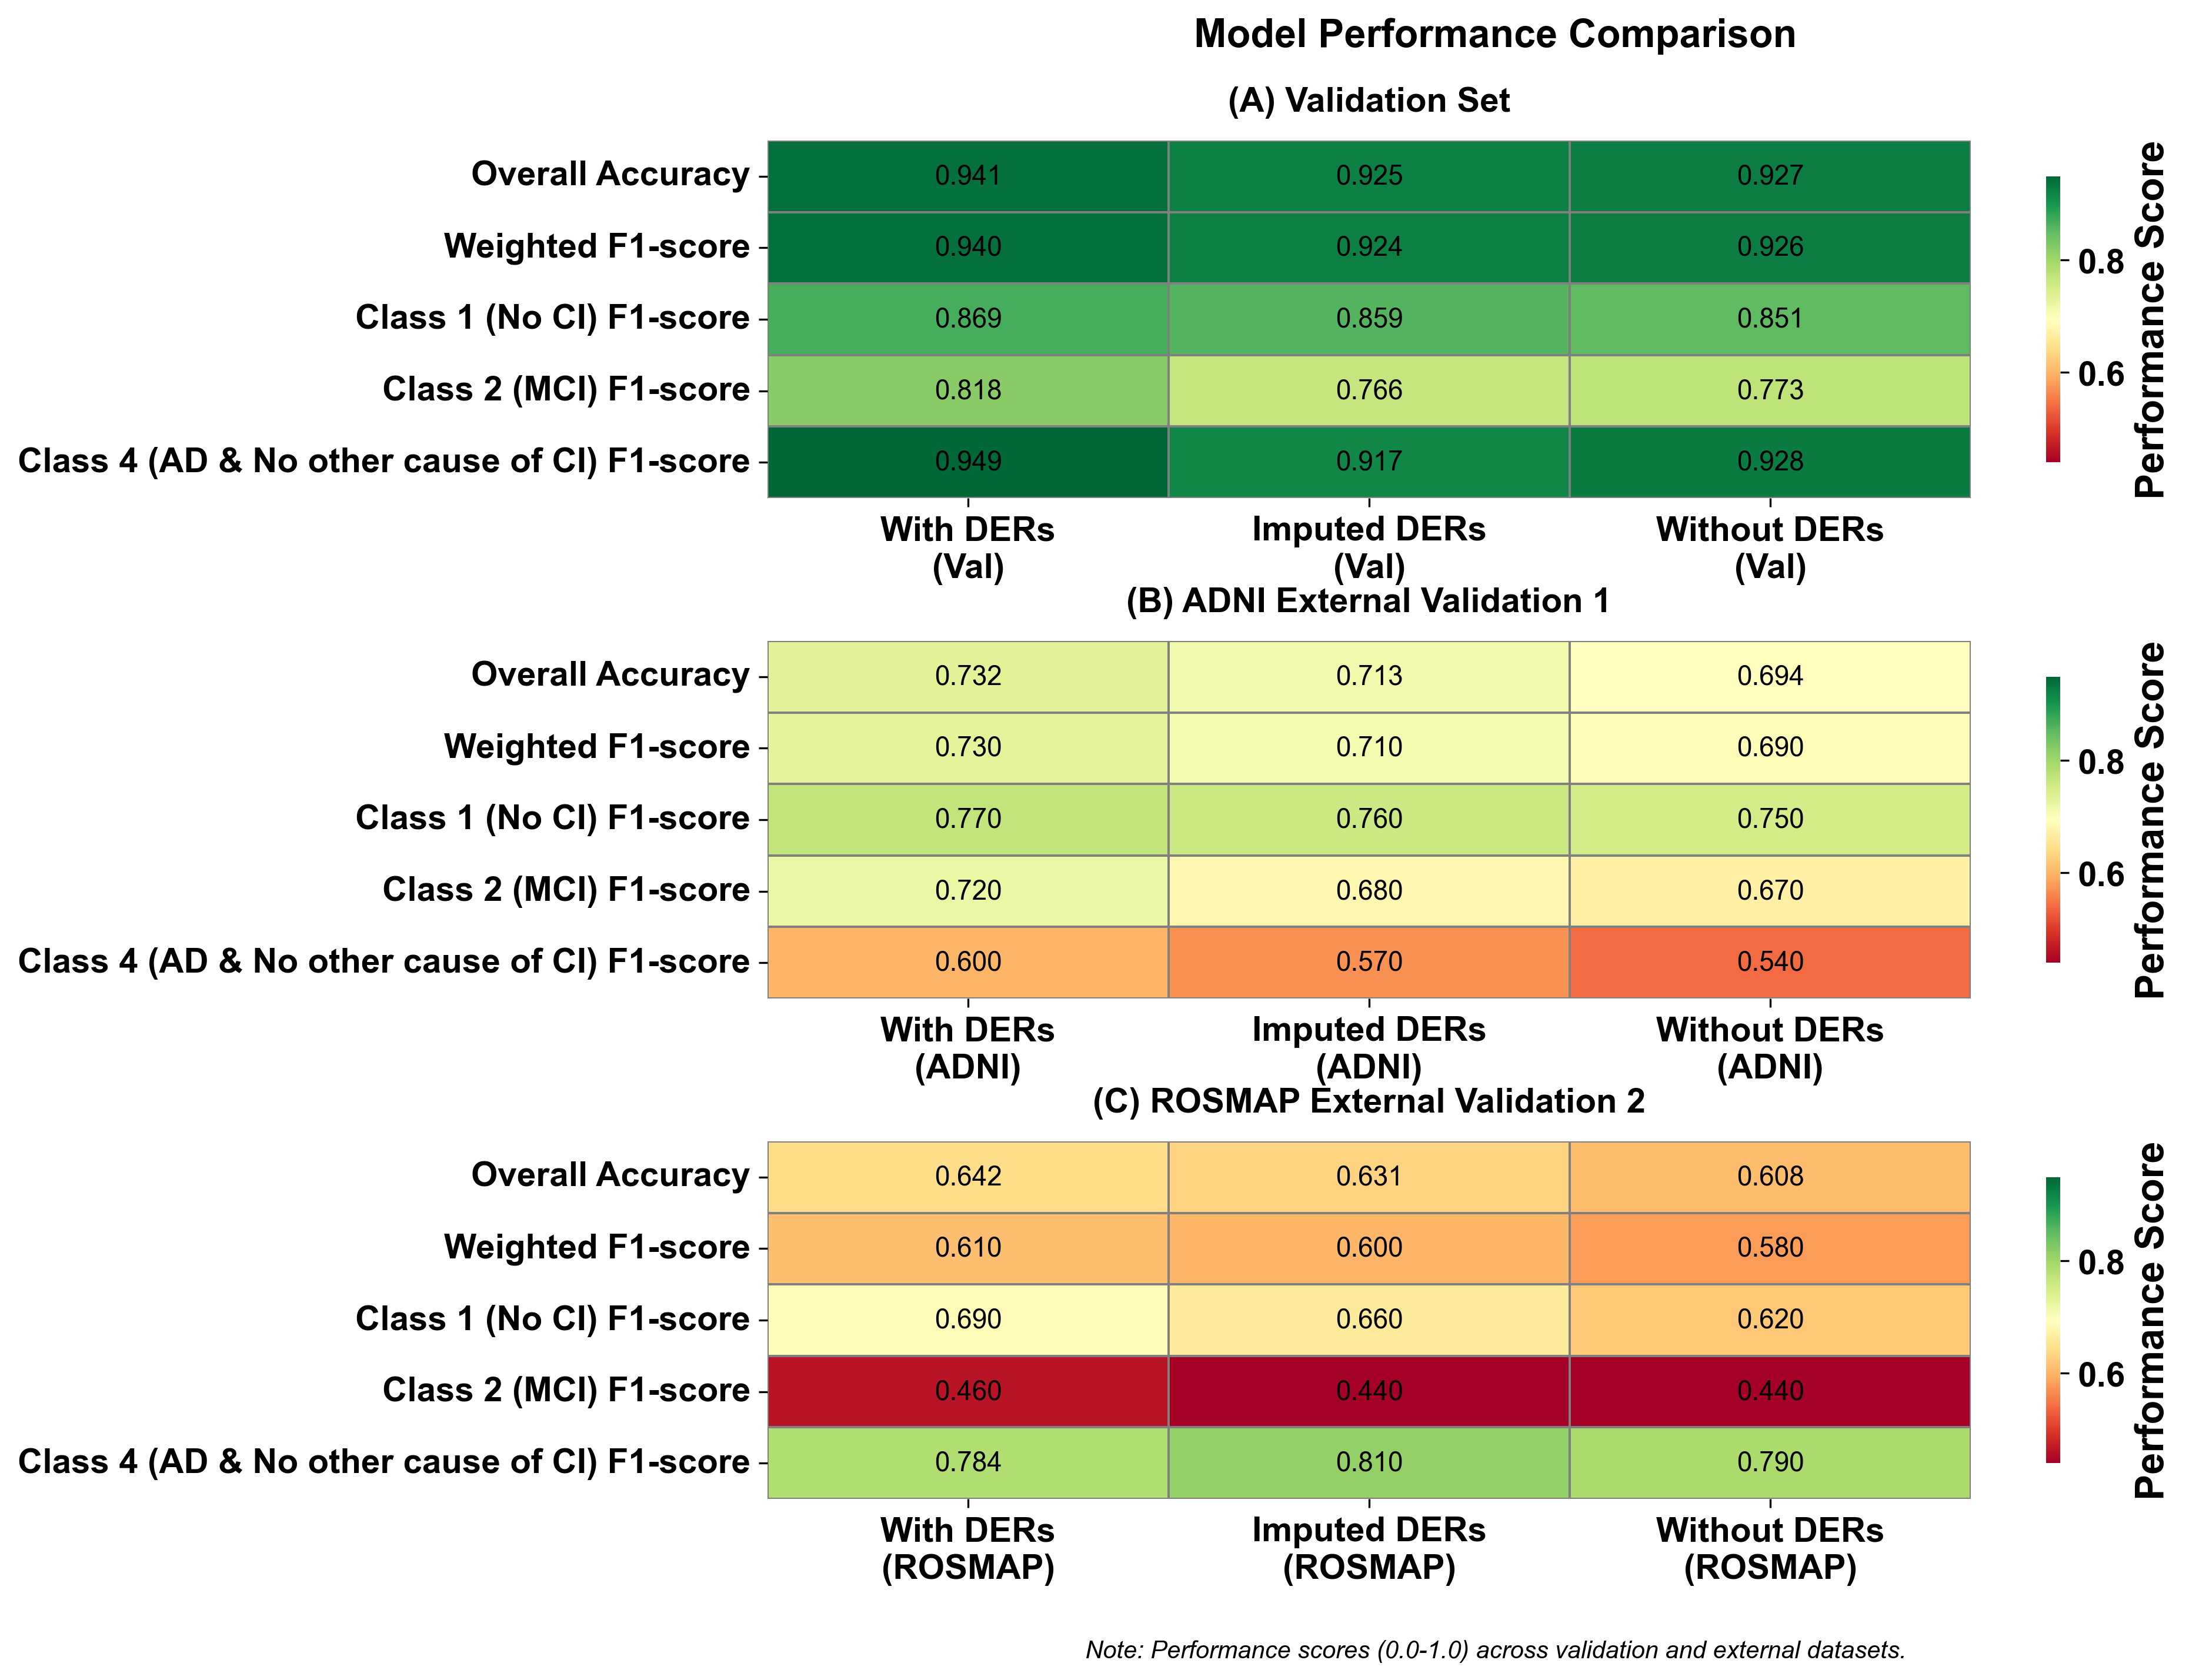

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize

# =======================================================
# GLOBAL CLEAN FONT + EXPORT SETTINGS - INCREASED & BOLD
# =======================================================
plt.style.use("default")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'font.weight': 'bold',
})

# =======================================================
# DATA – UPDATED FROM TABLE 2 (all values as decimals)
# =======================================================
metrics = [
    'Validation Balanced Accuracy',
    'Overall Accuracy',
    'Weighted F1-score',
    'Weighted Average',
    'Class 1 (No CI) F1-score',
    'Class 2 (MCI) F1-score',
    'Class 3 (MCI & another cause of CI) F1-score',
    'Class 4 (AD & No other cause of CI) F1-score',
    'Class 5 (AD & another cause of CI) F1-score',
    'Class 6 (Other dementia) F1-score'
]

data = {
    # --- Validation Set ---
    'With DERs (Val)': [
        0.9404, 0.9407, 0.9396, 0.9393, 0.869, 0.818, 1.000, 0.949, 1.000, 1.000
    ],
    'Imputed DERs (Val)': [
        0.9247, 0.9250, 0.9237, 0.9234, 0.859, 0.766, 1.000, 0.917, 1.000, 1.000
    ],
    'Without DERs (Val)': [
        0.9264, 0.9267, 0.9256, 0.9253, 0.851, 0.773, 1.000, 0.928, 1.000, 1.000
    ],

    # --- ADNI External Validation 1 ---
    'With DERs (ADNI)': [
        0.6841, 0.7324, 0.730, 0.690, 0.770, 0.720, 0.000, 0.600, 0.000, 0.000
    ],
    'Imputed DERs (ADNI)': [
        0.6640, 0.7125, 0.710, 0.670, 0.760, 0.680, 0.000, 0.570, 0.000, 0.000
    ],
    'Without DERs (ADNI)': [
        0.6508, 0.6944, 0.690, 0.650, 0.750, 0.670, 0.000, 0.540, 0.000, 0.000
    ],

    # --- ROSMAP External Validation 2 ---
    'With DERs (ROSMAP)': [
        0.3366, 0.6416, 0.610, 0.320, 0.690, 0.460, 0.000, 0.784, 0.000, 0.000
    ],
    'Imputed DERs (ROSMAP)': [
        0.3299, 0.6314, 0.600, 0.320, 0.660, 0.440, 0.000, 0.810, 0.000, 0.000
    ],
    'Without DERs (ROSMAP)': [
        0.3193, 0.6075, 0.580, 0.310, 0.620, 0.440, 0.000, 0.790, 0.000, 0.000
    ]
}

df = pd.DataFrame(data, index=metrics)

# =======================================================
# HEATMAPS – SHOW SELECTED METRICS (same as before)
# =======================================================
groups = {
    'Validation Set': ['With DERs (Val)', 'Imputed DERs (Val)', 'Without DERs (Val)'],
    'ADNI External Validation 1': ['With DERs (ADNI)', 'Imputed DERs (ADNI)', 'Without DERs (ADNI)'],
    'ROSMAP External Validation 2': ['With DERs (ROSMAP)', 'Imputed DERs (ROSMAP)', 'Without DERs (ROSMAP)']
}

# Keep the same five key metrics as in the original code,
# but note that "Overall Accuracy" and "Macro F1-score" are now correct.
metrics_to_plot = [
    'Overall Accuracy',
    'Weighted F1-score',
    'Class 1 (No CI) F1-score',
    'Class 2 (MCI) F1-score',
    'Class 4 (AD & No other cause of CI) F1-score'
]

df_plot = df.loc[metrics_to_plot]

fig, axs = plt.subplots(3, 1, figsize=(11, 10), gridspec_kw={'hspace': 0.4})

norm = Normalize(vmin=df_plot.values.min(), vmax=df_plot.values.max())
cmap = plt.cm.RdYlGn

for i, (group_name, cols) in enumerate(groups.items()):
    ax = axs[i]
    df_group = df_plot[cols]
    
    sns.heatmap(
        df_group,
        ax=ax,
        cmap=cmap,
        norm=norm,
        annot=True,
        fmt=".3f",
        annot_kws={'fontsize': 11, 'fontweight': 'normal', 'color': 'black'},
        linewidths=0.5,
        linecolor='gray',
        cbar_kws={'label': 'Performance Score', 'shrink': 0.8}
    )
    
    ax.set_title(f"({chr(65 + i)}) {group_name}", fontsize=14, fontweight="bold", pad=12)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')
    ax.set_xticklabels([x.replace(" (", "\n(") for x in cols], rotation=0, ha='center')

fig.suptitle("Model Performance Comparison", 
             fontsize=16, y=0.95, fontweight="bold")
fig.text(0.5, 0.02, "Note: Performance scores (0.0-1.0) across validation and external datasets.", 
         ha="center", fontsize=10, fontweight="normal", style="italic")

# Save the figure
plt.savefig("/Users/martinnwadiugwu/Downloads/performance_heatmap_imputed22.pdf", 
            dpi=300, bbox_inches="tight", facecolor='white', edgecolor='none')
plt.show()

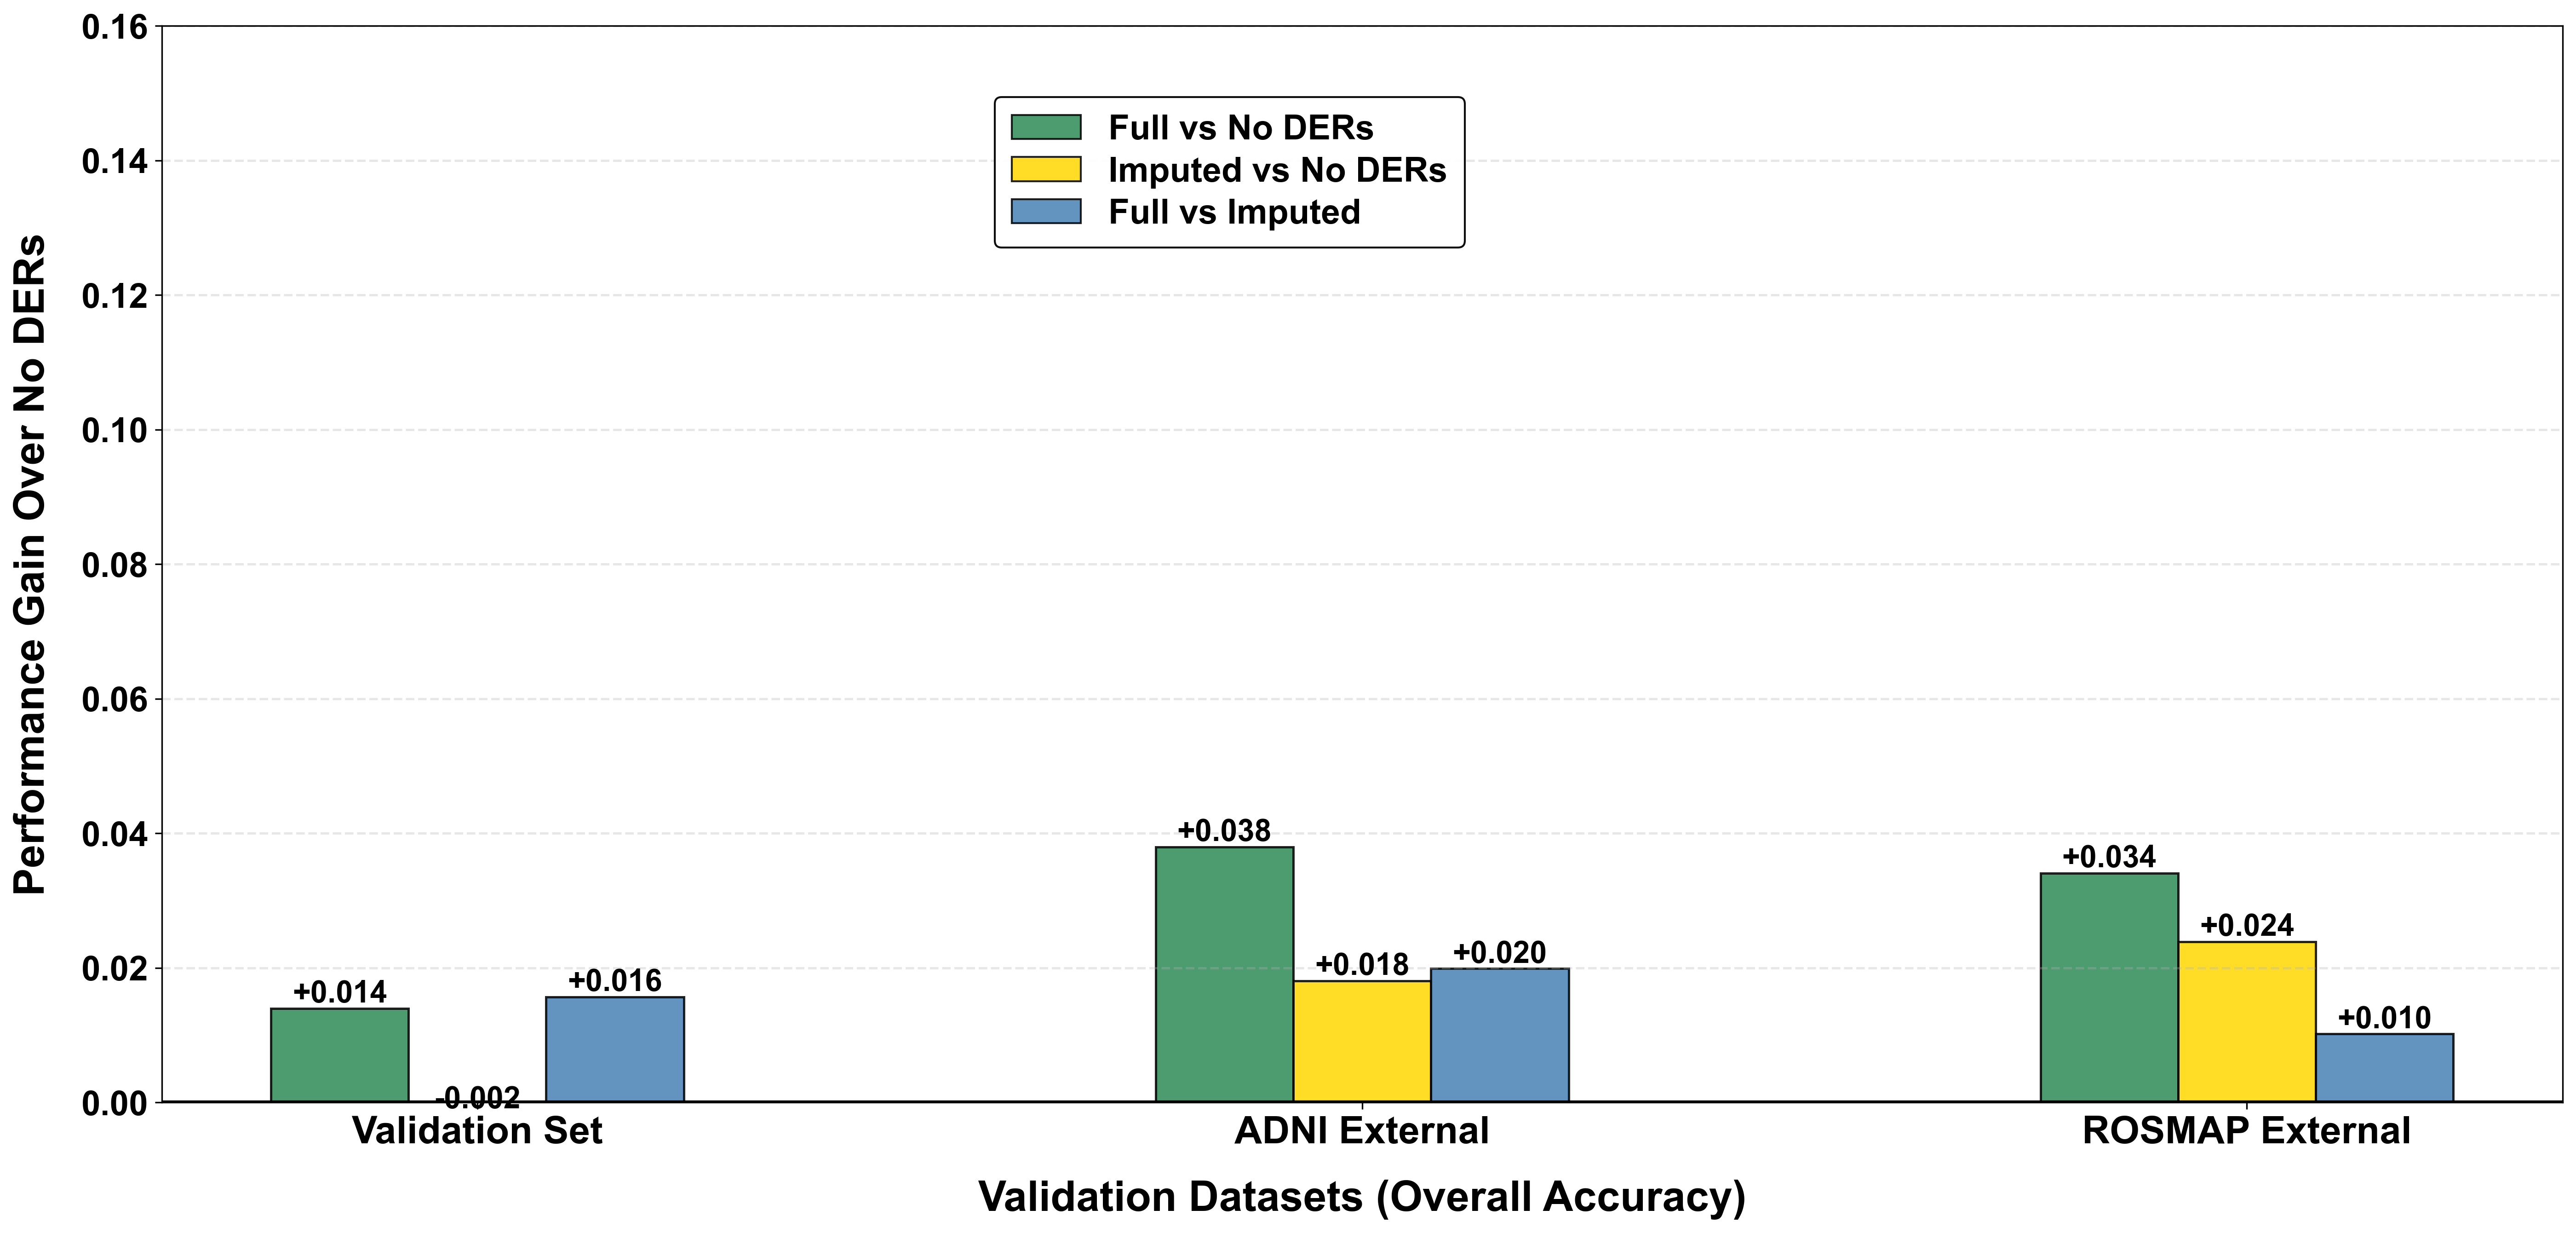


PERFORMANCE GAIN ANALYSIS SUMMARY - OVERALL ACCURACY
Dataset                 Full vs Reduced   Imputed vs Reduced  Full vs Imputed   Recovery Rate
----------------------------------------------------------------------------------------------------
Validation Set                  +0.0140              -0.0017          +0.0157         -12.14%
ADNI External                   +0.0380              +0.0181          +0.0199          47.63%
ROSMAP External                 +0.0341              +0.0239          +0.0102          70.09%

Interpretation:
- A recovery rate near 100% means imputed DERs nearly completely restore the performance lost when removing DERs.
- Rates above 100% indicate imputed DERs actually outperform the full DER method (possible if imputation corrects some noise).
- Rates below 0% suggest imputed DERs perform worse than having no DERs at all.


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.patches import Patch

# =======================================================
# GLOBAL CLEAN FONT + EXPORT SETTINGS - INCREASED & BOLD
# =======================================================
plt.style.use("default")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 16,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.labelsize': 20,
    'axes.titlesize': 22,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'font.weight': 'bold',
})

# =======================================================
# DATA - INCLUDING IMPUTED DERS
# =======================================================
metrics = [
    'Validation Balanced Accuracy',
    'Overall Accuracy',
    'Macro F1-score',
    'Weighted Average',
    'Class 1 (No CI) F1-score',
    'Class 2 (MCI) F1-score',
    'Class 3 (MCI & another cause of CI) F1-score',
    'Class 4 (AD & No other cause of CI) F1-score',
    'Class 5 (AD & another cause of CI) F1-score',
    'Class 6 (Other dementia) F1-score'
]

data = {
    # --- Validation Set ---
    'With DERs (Val)': [
        0.9404, 0.9407, 0.9396, 0.9393, 0.869, 0.818, 1.000, 0.949, 1.000, 1.000
    ],
    'Imputed DERs (Val)': [
        0.9247, 0.9250, 0.9237, 0.9234, 0.859, 0.766, 1.000, 0.917, 1.000, 1.000
    ],
    'Without DERs (Val)': [
        0.9264, 0.9267, 0.9256, 0.9253, 0.851, 0.773, 1.000, 0.928, 1.000, 1.000
    ],

    # --- ADNI External Validation 1 ---
    'With DERs (ADNI)': [
        0.6841, 0.7324, 0.730, 0.690, 0.770, 0.720, 0.000, 0.600, 0.000, 0.000
    ],
    'Imputed DERs (ADNI)': [
        0.6640, 0.7125, 0.710, 0.670, 0.760, 0.680, 0.000, 0.570, 0.000, 0.000
    ],
    'Without DERs (ADNI)': [
        0.6508, 0.6944, 0.690, 0.650, 0.750, 0.670, 0.000, 0.540, 0.000, 0.000
    ],

    # --- ROSMAP External Validation 2 ---
    'With DERs (ROSMAP)': [
        0.3366, 0.6416, 0.610, 0.320, 0.690, 0.460, 0.000, 0.784, 0.000, 0.000
    ],
    'Imputed DERs (ROSMAP)': [
        0.3299, 0.6314, 0.600, 0.320, 0.660, 0.440, 0.000, 0.810, 0.000, 0.000
    ],
    'Without DERs (ROSMAP)': [
        0.3193, 0.6075, 0.580, 0.310, 0.620, 0.440, 0.000, 0.790, 0.000, 0.000
    ]
}

df = pd.DataFrame(data, index=metrics)


# =======================================================
# ENHANCED PERFORMANCE GAIN ANALYSIS - BIGGER PLOT
# =======================================================
fig, ax = plt.subplots(figsize=(20, 10))

summary_metrics = ['Overall Accuracy']
datasets = ['Validation Set', 'ADNI External', 'ROSMAP External']
suffixes = ['(Val)', '(ADNI)', '(ROSMAP)']

colors = {
    'Full vs Reduced': '#2E8B57',      # Green
    'Imputed vs Reduced': '#FFD700',   # Gold
    'Full vs Imputed': '#4682B4'       # Blue
}

# Prepare data (also store gains for later recovery rate calculation)
gains = []  # store (full_reduced, imputed_reduced)
for dataset, suffix in zip(datasets, suffixes):
    metric = 'Overall Accuracy'
    full = df.loc[metric, f'With DERs {suffix}']
    reduced = df.loc[metric, f'Without DERs {suffix}']
    imputed = df.loc[metric, f'Imputed DERs {suffix}']
    
    full_vs_reduced = full - reduced
    imputed_vs_reduced = imputed - reduced
    full_vs_imputed = full - imputed
    
    gains.append({
        'Dataset': dataset,
        'Full vs Reduced': full_vs_reduced,
        'Imputed vs Reduced': imputed_vs_reduced,
        'Full vs Imputed': full_vs_imputed,
        'Full': full,
        'Reduced': reduced,
        'Imputed': imputed
    })

df_comp = pd.DataFrame(gains)

# Plotting
x_positions = []
x_labels = []
bar_width = 0.35
group_spacing = 1.2

for i, dataset in enumerate(datasets):
    base_pos = i * (bar_width * 3 + group_spacing)
    row = df_comp[df_comp['Dataset'] == dataset]
    
    pos1 = base_pos
    pos2 = base_pos + bar_width
    pos3 = base_pos + 2 * bar_width
    
    bar1 = ax.bar(pos1, row['Full vs Reduced'].values[0], bar_width, 
                  color=colors['Full vs Reduced'], alpha=0.85, edgecolor='black', linewidth=1.2)
    bar2 = ax.bar(pos2, row['Imputed vs Reduced'].values[0], bar_width, 
                  color=colors['Imputed vs Reduced'], alpha=0.85, edgecolor='black', linewidth=1.2)
    bar3 = ax.bar(pos3, row['Full vs Imputed'].values[0], bar_width, 
                  color=colors['Full vs Imputed'], alpha=0.85, edgecolor='black', linewidth=1.2)
    
    for bar in [bar1, bar2, bar3]:
        h = bar[0].get_height()
        ax.text(bar[0].get_x() + bar[0].get_width() / 2, h,
                f"{h:+.3f}",
                ha="center", va="bottom",
                fontsize=16, fontweight="bold")

    x_positions.append(base_pos + bar_width)
    x_labels.append(dataset)

ax.set_xlabel("Validation Datasets (Overall Accuracy)", fontweight="bold", fontsize=22, labelpad=15)
ax.set_ylabel("Performance Gain Over No DERs", fontweight="bold", fontsize=22, labelpad=15)
#ax.set_title("(D) Performance Gain Analysis\n" + 
 #            "Full vs No DERs | Imputed vs No DERs | Full vs Imputed",
  #           fontweight="bold", pad=35, fontsize=24)

ax.set_xticks(x_positions)
ax.set_xticklabels(x_labels, fontweight="bold", fontsize=20, rotation=0)

legend_elements = [
    Patch(facecolor=colors['Full vs Reduced'], alpha=0.85, edgecolor='black', 
          label='Full vs No DERs'),
    Patch(facecolor=colors['Imputed vs Reduced'], alpha=0.85, edgecolor='black', 
          label='Imputed vs No DERs'),
    Patch(facecolor=colors['Full vs Imputed'], alpha=0.85, edgecolor='black', 
          label='Full vs Imputed')
]

ax.legend(handles=legend_elements, 
          loc='upper right',
          bbox_to_anchor=(0.55, 0.95),
          fontsize=18, prop={'weight': 'bold'},
          frameon=True,
          edgecolor='black',
          facecolor='white',
          framealpha=0.95,
          borderpad=0.5,
          labelspacing=0.3)

ax.grid(True, alpha=0.3, axis='y', linestyle='--', linewidth=1.2, zorder=0)
ax.axhline(y=0, color='black', linewidth=2, linestyle='-', zorder=10)
ax.set_ylim(0, 0.16)

plt.tight_layout()
fig.subplots_adjust(left=0.08, right=0.95, top=0.90, bottom=0.12)

plt.savefig("/Users/martinnwadiugwu/Downloads/performance_comprehensive_gain_analysisBB.pdf", 
            dpi=300, bbox_inches="tight")
plt.show()

# =======================================================
# SUMMARY TABLE (GAINS) + RECOVERY RATES
# =======================================================
print("\n" + "="*100)
print("PERFORMANCE GAIN ANALYSIS SUMMARY - OVERALL ACCURACY")
print("="*100)
print(f"{'Dataset':<20} {'Full vs Reduced':>18} {'Imputed vs Reduced':>20} {'Full vs Imputed':>16} {'Recovery Rate':>15}")
print("-"*100)

for row in gains:
    dataset = row['Dataset']
    full_vs_reduced = row['Full vs Reduced']
    imputed_vs_reduced = row['Imputed vs Reduced']
    full_vs_imputed = row['Full vs Imputed']
    
    # Compute recovery rate: (Imputed - Reduced) / (Full - Reduced) * 100
    if full_vs_reduced != 0:
        recovery = (imputed_vs_reduced / full_vs_reduced) * 100
    else:
        recovery = np.nan
    
    print(f"{dataset:<20} {full_vs_reduced:>+18.4f} {imputed_vs_reduced:>+20.4f} "
          f"{full_vs_imputed:>+16.4f} {recovery:>14.2f}%")

print("="*100)

# Optional: Additional interpretation
print("\nInterpretation:")
print("- A recovery rate near 100% means imputed DERs nearly completely restore the performance lost when removing DERs.")
print("- Rates above 100% indicate imputed DERs actually outperform the full DER method (possible if imputation corrects some noise).")
print("- Rates below 0% suggest imputed DERs perform worse than having no DERs at all.")

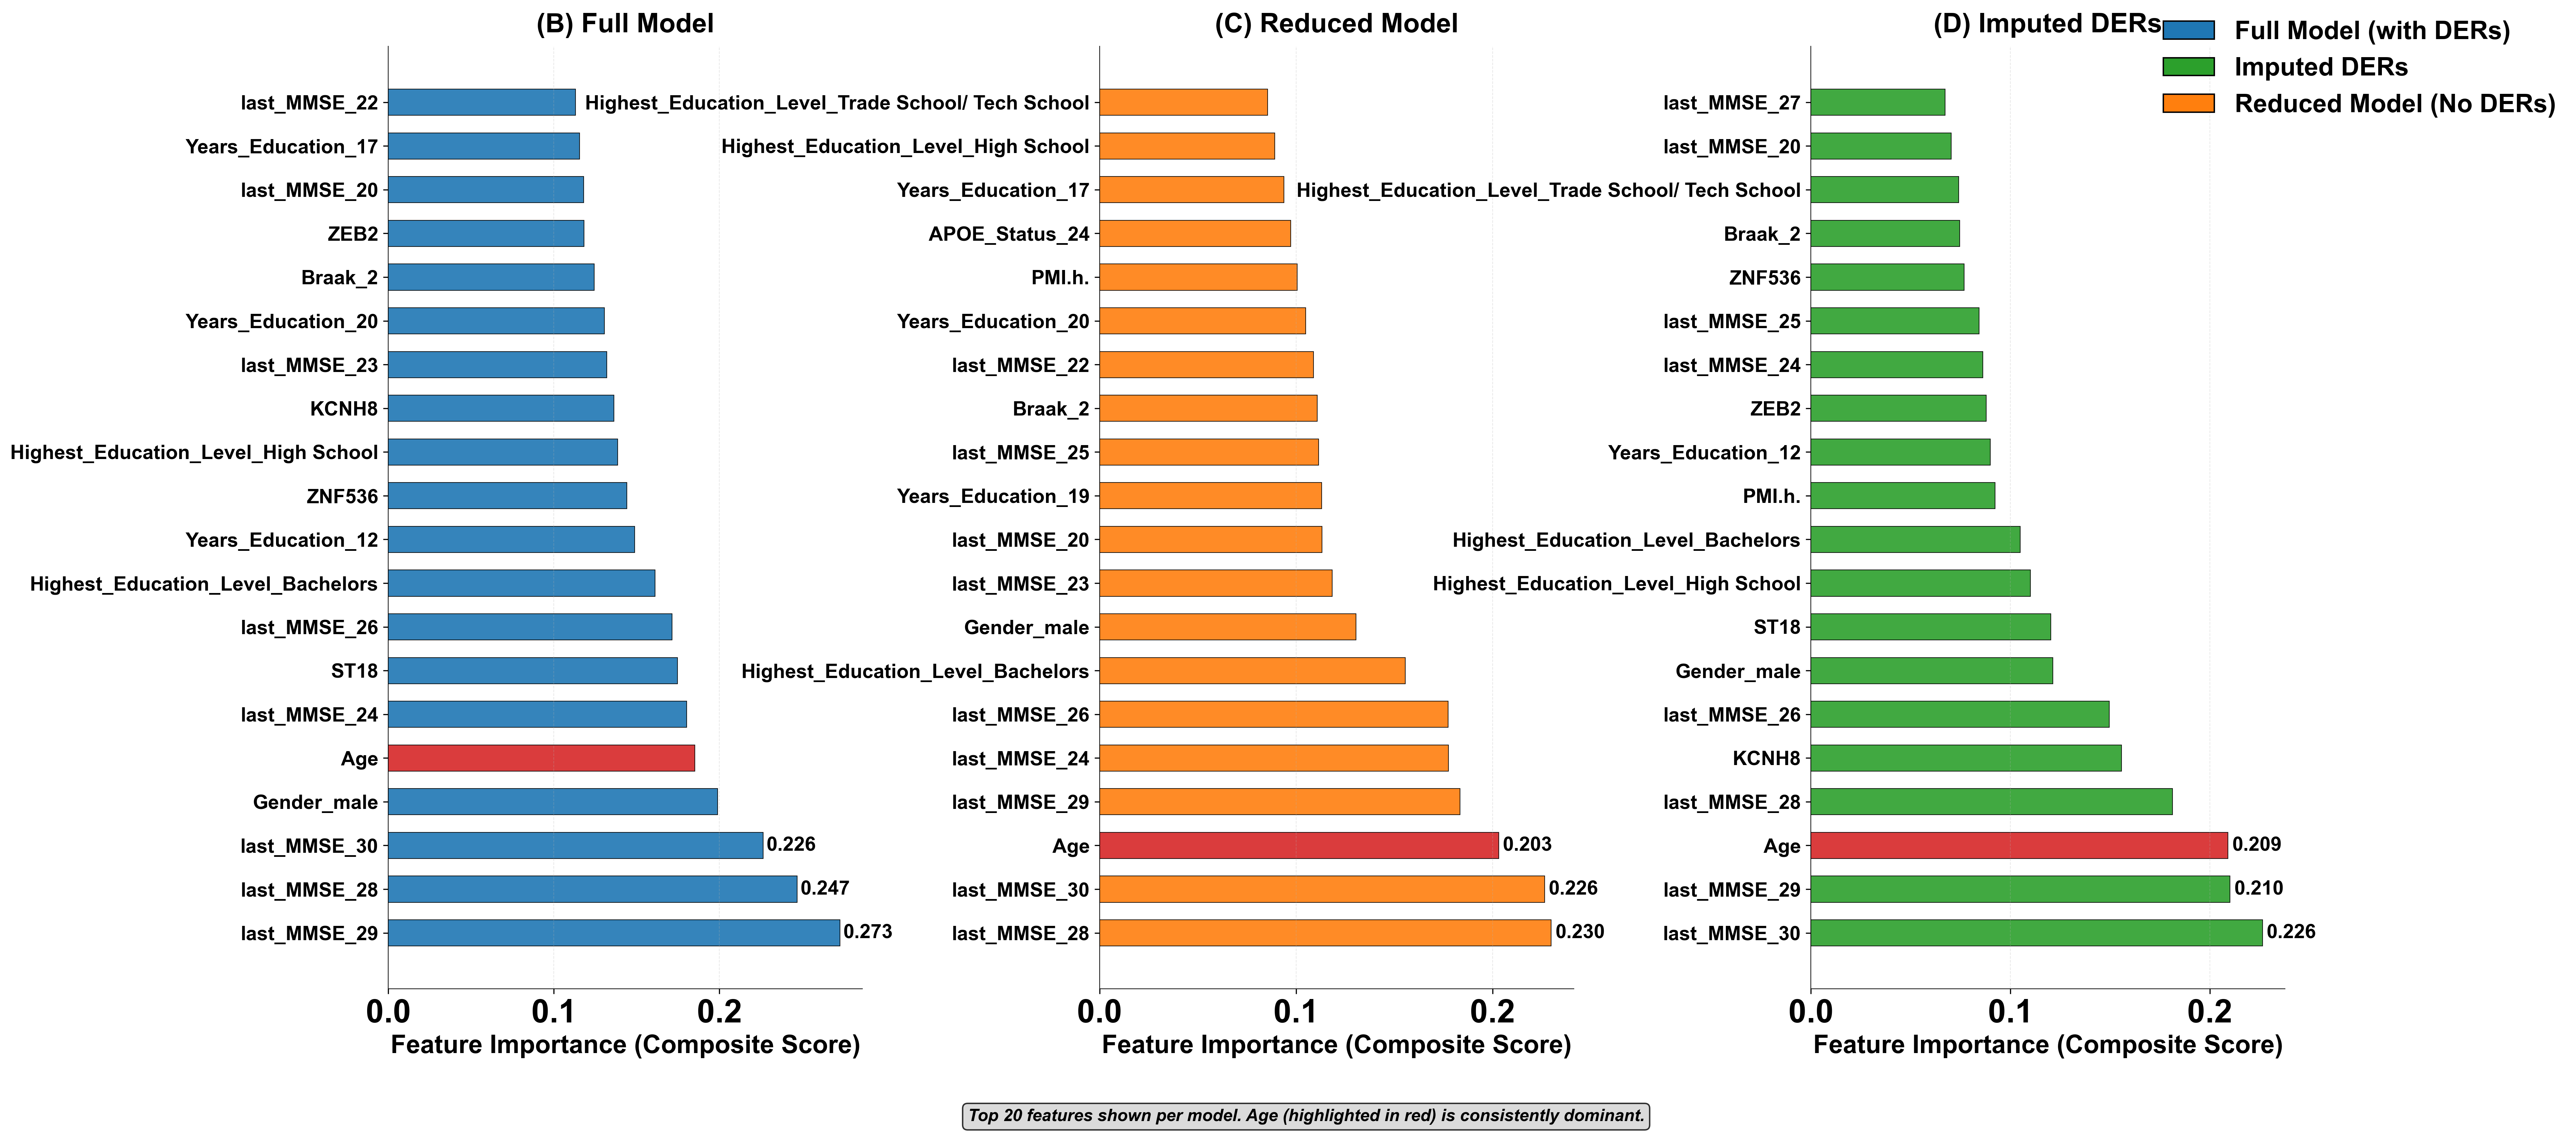

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
from matplotlib import gridspec
from matplotlib.patches import Patch

# =======================================================
# GLOBAL CLEAN FONT SETTINGS - INCREASED & BOLD
# =======================================================
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 18,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'pdf.fonttype': 42,
    'axes.labelsize': 15,
    'axes.titlesize': 16,
    'xtick.labelsize': 23,
    'ytick.labelsize': 28,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'font.weight': 'bold',
})

# =======================================================
# CORRECT FEATURE IMPORTANCE DATA (three tables)
# =======================================================
full_table = """FULL: feature	MI_score	MI_rank	is_DER	domain_stability	native_importance	native_stddev	perm_mean_ROS_MAP2	perm_std_ROS_MAP2	perm_mean_avg	MI_norm	perm_norm	native_norm	stability	raw_composite	composite_score	composite_rank
last_MMSE_29	0.036165390099869965	17	FALSE	0.6404592337377931			0.031133136	0.003885422	0.031133136	0.20309288398071823	0.8874691634387111	0	0.6404592337377931	0.4260701747687358	0.2728805776509121	1
last_MMSE_28	0.036723052	16	FALSE	0.7874800429979544			0.016843689747319257	0.006348103	0.016843689747319257	0.20622452906854424	0.6034376862667048	0	0.7874800429979544	0.3135536596806724	0.24691724940750184	2
last_MMSE_30	0.070217783	5	FALSE	0.42089161729594604			0.036794492	0.003307305	0.036794492	0.394319872	1	0	0.42089161729594604	0.538011955	0.2264447219792405	3
Gender_male	0.046602165572791954	12	FALSE	0.940736254			0.001571785	0.002721837	0.001571785	0.2617023673680569	0.2998778543996703	0	0.940736254	0.21154697033868802	0.19900990451935074	4
Age	0.17807315249560163	1	FALSE	0.47900493149080126			-0.008912229	0.006334725	-0.008912229	1	0.091487001	0	0.47900493149080126	0.3865948005141964	0.18518081593500263	5
last_MMSE_24	0.024247890047350618	26	FALSE	0.7600329697626814			0.010308681647855578	0.001063072	0.010308681647855578	0.13616814049467416	0.4735412565575222	0	0.7600329697626814	0.23707535179614486	0.18018508368315642	6
ST18	0.090292725	4	TRUE	0.5869884289941346			0.001598657	0.002666014	0.001598657	0.5070541145688133	0.3004120079423993	0	0.5869884289941346	0.29763374327604436	0.17470756338124885	7
last_MMSE_26	0.062135453	6	FALSE	0.6147395254312993			0.006217043	0.001218639	0.006217043	0.3489321810107206	0.3922117105026542	0	0.6147395254312993	0.2790109475548139	0.17151905748998345	8
Highest_Education_Level_Bachelors	0.050874346	9	FALSE	0.8208884880979557			-0.001395513	0.002108438	-0.001395513	0.2856935193099525	0.24089684433186292	0	0.8208884880979557	0.19635146949122856	0.1611826609264665	9
Years_Education_12	0.054976247	7	FALSE	0.7341794930401444			-0.001610121	0.000833096	-0.001610121	0.3087284397102611	0.23663108666894733	0	0.7341794930401444	0.20270738856617032	0.1488236077730025	10
ZNF536	0.042415186	13	TRUE	0.6934285370802155			0.002128599	0.001913349	0.002128599	0.2381896751383921	0.31094566521860073	0	0.6934285370802155	0.20774465238587753	0.14405607039017695	11
Highest_Education_Level_High School	0	60	FALSE	0.9352225			0.005127468	0.002877451	0.005127468	0	0.3705542123156282	0	0.9352225	0.1482216849262513	0.13862025476283182	12
KCNH8	0.098294945	3	TRUE	0.705763271			-0.013514883	0.002296896	-0.013514883	0.5519919414474957	0	0	0.705763271	0.1931971795066235	0.13635147338837733	13
last_MMSE_23	0.027544516	23	FALSE	0.8132228817617982			9.095453400830289e-05	0.001668396	9.095453400830289e-05	0.1546809037376579	0.27044337945766106	0	0.8132228817617982	0.16231566809124467	0.13199881536025357	14
Years_Education_20	0.037646581	15	FALSE	0.7846798659743232			-0.001897642	0.00070922	-0.001897642	0.21141076410241444	0.23091601729568947	0	0.7846798659743232	0.16636017435412084	0.13053947931565657	15
Braak_2	0.05251606	8	FALSE	0.5901442933983354			0	0	0	0.2949128436423884	0.26863547515919345	0	0.5901442933983354	0.21067368533851333	0.1243278731717202	16
ZEB2	0.049056495	10	TRUE	0.7093586051961389			-0.0046913	0.007130651	-0.0046913	0.2754850728659735	0.1753864608885949	0	0.7093586051961389	0.1665743598585287	0.11816095557068562	17
last_MMSE_20	0.028092714612941494	22	FALSE	0.8095042768826576			-0.002128599	0.001238233	-0.002128599	0.15775940516151293	0.22632528509978503	0	0.8095042768826576	0.14574590584644354	0.11798193412083318	18
Years_Education_17	0.007969867	35	FALSE	0.9386680893207291			0	0	0	0.044756139	0.26863547515919345	0	0.9386680893207291	0.12311883884506386	0.11556772521808285	19
last_MMSE_22	0.020507962162820137	27	FALSE	0.7169249872481913			0.001255511	0.001636714	0.001255511	0.11516594093725993	0.2935912780890867	0	0.7169249872481913	0.15774459056367565	0.11309103857833433	20
APOE_Status_24	0.033168119	19	FALSE	0.634234351			-0.000326797	0.000653595	-0.000326797	0.18626120196923912	0.2621397198388694	0	0.634234351	0.17004730862478146	0.10784984441117032	21
last_MMSE_25	0	60	FALSE	0.5980840132753029			0.00886055	0.002123035	0.00886055	0	0.44475673068149135	0	0.5980840132753029	0.17790269227259656	0.10640075616687576	22
last_MMSE_27	0	60	FALSE	0.8516923634001141			0.002011523	0.001554806	0.002011523	0	0.3086185487352409	0	0.8516923634001141	0.12344741949409638	0.10513922446457226	23
APOE_Status_33	0	60	FALSE	0.9700716343929935			-0.000152405	0.00303148	-0.000152405	0	0.2656061148574197	0	0.9700716343929935	0.10624244594296789	0.10306278317780412	24
Gender_female	0	60	FALSE	0.940736254			-0.000280756	0.002107503	-0.000280756	0	0.26305487800648175	0	0.940736254	0.1052219512025927	0.098986104	25
Years_Education_18	0.00467197	40	FALSE	0.774458261			0.001351351	0.001103374	0.001351351	0.026236242	0.29549630121350606	0	0.774458261	0.12738120504936343	0.098651427	26
Highest_Education_Level_Graduate (PhD/Masters)	0	60	FALSE	0.7861498600510435			0.002252252	0.001461482	0.002252252	0	0.3134035185830474	0	0.7861498600510435	0.12536140743321897	0.098552853	27
Years_Education_15	0	60	FALSE	0.8780007973871928			0.00045045	0.000900901	0.00045045	0	0.2775890838439643	0	0.8780007973871928	0.11103563353758572	0.097489375	28
Years_Education_19	0	60	FALSE	0.8750688788589216			0.00045045	0.000900901	0.00045045	0	0.2775890838439643	0	0.8750688788589216	0.11103563353758572	0.097163827	29
PMI.h.	0.13519842009878547	2	FALSE	0.26709717736406957			-0.001814205	0.003174823	-0.001814205	0.7592296660335973	0.23257450801577176	0	0.26709717736406957	0.3587601863180678	0.095823833	30
Highest_Education_Level_Trade School/ Tech School	0.019973828745002642	29	FALSE	0.8630920185507901			-0.004854228	0.001962134	-0.004854228	0.11216642410762055	0.1721479215770823	0	0.8630920185507901	0.10811741706850012	0.09331528	31
Years_Education_14	0.014661614451876526	31	FALSE	0.5824394105780967			0.001964731	0.001285478	0.001964731	0.082334783	0.30768844920978966	0	0.5824394105780967	0.1518925538971007	0.08846821	32
Braak_5	0.015158561524724945	30	FALSE	0.6791669217049924			-0.001132797	0.001693248	-0.001132797	0.085125474	0.2461188488964475	0	0.6791669217049924	0.1282414554818947	0.087097355	33
last_MMSE_21	0.028244950402389613	21	FALSE	0.4901920867736596			0.00175764	0.000247306	0.00175764	0.1586143110657136	0.30357210512526034	0	0.4901920867736596	0.17694385092310388	0.086736476	34
Years_Education_16	0	60	FALSE	0.8313929265617367			-0.0004668	0.001938107	-0.0004668	0	0.2593568919414326	0	0.8313929265617367	0.10374275677657303	0.086250994	35
APOE_Status_34	0	60	FALSE	0.8776739704753442			-0.001801802	0.000900901	-0.001801802	0	0.23282104042010904	0	0.8776739704753442	0.093128416	0.081736387	36
Years_Education_13	0	60	FALSE	0.7710629313502783			-0.000574104	0.000872573	-0.000574104	0	0.2572240131099752	0	0.7710629313502783	0.1028896052439901	0.079334361	37
Years_Education_9	0	60	FALSE	0.5661138107090061			0.00257905	0.000653595	0.00257905	0	0.3198992739033718	0	0.5661138107090061	0.12795970956134872	0.072439759	38
Years_Education_23	0.024667177972280463	25	FALSE	0.44530988447784897			0	0	0	0.13852272297414253	0.26863547515919345	0	0.44530988447784897	0.15593714310462728	0.069440351	39
Braak_1	0	60	FALSE	0.5154182687567354			0.001896703	0.001238233	0.001896703	0	0.30633625632539785	0	0.5154182687567354	0.12253450253015914	0.063156521	40
Years_Education_21	0.035422820838945546	18	FALSE	0.3238246648491575			0.00104842	0.002467692	0.00104842	0.19892286031057085	0.28947493400455665	0	0.3238246648491575	0.18541297471052245	0.060041294	41
Braak_4	0.009160962	33	FALSE	0.4120102274961187			0.002415181	0.002432651	0.002415181	0.051444934	0.31664205789456074	0	0.4120102274961187	0.14466255007574066	0.05960245	42
Years_Education_10	0	60	FALSE	0.5404671359798798			0	0	0	0	0.26863547515919345	0	0.5404671359798798	0.10745419006367739	0.058075458	43
Years_Education_24	0	60	FALSE	0.5334568410628536			-0.000326797	0.000653595	-0.000326797	0	0.2621397198388694	0	0.5334568410628536	0.10485588793554777	0.055936091	44
race_HW	0	60	FALSE	0.4476586308151327			0.00186889	0.001278313	0.00186889	0	0.30578342608537035	0	0.4476586308151327	0.12231337043414814	0.054754635938934884	45
Braak_3	0.006396006	37	FALSE	0.42503566819061867			0.001104045	0.000929289	0.001104045	0.035917855	0.2905805944846123	0	0.42503566819061867	0.12880348689756707	0.054746076	46
Years_Education_11	0.001852361	41	FALSE	0.48247781348613383			-0.000777248	0.000971801	-0.000777248	0.010402245033467953	0.25318611115409834	0	0.48247781348613383	0.10491523022335313	0.050619271	47
race_Other	0	60	FALSE	0.4517684043919636			0	0	0	0	0.26863547515919345	0	0.4517684043919636	0.10745419006367739	0.048544408	48
APOE_Status_23	0.004961047	39	FALSE	0.6002427738089582			-0.005098528	0.003457891	-0.005098528	0.027859598781682843	0.16729198027954237	0	0.6002427738089582	0.076667652	0.046019203909067115	49
race_NHW	0.04761115	11	FALSE	0.21099101322810557			0.00141844	0.00070922	0.00141844	0.26736849309024907	0.29682981740059944	0	0.21099101322810557	0.21231089954182694	0.044795692	50
Highest_Education_Level_Professional	0	60	FALSE	0.49244357262684385			-0.002184224	0.001702936	-0.002184224	0	0.22521962461973005	0	0.49244357262684385	0.09008785	0.044363183	51
race_Asian	0.000257906	43	FALSE	0.402993527			0	0	0	0.001448315	0.26863547515919345	0	0.402993527	0.10796110019006173	0.043507625	52
race_Black_or_AA	0.00719469	36	FALSE	0.29924404994582104			0	0	0	0.040403005	0.26863547515919345	0	0.29924404994582104	0.12159524172489218	0.036386653	53
APOE_Status_44	0.020483004251152126	28	FALSE	0.2460367254605677			0	0	0	0.11502578554989108	0.26863547515919345	0	0.2460367254605677	0.14771321500613926	0.036342876	54
APOE_Status_22	0	60	FALSE	0.31685367557658073			0	0	0	0	0.26863547515919345	0	0.31685367557658073	0.10745419006367739	0.034047255077780676	55
Braak_6	0.029889192	20	FALSE	0.2016335352300767			0	0	0	0.16784782631018472	0.26863547515919345	0	0.2016335352300767	0.16620092927224203	0.033511680927686104	56
last_MMSE_18	0	60	FALSE	0.2885933575979695			0.000900901	0.001103374	0.000900901	0	0.28654269252873515	0	0.2885933575979695	0.11461707701149407	0.033077727	57
Braak_0	0	60	FALSE	0.2532379655801835			0.00177305	0	0.00177305	0	0.303878403	0	0.2532379655801835	0.1215513611843804	0.030781419419834578	58
last_MMSE_1	0	60	FALSE	0.2552850577567978			0	0	0	0	0.26863547515919345	0	0.2552850577567978	0.10745419006367739	0.027431449116615807	59
last_MMSE_2	0.039401532	14	FALSE	0.12783505154639624			0	0	0	0.22126598825121502	0.26863547515919345	0	0.12783505154639624	0.18489728595160265	0.023636354	60
last_MMSE_0	0	60	FALSE	0.1923420043775598			0.00035461	0.00070922	0.00035461	0	0.27568406071954493	0	0.1923420043775598	0.11027362428781798	0.02121025	61
last_MMSE_14	0.005390248	38	FALSE	0.17835616438356788			0	0	0	0.030269851	0.26863547515919345	0	0.17835616438356788	0.11804863793545431	0.021054702272872178	62
last_MMSE_8	0.001636178	42	FALSE	0.18267737608041476			0	0	0	0.009188236	0.26863547515919345	0	0.18267737608041476	0.11067007251984112	0.020216918458553793	63
last_MMSE_3	0	60	FALSE	0.18267737608041482			0	0	0	0	0.26863547515919345	0	0.18267737608041482	0.10745419006367739	0.019629449489678766	64
Years_Education_22	0.025501656917732873	24	FALSE	0.11825439188737964			0	0	0	0.1432088810712932	0.26863547515919345	0	0.11825439188737964	0.157577298	0.018634208	65
last_MMSE_6	0.008989251	34	FALSE	0.14888507718696764			-0.000326797	0.000653595	-0.000326797	0.050480662	0.2621397198388694	0	0.14888507718696764	0.12252411955668015	0.018242012997461574	66
last_MMSE_12	0	60	FALSE	0.14708125537779926			0	0	0	0	0.26863547515919345	0	0.14708125537779926	0.10745419006367739	0.015804497170170313	67
last_MMSE_16	0.011741301489162526	32	FALSE	0.11473592283561843			0	0	0	0.065935271	0.26863547515919345	0	0.11473592283561843	0.13053153475946688	0.014976656099777037	68
last_MMSE_17	0	60	FALSE	0.13392343687388109			-0.000326797	0.000653595	-0.000326797	0	0.2621397198388694	0	0.13392343687388109	0.10485588793554777	0.014042660888791081	69
race_unknown	0	60	FALSE	0.13039373206574567			0	0	0	0	0.26863547515919345	0	0.13039373206574567	0.10745419006367739	0.014011353	70
last_MMSE_10	0	60	FALSE	0.11519522263572811			0.00045045	0.000900901	0.00045045	0	0.2775890838439643	0	0.11519522263572811	0.11103563353758572	0.012790774525861305	71
last_MMSE_15	0	60	FALSE	0.11519522263572807			0.00045045	0.000900901	0.00045045	0	0.2775890838439643	0	0.11519522263572807	0.11103563353758572	0.012790774525861302	72
last_MMSE_11	0	60	FALSE	0.1151952226357279			0.00045045	0.000900901	0.00045045	0	0.2775890838439643	0	0.1151952226357279	0.11103563353758572	0.012790774525861283	73
last_MMSE_13	0	60	FALSE	0.11204819277108845			0.00045045	0.000900901	0.00045045	0	0.2775890838439643	0	0.11204819277108845	0.11103563353758572	0.012441342071079338	74
Years_Education_25	0	60	FALSE	0.074570488			0	0	0	0	0.26863547515919345	0	0.074570488	0.10745419006367739	0.008012911	75
last_MMSE_19	0	60	FALSE	0.093385045			-0.004054054	0.000900901	-0.004054054	0	0.18805299699625358	0	0.093385045	0.075221199	0.007024535	76"""

imputed_table = """IMPUTED: feature	MI_score	MI_rank	is_DER	domain_stability	native_importance	native_stddev	perm_mean_ROS_MAP2	perm_std_ROS_MAP2	perm_mean_avg	MI_norm	perm_norm	native_norm	stability	raw_composite	composite_score	composite_rank
last_MMSE_30	0.070217783	5	FALSE	0.42089161729594604			0.030621610346266148	0.003265986	0.030621610346266148	0.394319872	1	0	0.42089161729594604	0.538011955	0.2264447219792405	1
last_MMSE_29	0.036165390099869965	17	FALSE	0.6404592337377931			0.018872314	0.004412314	0.018872314	0.20309288398071823	0.642594593	0	0.6404592337377931	0.32812034673669144	0.2101477058447604	2
Age	0.17807315249560163	1	FALSE	0.47900493149080126			0.004865692	0.00074626	0.004865692	1	0.2165228973378375	0	0.47900493149080126	0.43660915893513497	0.2091379402639807	3
last_MMSE_28	0.036723052	16	FALSE	0.7874800429979544			0.010736769309985817	0.002840686	0.010736769309985817	0.20622452906854424	0.3951169876466994	0	0.7874800429979544	0.23022538023267025	0.18129789232484356	4
KCNH8	0.098294945	3	TRUE	0.705763271			0	0	0	0.5519919414474957	0.068511945	0	0.705763271	0.22060195733584992	0.15569275903467245	5
last_MMSE_26	0.062135453	6	FALSE	0.6147395254312993			0.007696933	0.002204096	0.007696933	0.3489321810107206	0.30264729925171424	0	0.6147395254312993	0.24318518305443793	0.14949554402280882	6
Gender_male	0.046602165572791954	12	FALSE	0.940736254			0.000817463	0.001770337	0.000817463	0.2617023673680569	0.093378608	0	0.940736254	0.12894727170275908	0.12130537340483859	7
ST18	0.090292725	4	TRUE	0.5869884289941346			0	0	0	0.5070541145688133	0.068511945	0	0.5869884289941346	0.20487371792831108	0.12025850182892679	8
Highest_Education_Level_High School	0	60	FALSE	0.9352225			0.007418996	0.003619004	0.007418996	0	0.29419263375120774	0	0.9352225	0.1176770535004831	0.11005422819267448	9
Highest_Education_Level_Bachelors	0.050874346	9	FALSE	0.8208884880979557			2.7812543457084172e-05	0.001122754	2.7812543457084172e-05	0.2856935193099525	0.069357983	0	0.8208884880979557	0.12773592486670216	0.10485695023962119	10
PMI.h.	0.13519842009878547	2	FALSE	0.26709717736406957			0.00433575	0.002735778	0.00433575	0.7592296660335973	0.2004024397912346	0	0.26709717736406957	0.3458913590282529	0.092386606	11
Years_Education_12	0.054976247	7	FALSE	0.7341794930401444			-0.00106383	0.000868613	-0.00106383	0.3087284397102611	0.036150984	0	0.7341794930401444	0.12251534730635337	0.089948256	12
ZEB2	0.049056495	10	TRUE	0.7093586051961389			0	0	0	0.2754850728659735	0.068511945	0	0.7093586051961389	0.12382455333231715	0.087836012	13
last_MMSE_24	0.024247890047350618	26	FALSE	0.7600329697626814			0.003153153	0.001103374	0.003153153	0.13616814049467416	0.1644286669753562	0	0.7600329697626814	0.11343031596327845	0.08621078	14
last_MMSE_25	0	60	FALSE	0.5980840132753029			0.009323404	0.000842499	0.009323404	0	0.3521233843814489	0	0.5980840132753029	0.14084935375257956	0.084239747	15
ZNF536	0.042415186	13	TRUE	0.6934285370802155			0	0	0	0.2381896751383921	0.068511945	0	0.6934285370802155	0.11077116412766366	0.076811886	16
Braak_2	0.05251606	8	FALSE	0.5901442933983354			-0.00035461	0.00070922	-0.00035461	0.2949128436423884	0.057724958	0	0.5901442933983354	0.12630947829690756	0.074540818	17
Highest_Education_Level_Trade School/ Tech School	0.019973828745002642	29	FALSE	0.8630920185507901			0.001581369	0.002123035	0.001581369	0.11216642410762055	0.11661607586904749	0	0.8630920185507901	0.085904679	0.074143643	18
last_MMSE_20	0.028092714612941494	22	FALSE	0.8095042768826576			0.00035461	0.00070922	0.00035461	0.15775940516151293	0.079298932	0	0.8095042768826576	0.086935364	0.070374549	19
last_MMSE_27	0	60	FALSE	0.8516923634001141			0.004235963	0.003112532	0.004235963	0	0.19736699193405483	0	0.8516923634001141	0.078946797	0.067238384	20
Years_Education_20	0.037646581	15	FALSE	0.7846798659743232			-0.001447192	0.00099757	-0.001447192	0.21141076410241444	0.024489375932500244	0	0.7846798659743232	0.083789518	0.065747948	21
last_MMSE_23	0.027544516	23	FALSE	0.8132228817617982			-0.000215547	0.001326829	-0.000215547	0.1546809037376579	0.061955149	0	0.8132228817617982	0.078920376	0.064179855	22
last_MMSE_22	0.020507962162820137	27	FALSE	0.7169249872481913			0.001633987	0	0.001633987	0.11516594093725993	0.11821668867509351	0	0.7169249872481913	0.087594755	0.062798868	23
APOE_Status_24	0.033168119	19	FALSE	0.634234351			0	0	0	0.18626120196923912	0.068511945	0	0.634234351	0.092596199	0.05872769	24
Braak_5	0.015158561524724945	30	FALSE	0.6791669217049924			0.000792657	0.003548298	0.000792657	0.085125474	0.092624033	0	0.6791669217049924	0.066843529	0.045397914	25
last_MMSE_21	0.028244950402389613	21	FALSE	0.4901920867736596			0.00045045	0.000900901	0.00045045	0.1586143110657136	0.082214333	0	0.4901920867736596	0.088400742	0.043333344324726346	26
Years_Education_16	0	60	FALSE	0.8313929265617367			0.001949321	0.001241342	0.001949321	0	0.12780893256275327	0	0.8313929265617367	0.051123573025101315	0.042503777	27
Gender_female	0	60	FALSE	0.940736254			0.001447192	0.001739024	0.001447192	0	0.1125345132136309	0	0.940736254	0.045013805	0.042346119	28
APOE_Status_33	0	60	FALSE	0.9700716343929935			0.001087696	0.002669496	0.001087696	0	0.10159889786375377	0	0.9700716343929935	0.040639559	0.039423284	29
Years_Education_13	0	60	FALSE	0.7710629313502783			0.00177305	0	0.00177305	0	0.12244687966249952	0	0.7710629313502783	0.048978752	0.0377657	30
Years_Education_17	0.007969867	35	FALSE	0.9386680893207291			-0.000326797	0.000653595	-0.000326797	0.044756139	0.058570995752660254	0	0.9386680893207291	0.039093047082450566	0.036695395810609176	31
Years_Education_19	0	60	FALSE	0.8750688788589216			0.00045045	0.001438438	0.00045045	0	0.082214333	0	0.8750688788589216	0.032885733	0.028777281852478562	32
Braak_3	0.006396006	37	FALSE	0.42503566819061867			0.002072034	0.00066967	0.002072034	0.035917855	0.1315417902854238	0	0.42503566819061867	0.065187965	0.02770721	33
race_NHW	0.04761115	11	FALSE	0.21099101322810557			0	0	0	0.26736849309024907	0.068511945	0	0.21099101322810557	0.12098375041081359	0.025526484083313792	34
Years_Education_21	0.035422820838945546	18	FALSE	0.3238246648491575			-0.001570845	0.001651504	-0.001570845	0.19892286031057085	0.020727935838292855	0	0.3238246648491575	0.077914175	0.025230531750157242	35
Years_Education_15	0	60	FALSE	0.8780007973871928			0	0	0	0	0.068511945	0	0.8780007973871928	0.027404778	0.024061417	36
Highest_Education_Level_Graduate (PhD/Masters)	0	60	FALSE	0.7861498600510435			8.437724332592822e-05	0.000654133	8.437724332592822e-05	0	0.071078642	0	0.7861498600510435	0.028431456614818613	0.022351385638786966	37
APOE_Status_34	0	60	FALSE	0.8776739704753442			-0.000191681	0.001285478	-0.000191681	0	0.062681141	0	0.8776739704753442	0.025072456311845348	0.022005442	38
Braak_4	0.009160962	33	FALSE	0.4120102274961187			0.00059797	0.001370032	0.00059797	0.051444934	0.086701766	0	0.4120102274961187	0.052686433245481945	0.021707349	39
Years_Education_23	0.024667177972280463	25	FALSE	0.44530988447784897			-0.002252252	0	-0.002252252	0.13852272297414253	0	0	0.44530988447784897	0.048482953040949885	0.021589938	40
race_HW	0	60	FALSE	0.4476586308151327			0.00141844	0.00070922	0.00141844	0	0.11165989264461283	0	0.4476586308151327	0.044663957057845136	0.019994205863300835	41
Years_Education_9	0	60	FALSE	0.5661138107090061			0.00035461	0.00070922	0.00035461	0	0.079298932	0	0.5661138107090061	0.031719573	0.017956888139242826	42
Years_Education_14	0.014661614451876526	31	FALSE	0.5824394105780967			-0.002252252	0	-0.002252252	0.082334783	0	0	0.5824394105780967	0.028817174213184842	0.016784257963253706	43
Years_Education_24	0	60	FALSE	0.5334568410628536			0.000326797	0.000653595	0.000326797	0	0.078452893	0	0.5334568410628536	0.031381157357388625	0.016740493072768863	44
APOE_Status_44	0.020483004251152126	28	FALSE	0.2460367254605677			0	0	0	0.11502578554989108	0.068511945	0	0.2460367254605677	0.067663803	0.016647780466155875	45
Braak_6	0.029889192	20	FALSE	0.2016335352300767			-0.00045045	0.000900901	-0.00045045	0.16784782631018472	0.054809556	0	0.2016335352300767	0.080670561	0.01626589	46
Years_Education_10	0	60	FALSE	0.5404671359798798			0	0	0	0	0.068511945	0	0.5404671359798798	0.027404778	0.014811381785526916	47
APOE_Status_23	0.004961047	39	FALSE	0.6002427738089582			-0.001211349	0.000633472	-0.001211349	0.027859598781682843	0.031663551	0	0.6002427738089582	0.022416280048856714	0.013455210115004163	48
last_MMSE_2	0.039401532	14	FALSE	0.12783505154639624			0	0	0	0.22126598825121502	0.068511945	0	0.12783505154639624	0.10484787371715168	0.013403233341162129	49
Years_Education_18	0.00467197	40	FALSE	0.774458261			-0.001661799	0.001077938	-0.001661799	0.026236242	0.017961162273556087	0	0.774458261	0.016367149473383427	0.012675674123048075	50
race_Black_or_AA	0.00719469	36	FALSE	0.29924404994582104			0	0	0	0.040403005	0.068511945	0	0.29924404994582104	0.041545829	0.012432342	51
race_Other	0	60	FALSE	0.4517684043919636			0	0	0	0	0.068511945	0	0.4517684043919636	0.027404778	0.012380612752625883	52
Years_Education_11	0.001852361	41	FALSE	0.48247781348613383			-0.00045045	0.000900901	-0.00045045	0.010402245033467953	0.054809556	0	0.48247781348613383	0.025564608	0.012334356	53
Braak_1	0	60	FALSE	0.5154182687567354			-0.00035461	0.00070922	-0.00035461	0	0.057724958	0	0.5154182687567354	0.023089983022071617	0.011900999074858564	54
race_Asian	0.000257906	43	FALSE	0.402993527			0	0	0	0.001448315	0.068511945	0	0.402993527	0.027911687955610782	0.01124823	55
Years_Education_22	0.025501656917732873	24	FALSE	0.11825439188737964			0	0	0	0.1432088810712932	0.068511945	0	0.11825439188737964	0.077527886	0.009168013	56
APOE_Status_22	0	60	FALSE	0.31685367557658073			0	0	0	0	0.068511945	0	0.31685367557658073	0.027404778	0.008683305	57
last_MMSE_1	0	60	FALSE	0.2552850577567978			0.00035461	0.00070922	0.00035461	0	0.079298932	0	0.2552850577567978	0.031719573	0.008097533	58
last_MMSE_14	0.005390248	38	FALSE	0.17835616438356788			0.00035461	0.00070922	0.00035461	0.030269851	0.079298932	0	0.17835616438356788	0.042314021	0.007546966	59
last_MMSE_6	0.008989251	34	FALSE	0.14888507718696764			0.00035461	0.00070922	0.00035461	0.050480662	0.079298932	0	0.14888507718696764	0.049387804	0.007353107	60
Braak_0	0	60	FALSE	0.2532379655801835			0	0	0	0	0.068511945	0	0.2532379655801835	0.027404778	0.00693993	61
last_MMSE_18	0	60	FALSE	0.2885933575979695			-0.000326797	0.000653595	-0.000326797	0	0.058570995752660254	0	0.2885933575979695	0.023428398301064104	0.00676128	62
last_MMSE_16	0.011741301489162526	32	FALSE	0.11473592283561843			2.7812543457095275e-05	5.562508691419055e-05	2.7812543457095275e-05	0.065935271	0.069357983	0	0.11473592283561843	0.050820537804008394	0.005830941	63
last_MMSE_8	0.001636178	42	FALSE	0.18267737608041476			0	0	0	0.009188236	0.068511945	0	0.18267737608041476	0.03062066	0.005593702	64
last_MMSE_3	0	60	FALSE	0.18267737608041482			-1.11E-17	0.001033424	-1.11E-17	0	0.068511945	0	0.18267737608041482	0.027404778	0.005006233	65
last_MMSE_19	0	60	FALSE	0.093385045			0.002151526	0.002511022	0.002151526	0	0.1339598589174142	0	0.093385045	0.053583944	0.005003939	66
last_MMSE_15	0	60	FALSE	0.11519522263572807			0.00080506	0.00099757	0.00080506	0	0.093001321	0	0.11519522263572807	0.037200528	0.004285323	67
last_MMSE_0	0	60	FALSE	0.1923420043775598			-0.00045045	0.000900901	-0.00045045	0	0.054809556	0	0.1923420043775598	0.021923822263381146	0.004216872	68
last_MMSE_17	0	60	FALSE	0.13392343687388109			0	0	0	0	0.068511945	0	0.13392343687388109	0.027404778	0.003670142	69
last_MMSE_11	0	60	FALSE	0.1151952226357279			0.00035461	0.00070922	0.00035461	0	0.079298932	0	0.1151952226357279	0.031719573	0.003653943	70
race_unknown	0	60	FALSE	0.13039373206574567			0	0	0	0	0.068511945	0	0.13039373206574567	0.027404778	0.003573411	71
last_MMSE_12	0	60	FALSE	0.14708125537779926			-0.00045045	0.000900901	-0.00045045	0	0.054809556	0	0.14708125537779926	0.021923822263381146	0.003224583	72
last_MMSE_10	0	60	FALSE	0.11519522263572811			0	0	0	0	0.068511945	0	0.11519522263572811	0.027404778	0.003156899	73
last_MMSE_13	0	60	FALSE	0.11204819277108845			0	0	0	0	0.068511945	0	0.11204819277108845	0.027404778	0.003070656	74
Highest_Education_Level_Professional	0	60	FALSE	0.49244357262684385			-0.00177305	0.001424449	-0.00177305	0	0.014577009483631609	0	0.49244357262684385	0.005830804	0.002871342	75
Years_Education_25	0	60	FALSE	0.074570488			0	0	0	0	0.068511945	0	0.074570488	0.027404778	0.002043588	76"""

reduced_table = """REDUCED: feature	MI_score	MI_rank	is_DER	domain_stability	native_importance	native_stddev	perm_mean_ROS_MAP2	perm_std_ROS_MAP2	perm_mean_avg	MI_norm	perm_norm	native_norm	stability	raw_composite	composite_score	composite_rank
last_MMSE_28	0.036723052	16	FALSE	0.7874800429979544			0.012195424	0.002880345	0.012195424	0.20622452906854424	0.5492741784289039	0	0.7874800429979544	0.29188825654555206	0.22985617681508927	1
last_MMSE_30	0.070217783	5	FALSE	0.42089161729594604			0.028459722014165068	0.008623049	0.028459722014165068	0.394319872	1	0	0.42089161729594604	0.538011955	0.2264447219792405	2
Age	0.17807315249560163	1	FALSE	0.47900493149080126			-0.00093266	0.004378963	-0.00093266	1	0.18546095175176286	0	0.47900493149080126	0.42418438070070513	0.20318641021700923	3
last_MMSE_29	0.036165390099869965	17	FALSE	0.6404592337377931			0.011789699586946135	0.005863373	0.011789699586946135	0.20309288398071823	0.5380304910529621	0	0.6404592337377931	0.2862947058144362	0.18336008790910072	4
last_MMSE_24	0.024247890047350618	26	FALSE	0.7600329697626814			0.009142756	0.005684038	0.009142756	0.13616814049467416	0.464676832	0	0.7600329697626814	0.23352958210710356	0.17749018181629986	5
last_MMSE_26	0.062135453	6	FALSE	0.6147395254312993			0.007381599	0.002711556	0.007381599	0.3489321810107206	0.41587061389803914	0	0.6147395254312993	0.2884745089129679	0.177336683	6
Highest_Education_Level_Bachelors	0.050874346	9	FALSE	0.8208884880979557			0.00045045	0.000900901	0.00045045	0.2856935193099525	0.22379052057387253	0	0.8208884880979557	0.1895089399880324	0.15556570722782212	7
Gender_male	0.046602165572791954	12	FALSE	0.940736254			-0.003382231	0.002700928	-0.003382231	0.2617023673680569	0.11757699392619196	0	0.940736254	0.13862662614929672	0.13041109305249135	8
last_MMSE_23	0.027544516	23	FALSE	0.8132228817617982			0.000613379	0.000766365	0.000613379	0.1546809037376579	0.22830570211854206	0	0.8132228817617982	0.1454605971555971	0.1182918860016667	9
last_MMSE_20	0.028092714612941494	22	FALSE	0.8095042768826576			0	0	0	0.15775940516151293	0.21130737159743285	0	0.8095042768826576	0.13973874044550266	0.11311910803683001	10
Years_Education_19	0	60	FALSE	0.8750688788589216			0.004025302	0	0.004025302	0	0.32285891564221275	0	0.8750688788589216	0.1291435662568851	0.11300951573625531	11
last_MMSE_25	0	60	FALSE	0.5980840132753029			0.009175884	0.00266717	0.009175884	0	0.465594897	0	0.5980840132753029	0.1862379587719064	0.11138594580650218	12
Braak_2	0.05251606	8	FALSE	0.5901442933983354			0	0	0	0.2949128436423884	0.21130737159743285	0	0.5901442933983354	0.18774244391380907	0.11079513190439147	13
last_MMSE_22	0.020507962162820137	27	FALSE	0.7169249872481913			0.002439047	0.00099757	0.002439047	0.11516594093725993	0.2788996913993569	0	0.7169249872481913	0.15186795588778373	0.10887793233825824	14
Years_Education_20	0.037646581	15	FALSE	0.7846798659743232			-0.002252252	0	-0.002252252	0.21141076410241444	0.14889162671523445	0	0.7846798659743232	0.13355041812193882	0.10479432419273778	15
PMI.h.	0.13519842009878547	2	FALSE	0.26709717736406957			0.002347314	0.004140173	0.002347314	0.7592296660335973	0.27635753036160127	0	0.26709717736406957	0.3762733952563996	0.10050156179017922	16
APOE_Status_24	0.033168119	19	FALSE	0.634234351			0.000326797	0.000653595	0.000326797	0.18626120196923912	0.2203637737960264	0	0.634234351	0.15333693020764425	0.097251548	17
Years_Education_17	0.007969867	35	FALSE	0.9386680893207291			-2.78E-05	0.001077938	-2.78E-05	0.044756139	0.2105366139635098	0	0.9386680893207291	0.099879294	0.093753506	18
Highest_Education_Level_High School	0	60	FALSE	0.9352225			0.000967989	0.002259967	0.000967989	0	0.23813286195105837	0	0.9352225	0.095253145	0.089082884	19
Highest_Education_Level_Trade School/ Tech School	0.019973828745002642	29	FALSE	0.8630920185507901			-0.002234963	0.001981555	-0.002234963	0.11216642410762055	0.14937074632550976	0	0.8630920185507901	0.099006547	0.08545176	20
Years_Education_12	0.054976247	7	FALSE	0.7341794930401444			-0.006940733	0.001283724	-0.006940733	0.3087284397102611	0.018961679358871972	0	0.7341794930401444	0.11563962564214017	0.084900242	21
Braak_5	0.015158561524724945	30	FALSE	0.6791669217049924			-1.24E-05	0.001706517	-1.24E-05	0.085125474	0.21096365535527772	0	0.6791669217049924	0.1141793780654268	0.077546857	22
Years_Education_18	0.00467197	40	FALSE	0.774458261			0.00045045	0.000900901	0.00045045	0.026236242	0.22379052057387253	0	0.774458261	0.098698893	0.076438173	23
Years_Education_15	0	60	FALSE	0.8780007973871928			0.000191681	0.001285478	0.000191681	0	0.21661934988527928	0	0.8780007973871928	0.08664774	0.076076785	24
Years_Education_16	0	60	FALSE	0.8313929265617367			0	0	0	0	0.21130737159743285	0	0.8313929265617367	0.084522949	0.070271782	25
last_MMSE_21	0.028244950402389613	21	FALSE	0.4901920867736596			0	0	0	0.1586143110657136	0.21130737159743285	0	0.4901920867736596	0.1400379575119729	0.068645499	26
last_MMSE_27	0	60	FALSE	0.8516923634001141			-0.001274867	0.001935664	-0.001274867	0	0.17597750816140015	0	0.8516923634001141	0.070391003	0.05995148	27
Highest_Education_Level_Graduate (PhD/Masters)	0	60	FALSE	0.7861498600510435			-0.00080506	0.001194513	-0.00080506	0	0.18899706278847686	0	0.7861498600510435	0.075598825	0.059432006	28
Years_Education_13	0	60	FALSE	0.7710629313502783			-0.000697757	0.00132232	-0.000697757	0	0.1919707290653009	0	0.7710629313502783	0.076788292	0.059208605	29
APOE_Status_33	0	60	FALSE	0.9700716343929935			-0.002972935	0.002451746	-0.002972935	0	0.12891962991729994	0	0.9700716343929935	0.051567852	0.05002451	30
Years_Education_23	0.024667177972280463	25	FALSE	0.44530988447784897			-0.002156412	0.001278313	-0.002156412	0.13852272297414253	0.15154761585915755	0	0.44530988447784897	0.1091019993846129	0.048584199	31
Years_Education_9	0	60	FALSE	0.5661138107090061			0	0	0	0	0.21130737159743285	0	0.5661138107090061	0.084522949	0.047849609	32
Braak_3	0.006396006	37	FALSE	0.42503566819061867			0.000980392	0.00248414	0.000980392	0.035917855	0.23847657819321413	0	0.42503566819061867	0.1079618803810078	0.04588765	33
Years_Education_10	0	60	FALSE	0.5404671359798798			0	0	0	0	0.21130737159743285	0	0.5404671359798798	0.084522949	0.045681876	34
Years_Education_24	0	60	FALSE	0.5334568410628536			0	0	0	0	0.21130737159743285	0	0.5334568410628536	0.084522949	0.045089345178264434	35
Braak_1	0	60	FALSE	0.5154182687567354			0	0	0	0	0.21130737159743285	0	0.5154182687567354	0.084522949	0.043564671857713996	36
APOE_Status_34	0	60	FALSE	0.8776739704753442			-0.003153153	0.001801802	-0.003153153	0	0.1239253287623542	0	0.8776739704753442	0.049570132	0.043506414	37
Highest_Education_Level_Professional	0	60	FALSE	0.49244357262684385			0.000258769	0.001484941	0.000258769	0	0.2184785422860258	0	0.49244357262684385	0.087391417	0.043035342	38
Braak_4	0.009160962	33	FALSE	0.4120102274961187			9.095453400832509e-05	0.002833552	9.095453400832509e-05	0.051444934	0.2138279573732339	0	0.4120102274961187	0.10353690986720993	0.042658266	39
Years_Education_11	0.001852361	41	FALSE	0.48247781348613383			0	0	0	0.010402245033467953	0.21130737159743285	0	0.48247781348613383	0.088163734	0.042537045802415664	40
Gender_female	0	60	FALSE	0.940736254			-0.003736841	0.002770016	-0.003736841	0	0.10774983409367568	0	0.940736254	0.043099934	0.04054567	41
Years_Education_14	0.014661614451876526	31	FALSE	0.5824394105780967			-0.004081867	0.001413729	-0.004081867	0.082334783	0.098188273	0	0.5824394105780967	0.068092483	0.039659746	42
Years_Education_21	0.035422820838945546	18	FALSE	0.3238246648491575			-0.003153153	0.001103374	-0.003153153	0.19892286031057085	0.12392532876235449	0	0.3238246648491575	0.11919313261364159	0.038597676	43
race_Other	0	60	FALSE	0.4517684043919636			0	0	0	0	0.21130737159743285	0	0.4517684043919636	0.084522949	0.038184797641132785	44
race_HW	0	60	FALSE	0.4476586308151327			0	0	0	0	0.21130737159743285	0	0.4476586308151327	0.084522949	0.037837427	45
race_NHW	0.04761115	11	FALSE	0.21099101322810557			0	0	0	0.26736849309024907	0.21130737159743285	0	0.21099101322810557	0.1781019212205603	0.037577905	46
race_Asian	0.000257906	43	FALSE	0.402993527			0	0	0	0.001448315	0.21130737159743285	0	0.402993527	0.085029859	0.034266483	47
APOE_Status_44	0.020483004251152126	28	FALSE	0.2460367254605677			0	0	0	0.11502578554989108	0.21130737159743285	0	0.2460367254605677	0.12478197358143502	0.030700948	48
race_Black_or_AA	0.00719469	36	FALSE	0.29924404994582104			0	0	0	0.040403005	0.21130737159743285	0	0.29924404994582104	0.098664	0.029524615	49
Braak_6	0.029889192	20	FALSE	0.2016335352300767			-0.00045045	0.000900901	-0.00045045	0.16784782631018472	0.19882422262099317	0	0.2016335352300767	0.1382764282569619	0.027881165068439302	50
APOE_Status_22	0	60	FALSE	0.31685367557658073			0	0	0	0	0.21130737159743285	0	0.31685367557658073	0.084522949	0.026781406946829192	51
last_MMSE_18	0	60	FALSE	0.2885933575979695			0	0	0	0	0.21130737159743285	0	0.2885933575979695	0.084522949	0.024392761541801984	52
last_MMSE_1	0	60	FALSE	0.2552850577567978			0	0	0	0	0.21130737159743285	0	0.2552850577567978	0.084522949	0.021577446	53
Braak_0	0	60	FALSE	0.2532379655801835			0	0	0	0	0.21130737159743285	0	0.2532379655801835	0.084522949	0.02140442	54
last_MMSE_2	0.039401532	14	FALSE	0.12783505154639624			0	0	0	0.22126598825121502	0.21130737159743285	0	0.12783505154639624	0.1619660445268984	0.020704937650861965	55
last_MMSE_6	0.008989251	34	FALSE	0.14888507718696764			0.001633987	0	0.001633987	0.050480662	0.2565893825904006	0	0.14888507718696764	0.12030398465729261	0.017911468	56
last_MMSE_14	0.005390248	38	FALSE	0.17835616438356788			0	0	0	0.030269851	0.21130737159743285	0	0.17835616438356788	0.095117397	0.016964774007808346	57
last_MMSE_8	0.001636178	42	FALSE	0.18267737608041476			0.00045045	0.000900901	0.00045045	0.009188236	0.22379052057387253	0	0.18267737608041476	0.092732091	0.016940055004917076	58
last_MMSE_0	0	60	FALSE	0.1923420043775598			0	0	0	0	0.21130737159743285	0	0.1923420043775598	0.084522949	0.016257313357121633	59
Years_Education_22	0.025501656917732873	24	FALSE	0.11825439188737964			0	0	0	0.1432088810712932	0.21130737159743285	0	0.11825439188737964	0.13464605701392576	0.015922488	60
last_MMSE_3	0	60	FALSE	0.18267737608041482			0	0	0	0	0.21130737159743285	0	0.18267737608041482	0.084522949	0.015440430475947281	61
last_MMSE_12	0	60	FALSE	0.14708125537779926			0	0	0	0	0.21130737159743285	0	0.14708125537779926	0.084522949	0.012431741394053418	62
last_MMSE_16	0.011741301489162526	32	FALSE	0.11473592283561843			0	0	0	0.065935271	0.21130737159743285	0	0.11473592283561843	0.10760029333476262	0.012345618953147232	63
last_MMSE_17	0	60	FALSE	0.13392343687388109			0	0	0	0	0.21130737159743285	0	0.13392343687388109	0.084522949	0.011319603776445813	64
race_unknown	0	60	FALSE	0.13039373206574567			0	0	0	0	0.21130737159743285	0	0.13039373206574567	0.084522949	0.011021262718237047	65
last_MMSE_10	0	60	FALSE	0.11519522263572811			0	0	0	0	0.21130737159743285	0	0.11519522263572811	0.084522949	0.00973664	66
last_MMSE_15	0	60	FALSE	0.11519522263572807			0	0	0	0	0.21130737159743285	0	0.11519522263572807	0.084522949	0.00973664	67
last_MMSE_11	0	60	FALSE	0.1151952226357279			0	0	0	0	0.21130737159743285	0	0.1151952226357279	0.084522949	0.00973664	68
last_MMSE_13	0	60	FALSE	0.11204819277108845			0	0	0	0	0.21130737159743285	0	0.11204819277108845	0.084522949	0.009470644	69
last_MMSE_19	0	60	FALSE	0.093385045			-0.001351351	0.001103374	-0.001351351	0	0.1738579246681138	0	0.093385045	0.06954317	0.006494292	70
Years_Education_25	0	60	FALSE	0.074570488			0	0	0	0	0.21130737159743285	0	0.074570488	0.084522949	0.006302917	71
APOE_Status_23	0.004961047	39	FALSE	0.6002427738089582			-0.007624959	0.001335246	-0.007624959	0.027859598781682843	0	0	0.6002427738089582	0.00975086	0.005852883	72"""

# =======================================================
# PARSE THE THREE TABLES
# =======================================================
def parse_table(table_str, model_name):
    """Parse a tab-separated table with a header line starting with 'feature'."""
    lines = table_str.strip().split('\n')
    # First line is e.g. "FULL: feature	MI_score	..."
    header_line = lines[0]
    # Remove the model prefix (e.g., "FULL: ")
    if ':' in header_line:
        header_line = header_line.split(':', 1)[1].strip()
    header = header_line.split('\t')
    data_lines = [line.split('\t') for line in lines[1:] if line.strip()]
    df = pd.DataFrame(data_lines, columns=header)
    # Convert numeric columns
    numeric_cols = ['MI_score', 'MI_rank', 'domain_stability', 'native_importance',
                    'native_stddev', 'perm_mean_ROS_MAP2', 'perm_std_ROS_MAP2',
                    'perm_mean_avg', 'MI_norm', 'perm_norm', 'native_norm',
                    'stability', 'raw_composite', 'composite_score', 'composite_rank']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

df_full = parse_table(full_table, 'Full')
df_imputed = parse_table(imputed_table, 'Imputed')
df_reduced = parse_table(reduced_table, 'Reduced')

# =======================================================
# EXTRACT TOP 20 FEATURES BY composite_score (changed from 15 to 20)
# =======================================================
datasets = {}
for name, df in zip(['Full', 'Reduced', 'Imputed'], [df_full, df_reduced, df_imputed]):
    # Sort descending by composite_score
    df_sorted = df.sort_values('composite_score', ascending=False).head(20)   # <-- TOP 20
    datasets[name] = {
        'model': name,
        'features': df_sorted['feature'].tolist(),
        'scores': df_sorted['composite_score'].tolist()
    }

# =======================================================
# CREATE 1x3 GRID LAYOUT
# =======================================================
fig = plt.figure(figsize=(24, 12))   # Slightly taller to accommodate 20 rows
gs = gridspec.GridSpec(1, 3, figure=fig, hspace=0.5, wspace=0.5)

# Color scheme
der_color = '#1f77b4'      # Full model with DERs
noder_color = '#ff7f0e'    # Reduced model no DERs
imputed_color = '#2ca02c'  # Imputed model
AGE_COLOR = '#d62728'      # Red for Age

# Titles for each subplot (matching the order: Full, Reduced, Imputed)
titles = ['(B) Full Model', '(C) Reduced Model', '(D) Imputed DERs']
order = ['Full', 'Reduced', 'Imputed']  # This matches the left-to-right order in the figure

for idx, key in enumerate(order):
    ax = fig.add_subplot(gs[0, idx])
    data = datasets[key]
    top_features = data['features']
    top_scores = data['scores']
    
    if key == 'Imputed':
        base_color = imputed_color
    elif key == 'Full':
        base_color = der_color
    else:  # Reduced
        base_color = noder_color
    
    bars = []
    for feat, score in zip(top_features, top_scores):
        color = AGE_COLOR if feat == 'Age' else base_color
        bar = ax.barh(y=feat, width=score, height=0.6,
                      color=color, edgecolor='black', linewidth=0.5, alpha=0.9)
        bars.append(bar)
    
    ax.set_xlabel('Feature Importance (Composite Score)', fontsize=18, fontweight='bold')
    ax.set_title(titles[idx], fontsize=19, fontweight='bold', pad=10)
    
    if len(top_scores) > 0:
        max_score = max(top_scores)
        ax.set_xlim(0, max_score * 1.05 if max_score > 0 else 0.12)
    else:
        ax.set_xlim(0, 0.12)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.grid(axis='x', alpha=0.3, linewidth=0.5, linestyle='--', zorder=0)
    
    ax.tick_params(axis='y', labelsize=14)   # Slightly smaller to fit 20 features
    for label in ax.get_yticklabels():
        label.set_weight('bold')
    
    # Add value labels on top 3 features
    for i, (bar, value) in enumerate(zip(bars, top_scores)):
        if i < 3 and value > 0:
            ax.text(value + 0.002, bar[0].get_y() + bar[0].get_height()/2,
                    f'{value:.3f}', va='center', ha='left', fontsize=14, fontweight='bold')

# Legend
legend_elements = [
    Patch(facecolor=der_color, edgecolor='black', label='Full Model (with DERs)'),
    Patch(facecolor=imputed_color, edgecolor='black', label='Imputed DERs'),
    Patch(facecolor=noder_color, edgecolor='black', label='Reduced Model (No DERs)')
]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.02, 0.92),
           fontsize=14, frameon=False, prop={'weight': 'bold'})

fig.text(0.5, 0.002,
         "Top 20 features shown per model. Age (highlighted in red) is consistently dominant.",
         ha='center', fontsize=12, style='italic', fontweight='bold',
         bbox=dict(boxstyle="round", facecolor="lightgray", alpha=0.8))

plt.savefig('feature_importance_comparison_top20.pdf', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [19]:
import pandas as pd
import numpy as np
from scipy.stats import chi2
from itertools import combinations
import warnings
warnings.filterwarnings("ignore")

# ── CONFIG ────────────────────────────────────────────────────────────────────
# Update these paths to match your actual output files from the pipeline
PREDICTION_FILES = {
    "ADNI": {
        "Full":    "~/Downloads/cogdx18/predictions_Full_Model_With_DERs_ADNI_othern_eval_holdout.csv",
        "Reduced": "~/Downloads/cogdx18/predictions_Reduced_Model_No_DERs_ADNI_othern_eval_holdout.csv",
        "Imputed": "~/Downloads/cogdx18/predictions_Imputed_Model_MICE_DERs_ADNI_othern_eval_holdout.csv",
    },
    "ROSMAP": {
        "Full":    "~/Downloads/cogdx18/predictions_Full_Model_With_DERs_ROS_MAP2_eval_holdout.csv",
        "Reduced": "~/Downloads/cogdx18/predictions_Reduced_Model_No_DERs_ROS_MAP2_eval_holdout.csv",
        "Imputed": "~/Downloads/cogdx18/predictions_Imputed_Model_MICE_DERs_ROS_MAP2_eval_holdout.csv",
    },
}



LABEL_COL = "cogdx"           # true label column name in your CSVs
PRED_COL  = "predicted_cogdx" # predicted label column name
ID_COL    = "ID"              # subject ID column — used to align rows across models


# ── MCNEMAR'S TEST ────────────────────────────────────────────────────────────
def mcnemar_test(correct_a, correct_b):
    """
    correct_a, correct_b: boolean Series aligned on same subjects.

    McNemar 2x2:
                  Model B correct   Model B wrong
    Model A correct      a                b
    Model A wrong        c                d

    Only b and c matter (discordant pairs).
    Uses mid-p correction — recommended for small b+c.
    """
    b = ((correct_a == True)  & (correct_b == False)).sum()  # A right, B wrong
    c = ((correct_a == False) & (correct_b == True)).sum()   # A wrong, B right
    n_discordant = b + c

    if n_discordant == 0:
        return 1.0, b, c, "McNemar (no discordant pairs)"

    # Mid-p McNemar — better calibrated than standard for small samples
    # Standard: chi2 = (|b-c| - 1)^2 / (b+c)  [continuity corrected]
    # Mid-p:    p = 2 * sum_{k=b}^{n} Bin(k; n, 0.5) - Bin(b; n, 0.5)
    from scipy.stats import binom
    n = n_discordant
    k = max(b, c)   # the larger discordant cell
    # two-sided mid-p
    p_one = binom.pmf(k, n, 0.5)
    p_tail = binom.sf(k - 1, n, 0.5)   # P(X >= k)
    p_midp = 2 * (p_tail - 0.5 * p_one)
    p_midp = min(1.0, p_midp)

    return p_midp, b, c, "McNemar mid-p"


def effect_size_OR(b, c):
    """Odds ratio from discordant pairs: OR = b/c. CI via log method."""
    if c == 0 or b == 0:
        return np.nan, np.nan, np.nan
    or_ = b / c
    se  = np.sqrt(1/b + 1/c)
    lo  = np.exp(np.log(or_) - 1.96 * se)
    hi  = np.exp(np.log(or_) + 1.96 * se)
    return round(or_, 3), round(lo, 3), round(hi, 3)


def sig_label(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"


# ── MAIN ANALYSIS ─────────────────────────────────────────────────────────────
all_results = []

for cohort, files in PREDICTION_FILES.items():

    # Load and align all three model predictions on the same subjects
    dfs = {}
    for model_name, fpath in files.items():
        df = pd.read_csv(fpath)

        # Confirm required columns exist
        for col in [ID_COL, LABEL_COL, PRED_COL]:
            if col not in df.columns:
                raise ValueError(f"Column '{col}' not found in {fpath}. "
                                 f"Available: {df.columns.tolist()}")

        df = df[[ID_COL, LABEL_COL, PRED_COL]].copy()
        df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce")
        df = df.dropna(subset=[LABEL_COL])
        df[LABEL_COL] = df[LABEL_COL].astype(int)
        df = df.set_index(ID_COL)
        dfs[model_name] = df

    # Inner join — only subjects present in ALL three models
    common_ids = dfs["Full"].index
    for m in ["Reduced", "Imputed"]:
        common_ids = common_ids.intersection(dfs[m].index)

    print(f"\n{cohort}: {len(common_ids)} subjects with predictions from all 3 models")

    for m in dfs:
        dfs[m] = dfs[m].loc[common_ids]

    true_labels = dfs["Full"][LABEL_COL]   # same for all models (same subjects)
    classes     = sorted(true_labels.unique())

    # ── Overall McNemar (correct vs incorrect, all classes) ──────────────────
    model_pairs = list(combinations(["Full", "Reduced", "Imputed"], 2))

    print(f"\n  --- OVERALL (all classes combined) ---")
    for m_a, m_b in model_pairs:
        correct_a = dfs[m_a][PRED_COL] == true_labels
        correct_b = dfs[m_b][PRED_COL] == true_labels
        p, b, c, test = mcnemar_test(correct_a, correct_b)
        or_, lo, hi   = effect_size_OR(b, c)
        n_total = len(common_ids)
        print(f"  {m_a} vs {m_b}: b={b} c={c}  p={p:.4f}{sig_label(p)}  "
              f"OR={or_} [{lo}-{hi}]  ({test})")

        all_results.append({
            "Cohort": cohort, "Comparison": f"{m_a} vs {m_b}",
            "True_Class": "ALL", "Predicted_Class": "ALL",
            "Misclassification_Type": "Overall",
            "b_AcorrBwrong": b, "c_AwrongBcorr": c,
            "N_subjects": n_total,
            "p_value": round(p, 4), "Significance": sig_label(p),
            "OR": or_, "OR_lower": lo, "OR_upper": hi,
            "Test": test,
        })

    # ── Per-class McNemar ─────────────────────────────────────────────────────
    # For each true class: was this subject correctly classified? (binary)
    print(f"\n  --- PER TRUE CLASS ---")
    for true_cls in classes:
        class_mask = true_labels == true_cls
        n_cls = class_mask.sum()
        if n_cls < 5:
            print(f"  Class {true_cls}: only {n_cls} subjects — skipped")
            continue

        for m_a, m_b in model_pairs:
            # Within this true class: correct = predicted == true_cls
            correct_a = (dfs[m_a].loc[class_mask, PRED_COL] == true_cls)
            correct_b = (dfs[m_b].loc[class_mask, PRED_COL] == true_cls)
            p, b, c, test = mcnemar_test(correct_a, correct_b)
            or_, lo, hi   = effect_size_OR(b, c)
            print(f"  Class {true_cls} | {m_a} vs {m_b}: "
                  f"n={n_cls}  b={b} c={c}  p={p:.4f}{sig_label(p)}  "
                  f"OR={or_} [{lo}-{hi}]")

            all_results.append({
                "Cohort": cohort, "Comparison": f"{m_a} vs {m_b}",
                "True_Class": true_cls, "Predicted_Class": "any_wrong",
                "Misclassification_Type": f"Class {true_cls} misclassified",
                "b_AcorrBwrong": b, "c_AwrongBcorr": c,
                "N_subjects": n_cls,
                "p_value": round(p, 4), "Significance": sig_label(p),
                "OR": or_, "OR_lower": lo, "OR_upper": hi,
                "Test": test,
            })

    # ── Per-misclassification-type McNemar ───────────────────────────────────
    # Matches your original table exactly: "Class X misclassified as Class Y"
    print(f"\n  --- PER MISCLASSIFICATION TYPE (matches your table) ---")
    for true_cls in classes:
        class_mask = true_labels == true_cls
        if class_mask.sum() < 5:
            continue
        pred_classes = sorted(
            set(dfs["Full"].loc[class_mask, PRED_COL].unique()) |
            set(dfs["Reduced"].loc[class_mask, PRED_COL].unique()) |
            set(dfs["Imputed"].loc[class_mask, PRED_COL].unique())
        )
        for pred_cls in pred_classes:
            if pred_cls == true_cls:
                continue  # correct predictions, not errors
            for m_a, m_b in model_pairs:
                # Binary: did this subject get misclassified as pred_cls?
                err_a = (dfs[m_a].loc[class_mask, PRED_COL] == pred_cls)
                err_b = (dfs[m_b].loc[class_mask, PRED_COL] == pred_cls)
                n_either = (err_a | err_b).sum()
                if n_either < 2:
                    continue  # too few discordant pairs possible

                # McNemar on errors: "erred" = True, "didn't err" = False
                # b = Model A erred, B didn't; c = A didn't, B did
                b = (err_a & ~err_b).sum()
                c = (~err_a & err_b).sum()

                if b + c == 0:
                    p, test = 1.0, "McNemar (no discordant pairs)"
                    or_, lo, hi = np.nan, np.nan, np.nan
                else:
                    from scipy.stats import binom as _binom
                    n = b + c
                    k = max(b, c)
                    p_one  = _binom.pmf(k, n, 0.5)
                    p_tail = _binom.sf(k - 1, n, 0.5)
                    p      = min(1.0, 2 * (p_tail - 0.5 * p_one))
                    test   = "McNemar mid-p"
                    or_, lo, hi = effect_size_OR(b, c)

                label = f"Class {true_cls}→{pred_cls}"
                if b + c > 0:
                    print(f"  {label} | {m_a} vs {m_b}: "
                          f"b={b} c={c}  p={p:.4f}{sig_label(p)}  OR={or_}")

                all_results.append({
                    "Cohort": cohort, "Comparison": f"{m_a} vs {m_b}",
                    "True_Class": true_cls, "Predicted_Class": pred_cls,
                    "Misclassification_Type": label,
                    "b_AcorrBwrong": b, "c_AwrongBcorr": c,
                    "N_subjects": class_mask.sum(),
                    "p_value": round(p, 4), "Significance": sig_label(p),
                    "OR": or_, "OR_lower": lo, "OR_upper": hi,
                    "Test": test,
                })


# ── SAVE & SUMMARY ────────────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results)

# Bonferroni correction across all tests
n_tests = len(results_df)
results_df["p_bonferroni"] = (results_df["p_value"] * n_tests).clip(upper=1.0).round(4)
results_df["sig_bonferroni"] = results_df["p_bonferroni"].apply(sig_label)

results_df.to_csv("mcnemar_results_all.csv", index=False)
print(f"\n\nSaved: mcnemar_results_all.csv  ({len(results_df)} tests)")

# Clean summary — primary comparison only (Full vs Reduced), significant results
primary = results_df[
    (results_df["Comparison"] == "Full vs Reduced") &
    (results_df["p_value"] < 0.05)
].sort_values(["Cohort", "p_value"])

print("\n=== PRIMARY: Full vs Reduced — significant results (p < 0.05) ===")
print(primary[[
    "Cohort", "Misclassification_Type", "b_AcorrBwrong", "c_AwrongBcorr",
    "N_subjects", "p_value", "Significance", "OR", "OR_lower", "OR_upper"
]].to_string(index=False))

# Recovery analysis: Full vs Imputed (how similar are they?)
recovery = results_df[
    (results_df["Comparison"] == "Full vs Imputed") &
    (results_df["Misclassification_Type"] == "Overall")
]
print("\n=== IMPUTATION RECOVERY: Full vs Imputed (overall) ===")
print(recovery[[
    "Cohort", "b_AcorrBwrong", "c_AwrongBcorr", "p_value", "Significance"
]].to_string(index=False))
print("\nInterpretation: p > 0.05 means Full and Imputed are statistically indistinguishable.")




ADNI: 553 subjects with predictions from all 3 models

  --- OVERALL (all classes combined) ---
  Full vs Reduced: b=37 c=16  p=0.0038**  OR=2.312 [1.286-4.157]  (McNemar mid-p)
  Full vs Imputed: b=29 c=18  p=0.1114ns  OR=1.611 [0.895-2.901]  (McNemar mid-p)
  Reduced vs Imputed: b=9 c=19  p=0.0614ns  OR=0.474 [0.214-1.047]  (McNemar mid-p)

  --- PER TRUE CLASS ---
  Class 1 | Full vs Reduced: n=250  b=9 c=8  p=0.8145ns  OR=1.125 [0.434-2.916]
  Class 1 | Full vs Imputed: n=250  b=4 c=11  p=0.0768ns  OR=0.364 [0.116-1.142]
  Class 1 | Reduced vs Imputed: n=250  b=0 c=8  p=0.0039**  OR=nan [nan-nan]
  Class 2 | Full vs Reduced: n=258  b=25 c=6  p=0.0005***  OR=4.167 [1.709-10.157]
  Class 2 | Full vs Imputed: n=258  b=22 c=5  p=0.0009***  OR=4.4 [1.666-11.619]
  Class 2 | Reduced vs Imputed: n=258  b=7 c=9  p=0.6291ns  OR=0.778 [0.29-2.088]
  Class 4 | Full vs Reduced: n=45  b=3 c=2  p=0.6875ns  OR=1.5 [0.251-8.977]
  Class 4 | Full vs Imputed: n=45  b=3 c=2  p=0.6875ns  OR=1.5 [0.25

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

# ── Colors — consistent meaning throughout ────────────────────────────────────
C_FULL    = "#185FA5"   # Full Model (with DERs)     — blue
C_REDUCED = "#993C1D"   # Reduced Model (no DERs)    — coral
C_IMPUTED = "#0F6E56"   # Imputed Model (MICE DERs)  — teal
LGRAY     = "#D3D1C7"

# ── Load results ──────────────────────────────────────────────────────────────
results = pd.read_csv("mcnemar_results_all.csv")

def get(cohort, comp, misc_type):
    row = results[
        (results["Cohort"] == cohort) &
        (results["Comparison"] == comp) &
        (results["Misclassification_Type"] == misc_type)
    ]
    if len(row) == 0:
        return dict(b=0, c=0, p=1.0, OR=np.nan, lo=np.nan, hi=np.nan)
    r = row.iloc[0]
    return dict(b=int(r["b_AcorrBwrong"]), c=int(r["c_AwrongBcorr"]),
                p=float(r["p_value"]),
                OR=float(r["OR"]) if not pd.isna(r["OR"]) else np.nan,
                lo=float(r["OR_lower"]) if not pd.isna(r["OR_lower"]) else np.nan,
                hi=float(r["OR_upper"]) if not pd.isna(r["OR_upper"]) else np.nan)

def sig_str(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"

def annotate_bars(ax, bars, vals, color, p_list=None):
    for i, (bar, val) in enumerate(zip(bars, vals)):
        if val > 0:
            p = p_list[i] if p_list else 1.0
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(val), ha="center", va="bottom", fontsize=8.5,
                    color=color, fontweight="bold" if (p_list and p < 0.05) else "normal")

# ── Row/column layout ─────────────────────────────────────────────────────────
cohorts_bc = ["ADNI", "ADNI", "ADNI", "ADNI",
              "ROSMAP", "ROSMAP", "ROSMAP", "ROSMAP"]
misc_types = ["Overall",
              "Class 1 misclassified",
              "Class 2 misclassified",
              "Class 4 misclassified"] * 2

xlabels = ["ADNI\nOverall", "ADNI\nClass 1\n(NCI)", "ADNI\nClass 2\n(MCI)", "ADNI\nClass 4\n(AD)",
           "ROSMAP\nOverall", "ROSMAP\nClass 1\n(NCI)", "ROSMAP\nClass 2\n(MCI)", "ROSMAP\nClass 4\n(AD)"]

x = np.arange(len(xlabels))
w = 0.38

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 18), facecolor="white")
gs  = gridspec.GridSpec(3, 2, figure=fig,
                        hspace=0.50, wspace=0.36,
                        top=0.93, bottom=0.05, left=0.09, right=0.97)

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL A — Forest plot (all 3 comparisons)
# ═══════════════════════════════════════════════════════════════════════════════
ax_a = fig.add_subplot(gs[0, :])
ax_a.set_facecolor("white")

forest_rows = [
    ("ADNI — Overall",          "ADNI",   "Overall"),
    ("ADNI — Class 1 (NCI)",    "ADNI",   "Class 1 misclassified"),
    ("ADNI — Class 2 (MCI)",    "ADNI",   "Class 2 misclassified"),
    ("ADNI — Class 4 (AD)",     "ADNI",   "Class 4 misclassified"),
    ("ROSMAP — Overall",        "ROSMAP", "Overall"),
    ("ROSMAP — Class 1 (NCI)",  "ROSMAP", "Class 1 misclassified"),
    ("ROSMAP — Class 2 (MCI)",  "ROSMAP", "Class 2 misclassified"),
    ("ROSMAP — Class 4 (AD)",   "ROSMAP", "Class 4 misclassified"),
]

# Comparison: (key, color, linestyle, marker, label for legend, offset)
comps = [
    ("Full vs Reduced",   C_FULL,    "solid",  "o",  "Full vs Reduced  (OR>1 = Full Model better)",    -1.0),
    ("Full vs Imputed",   C_IMPUTED, "dashed", "s",  "Full vs Imputed  (OR>1 = Full Model better)",     0.0),
    ("Reduced vs Imputed",C_REDUCED, "dotted", "D",  "Reduced vs Imputed  (OR>1 = Reduced better)",     1.0),
]

n_rows   = len(forest_rows)
y_base   = np.arange(n_rows) * 4.5

for comp_key, color, ls, marker, _, y_offset in comps:
    for ri, (_, cohort, misc_type) in enumerate(forest_rows):
        d = get(cohort, comp_key, misc_type)
        y = y_base[n_rows - 1 - ri] + y_offset

        if np.isnan(d["OR"]):
            continue

        lo_d = max(d["lo"] if not np.isnan(d["lo"]) else d["OR"], 0.05)
        hi_d = min(d["hi"] if not np.isnan(d["hi"]) else d["OR"], 25.0)
        or_d = np.clip(d["OR"], 0.05, 25.0)
        sig  = d["p"] < 0.05
        alp  = 0.90 if sig else 0.30

        ax_a.plot([np.log10(lo_d), np.log10(hi_d)], [y, y],
                  color=color, lw=2.0, alpha=alp, linestyle=ls)
        ax_a.scatter([np.log10(or_d)], [y],
                     s=60 if sig else 30,
                     color=color, alpha=0.95 if sig else 0.35,
                     marker=marker, zorder=5)

        # Annotate significant Full vs Reduced only (primary comparison)
        if comp_key == "Full vs Reduced" and d["p"] < 0.05:
            ax_a.text(np.log10(27), y,
                      f"p={d['p']:.3f} {sig_str(d['p'])}",
                      va="center", ha="left", fontsize=9,
                      color=color, fontweight="bold")

ax_a.axvline(0, color=LGRAY, lw=1.2, linestyle="--", zorder=1)
ax_a.set_xlim(np.log10(0.04), np.log10(32))

ytick_pos    = list(y_base)
ytick_labels = [r[0] for r in forest_rows[::-1]]
ax_a.set_yticks(ytick_pos)
ax_a.set_yticklabels(ytick_labels, fontsize=10)

xtick_vals = [0.1, 0.25, 0.5, 1, 2, 4, 10]
ax_a.set_xticks([np.log10(v) for v in xtick_vals])
ax_a.set_xticklabels([str(v) for v in xtick_vals], fontsize=9)
ax_a.set_xlabel("Odds Ratio (log scale)", fontsize=10)
ax_a.set_title("A   Forest plot — McNemar's mid-p test: all three pairwise model comparisons",
               fontweight="bold", fontsize=11, loc="left")
ax_a.spines[["top", "right"]].set_visible(False)
ax_a.xaxis.grid(True, alpha=0.2, linestyle="--")
ax_a.set_axisbelow(True)

leg_handles = [
    mlines.Line2D([0],[0], color=C_FULL,    lw=2, linestyle="solid",  marker="o",
                  label="Full vs Reduced  (OR>1 = Full Model/with DERs better)"),
    mlines.Line2D([0],[0], color=C_IMPUTED, lw=2, linestyle="dashed", marker="s",
                  label="Full vs Imputed  (OR>1 = Full Model/with DERs better)"),
    mlines.Line2D([0],[0], color=C_REDUCED, lw=2, linestyle="dotted", marker="D",
                  label="Reduced vs Imputed  (OR>1 = Reduced/no-DER model better)"),
    mlines.Line2D([0],[0], color=LGRAY,     lw=1.2, linestyle="--",
                  label="OR = 1  (null — no difference)"),
]
ax_a.legend(handles=leg_handles, fontsize=9, loc="lower right",
            framealpha=0.9, edgecolor=LGRAY)

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL B — Full Model vs Reduced Model discordant pairs
# ═══════════════════════════════════════════════════════════════════════════════
ax_b = fig.add_subplot(gs[1, 0])
ax_b.set_facecolor("white")

b_fr = [get(c,"Full vs Reduced",m)["b"] for c,m in zip(cohorts_bc, misc_types)]
c_fr = [get(c,"Full vs Reduced",m)["c"] for c,m in zip(cohorts_bc, misc_types)]
p_fr = [get(c,"Full vs Reduced",m)["p"] for c,m in zip(cohorts_bc, misc_types)]

bars_b = ax_b.bar(x - w/2, b_fr, width=w, color=C_FULL,    alpha=0.85,
                  label="Full Model correct, Reduced Model wrong")
bars_c = ax_b.bar(x + w/2, c_fr, width=w, color=C_REDUCED, alpha=0.85,
                  label="Reduced Model correct, Full Model wrong")

annotate_bars(ax_b, bars_b, b_fr, C_FULL,    p_fr)
annotate_bars(ax_b, bars_c, c_fr, C_REDUCED, p_fr)

for i, p in enumerate(p_fr):
    if p < 0.05:
        ymax = max(b_fr[i], c_fr[i])
        ax_b.text(x[i], ymax + 1.8, sig_str(p),
                  ha="center", fontsize=13, color=C_FULL, fontweight="bold")

ax_b.set_xticks(x)
ax_b.set_xticklabels(xlabels, fontsize=8.5)
ax_b.set_ylabel("Number of discordant subject pairs", fontsize=10)
ax_b.set_title("B   Full Model (with DERs) vs Reduced Model (no DERs)\n"
               "b > c means DERs improve that subject's classification",
               fontweight="bold", fontsize=10, loc="left")
ax_b.spines[["top","right"]].set_visible(False)
ax_b.yaxis.grid(True, alpha=0.2, linestyle="--")
ax_b.set_axisbelow(True)
ax_b.legend(fontsize=8.5, framealpha=0.85, edgecolor=LGRAY)

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL C — Full Model vs Imputed Model discordant pairs
# ═══════════════════════════════════════════════════════════════════════════════
ax_c = fig.add_subplot(gs[1, 1])
ax_c.set_facecolor("white")

b_fi = [get(c,"Full vs Imputed",m)["b"] for c,m in zip(cohorts_bc, misc_types)]
c_fi = [get(c,"Full vs Imputed",m)["c"] for c,m in zip(cohorts_bc, misc_types)]
p_fi = [get(c,"Full vs Imputed",m)["p"] for c,m in zip(cohorts_bc, misc_types)]

bars_b2 = ax_c.bar(x - w/2, b_fi, width=w, color=C_FULL,    alpha=0.85,
                   label="Full Model correct, Imputed Model wrong")
bars_c2 = ax_c.bar(x + w/2, c_fi, width=w, color=C_IMPUTED, alpha=0.85,
                   label="Imputed Model correct, Full Model wrong")

annotate_bars(ax_c, bars_b2, b_fi, C_FULL,    p_fi)
annotate_bars(ax_c, bars_c2, c_fi, C_IMPUTED, p_fi)

for i, p in enumerate(p_fi):
    if p < 0.05:
        ymax = max(b_fi[i], c_fi[i])
        ax_c.text(x[i], ymax + 1.8, sig_str(p),
                  ha="center", fontsize=13, color=C_FULL, fontweight="bold")

ax_c.set_xticks(x)
ax_c.set_xticklabels(xlabels, fontsize=8.5)
ax_c.set_ylabel("Number of discordant subject pairs", fontsize=10)
ax_c.set_title("C   Full Model (with DERs) vs Imputed Model (MICE DERs)\n"
               "b ≈ c overall = models statistically indistinguishable",
               fontweight="bold", fontsize=10, loc="left")
ax_c.spines[["top","right"]].set_visible(False)
ax_c.yaxis.grid(True, alpha=0.2, linestyle="--")
ax_c.set_axisbelow(True)
ax_c.legend(fontsize=8.5, framealpha=0.85, edgecolor=LGRAY)

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL D — Reduced Model vs Imputed Model discordant pairs
# ═══════════════════════════════════════════════════════════════════════════════
ax_d = fig.add_subplot(gs[2, 0])
ax_d.set_facecolor("white")

b_ri = [get(c,"Reduced vs Imputed",m)["b"] for c,m in zip(cohorts_bc, misc_types)]
c_ri = [get(c,"Reduced vs Imputed",m)["c"] for c,m in zip(cohorts_bc, misc_types)]
p_ri = [get(c,"Reduced vs Imputed",m)["p"] for c,m in zip(cohorts_bc, misc_types)]

bars_b3 = ax_d.bar(x - w/2, b_ri, width=w, color=C_REDUCED, alpha=0.85,
                   label="Reduced Model correct, Imputed Model wrong")
bars_c3 = ax_d.bar(x + w/2, c_ri, width=w, color=C_IMPUTED, alpha=0.85,
                   label="Imputed Model correct, Reduced Model wrong")

annotate_bars(ax_d, bars_b3, b_ri, C_REDUCED, p_ri)
annotate_bars(ax_d, bars_c3, c_ri, C_IMPUTED, p_ri)

for i, p in enumerate(p_ri):
    if p < 0.05:
        ymax = max(b_ri[i], c_ri[i])
        ax_d.text(x[i], ymax + 1.8, sig_str(p),
                  ha="center", fontsize=13, color=C_IMPUTED, fontweight="bold")

ax_d.set_xticks(x)
ax_d.set_xticklabels(xlabels, fontsize=8.5)
ax_d.set_ylabel("Number of discordant subject pairs", fontsize=10)
ax_d.set_title("D   Reduced Model (no DERs) vs Imputed Model (MICE DERs)\n"
               "c > b means Imputed Model improves over no-DER baseline",
               fontweight="bold", fontsize=10, loc="left")
ax_d.spines[["top","right"]].set_visible(False)
ax_d.yaxis.grid(True, alpha=0.2, linestyle="--")
ax_d.set_axisbelow(True)
ax_d.legend(fontsize=8.5, framealpha=0.85, edgecolor=LGRAY)

# ═══════════════════════════════════════════════════════════════════════════════
# PANEL E — p-value heatmap
# ═══════════════════════════════════════════════════════════════════════════════
ax_e = fig.add_subplot(gs[2, 1])
ax_e.set_facecolor("white")

comp_keys   = ["Full vs Reduced", "Full vs Imputed", "Reduced vs Imputed"]
comp_short  = ["Full\n(with DERs)\nvs Reduced\n(no DERs)",
               "Full\n(with DERs)\nvs Imputed\n(MICE DERs)",
               "Reduced\n(no DERs)\nvs Imputed\n(MICE DERs)"]

row_labels  = ["ADNI — Overall",
               "ADNI — Class 1 (NCI)",
               "ADNI — Class 2 (MCI)",
               "ADNI — Class 4 (AD)",
               "ROSMAP — Overall",
               "ROSMAP — Class 1 (NCI)",
               "ROSMAP — Class 2 (MCI)",
               "ROSMAP — Class 4 (AD)"]

pmat = np.ones((len(row_labels), len(comp_keys)))
for ri, (cohort, misc_type) in enumerate(zip(cohorts_bc, misc_types)):
    for ci, comp_key in enumerate(comp_keys):
        pmat[ri, ci] = get(cohort, comp_key, misc_type)["p"]

log_p = np.clip(-np.log10(pmat), 0, 3)
im = ax_e.imshow(log_p, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=3)

for i in range(len(row_labels)):
    for j in range(len(comp_keys)):
        p   = pmat[i, j]
        txt = f"{p:.3f}" if p < 1 else "1.000"
        sig = sig_str(p)
        tc  = "white" if log_p[i, j] > 1.8 else "#222222"
        ax_e.text(j, i, f"{txt}\n{sig}",
                  ha="center", va="center", fontsize=8.5, color=tc,
                  fontweight="bold" if p < 0.05 else "normal")

ax_e.set_xticks(range(len(comp_keys)))
ax_e.set_xticklabels(comp_short, fontsize=8.5)
ax_e.set_yticks(range(len(row_labels)))
ax_e.set_yticklabels(row_labels, fontsize=9)
ax_e.set_title("E   p-value summary heatmap (−log₁₀ scale)\nred = significant, green = not significant",
               fontweight="bold", fontsize=10, loc="left")

cbar = plt.colorbar(im, ax=ax_e, fraction=0.03, pad=0.02)
cbar.set_label("−log₁₀(p)  [3 = p<0.001]", fontsize=9)

# ── Overall figure title and key findings footnote ────────────────────────────
fig.suptitle(
    "McNemar's Mid-p Tests: Subject-Level Classification Across Three cogDx Prediction Models\n"
    "Full Model (with DERs)  ·  Reduced Model (no DERs)  ·  Imputed Model (MICE-reconstructed DERs)\n"
    "ADNI External Validation (n=553)  ·  ROSMAP External Validation (n=293)",
    fontsize=12, fontweight="bold", y=0.975
)

# Add a footnote summarising the main interpretation
#fig.text(0.5, 0.01,
 #        "Key: In ADNI, Full Model significantly outperforms Reduced (p=0.0038); Imputed is statistically indistinguishable from Full (p=0.1114). "
 #        "For MCI (Class 2), Full remains superior even to Imputed (p=0.0009). "
 #        "In ROSMAP, only Class 1 (No CI) shows a significant Full vs Reduced difference (p=0.0117).",
 #        ha="center", fontsize=9, style="italic", color="#333333",
 #        bbox=dict(boxstyle="round", facecolor="#F0F0F0", alpha=0.8))

plt.savefig("mcnemar_figure_corrected1.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.savefig("mcnemar_figure_corrected1.pdf", bbox_inches="tight", facecolor="white")
plt.close()
print("Saved: mcnemar_figure_corrected.png / .pdf")

Saved: mcnemar_figure_corrected.png / .pdf
